# Task 3 (PoC)

# Mounting Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls '/content/drive/MyDrive/CSE424 Project'

'Pattern Recognition Project'
 Task1_LiteratureReview_24141071_NawrozHaseenTumul_CSE424.pdf


# Importing Basic Libraries

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Loading train dataset

In [ ]:
dataset_path = '/content/drive/MyDrive/CSE424 Project/Pattern Recognition Project/Crowdflower/labeled_data.csv'

tweet_data = pd.read_csv(dataset_path)

# EDA

# Data Overview

In [ ]:
display(tweet_data.describe())

,Unnamed: 0,count,hate_speech,offensive_language,neither,class
count,24783.000000,24783.000000,24783.000000,24783.000000,24783.000000,24783.000000
mean,12681.192027,3.243473,0.280515,2.413711,0.549247,1.110277
std,7299.553863,0.883060,0.631851,1.399459,1.113299,0.462089
min,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000
25%,6372.500000,3.000000,0.000000,2.000000,0.000000,1.000000
50%,12703.000000,3.000000,0.000000,3.000000,0.000000,1.000000
75%,18995.500000,3.000000,0.000000,3.000000,0.000000,1.000000
max,25296.000000,9.000000,7.000000,9.000000,9.000000,2.000000


In [ ]:
#first few rows of the dataset
print("First few rows of the dataset:")
print(tweet_data.head())

#basic information about the dataset (shape, column types)
print("\nBasic Information about the dataset:")
tweet_data_info = tweet_data.info()

#summary statistics (numerical columns)
print("\nSummary Statistics of the dataset:")
tweet_data_summary = tweet_data.describe()

#shape (rows, columns) of the dataset
print("\nShape of the dataset (rows, columns) :")
print(tweet_data.shape)

#column names
print("\nColumn names in the dataset:")
print(tweet_data.columns)

#count of each class
class_distribution = tweet_data['class'].value_counts()

#class distribution
print("\nClass Distribution:")
print(class_distribution)

First few rows of the dataset:
   Unnamed: 0  count  hate_speech  offensive_language  neither  class  \
0           0      3            0                   0        3      2   
1           1      3            0                   3        0      1   
2           2      3            0                   3        0      1   
3           3      3            0                   2        1      1   
4           4      6            0                   6        0      1   

                                               tweet  
0  !!! RT @mayasolovely: As a woman you shouldn't...  
1  !!!!! RT @mleew17: boy dats cold...tyga dwn ba...  
2  !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...  
3  !!!!!!!!! RT @C_G_Anderson: @viva_based she lo...  
4  !!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...  

Basic Information about the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24783 entries, 0 to 24782
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  -

# Missing Value Analysis

Missing values per column:
Unnamed: 0            0
count                 0
hate_speech           0
offensive_language    0
neither               0
class                 0
tweet                 0
dtype: int64

Percentage of missing values per column:
Unnamed: 0            0.0
count                 0.0
hate_speech           0.0
offensive_language    0.0
neither               0.0
class                 0.0
tweet                 0.0
dtype: float64


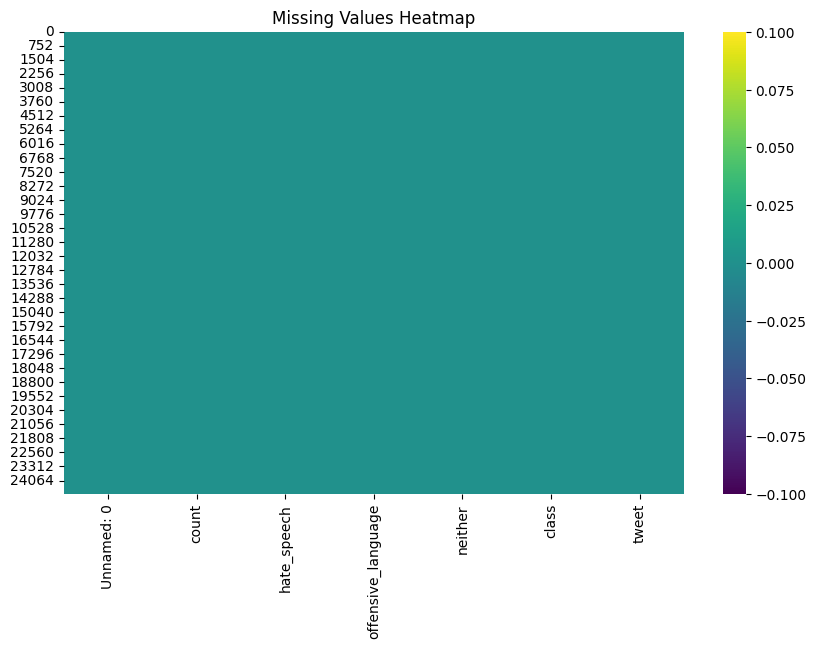

In [ ]:
#missing values in the dataset
missing_values = tweet_data.isnull().sum()

print("Missing values per column:")
print(missing_values)

missing_percentage = (missing_values / len(tweet_data)) * 100
print("\nPercentage of missing values per column:")
print(missing_percentage)

#visualizing using heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(tweet_data.isnull(), cbar=True, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()


# Class Distribution Analysis

In [ ]:
#class mapping
print("Class value counts:")
class_counts = tweet_data['class'].value_counts()

#percentage
class_percentages = (class_counts / len(tweet_data)) * 100

class_distribution = pd.DataFrame({
    'Count': class_counts,
    'Percentage': class_percentages
})

#mapping class numbers to labels
class_distribution.index = class_distribution.index.map({
    0: 'Hate Speech',
    1: 'Offensive Language',
    2: 'Neither'
})

print("Class Distribution:")
print(class_distribution)

Class value counts:
Class Distribution:
                    Count  Percentage
class                                
Offensive Language  19190   77.432111
Neither              4163   16.797805
Hate Speech          1430    5.770084


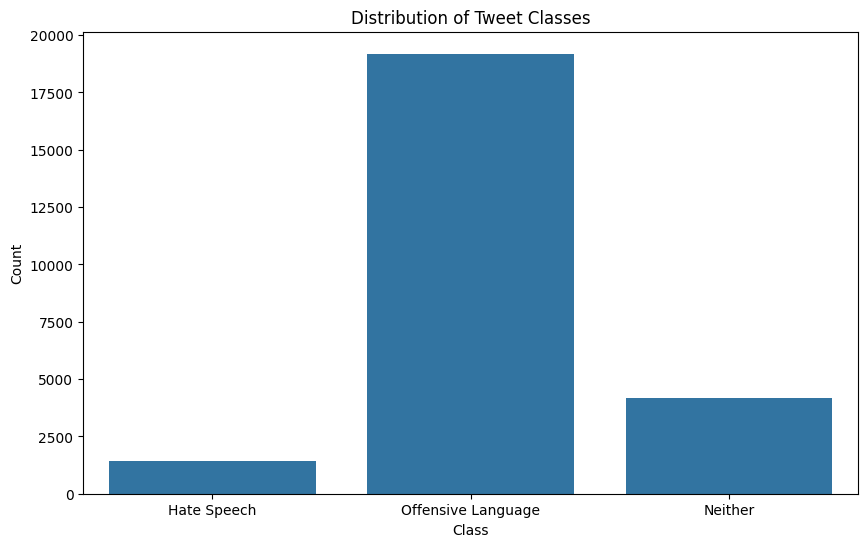

In [ ]:
#countplot for class distribution
plt.figure(figsize=(10, 6))
sns.countplot(x='class', data=tweet_data)
plt.title('Distribution of Tweet Classes')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1, 2], labels=['Hate Speech', 'Offensive Language', 'Neither'])
plt.show()

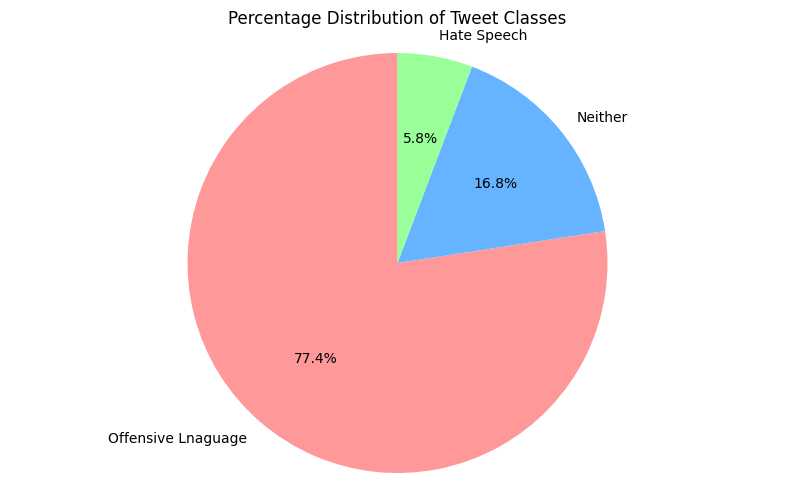

In [ ]:
#piechart for class distribution
plt.figure(figsize=(10, 6))
plt.pie(class_percentages,
        labels=['Offensive Lnaguage', 'Neither', 'Hate Speech'],
        autopct='%1.1f%%',
        startangle=90,
        colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('Percentage Distribution of Tweet Classes')
plt.axis('equal')
plt.show()

# Label Distribution Analysis

In [ ]:
#sum of each label column
label_sums = tweet_data[['hate_speech', 'offensive_language', 'neither']].sum()

#percentages
label_percentages = (label_sums / len(tweet_data)) * 100

label_distribution = pd.DataFrame({
    'Count': label_sums,
    'Percentage': label_percentages
})

print("\nIndividual Label Distribution:")
print(label_distribution)


Individual Label Distribution:
                    Count  Percentage
hate_speech          6952   28.051487
offensive_language  59819  241.371101
neither             13612   54.924747


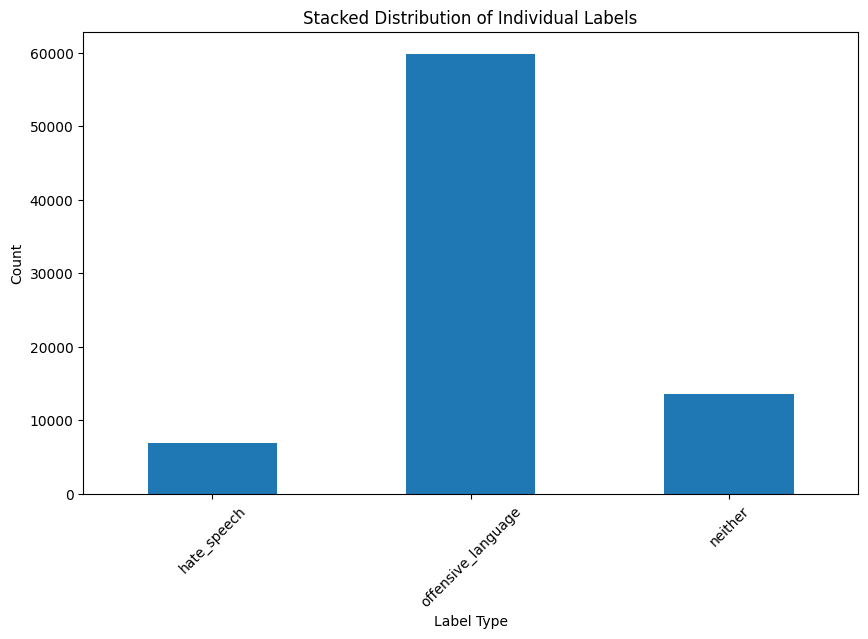

In [ ]:
label_cols = ['hate_speech', 'offensive_language', 'neither']
label_counts = tweet_data[label_cols].sum()

plt.figure(figsize=(10, 6))
label_counts.plot(kind='bar')
plt.title('Stacked Distribution of Individual Labels')
plt.xlabel('Label Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

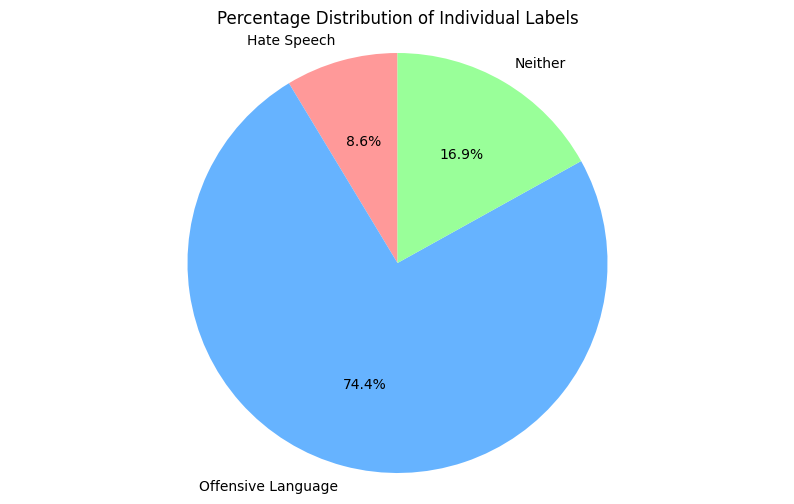

In [ ]:
#piechart for labels
plt.figure(figsize=(10, 6))
plt.pie(label_percentages,
        labels=['Hate Speech', 'Offensive Language', 'Neither'],
        autopct='%1.1f%%',
        startangle=90,
        colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('Percentage Distribution of Individual Labels')
plt.axis('equal')
plt.show()

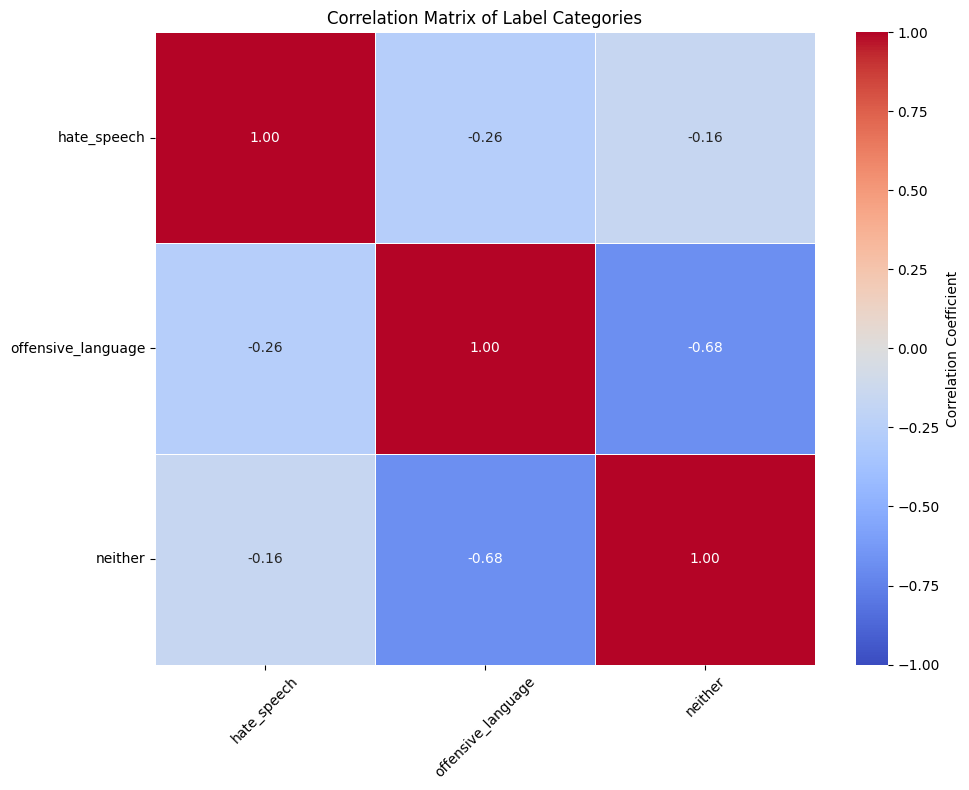

In [ ]:
#correlation matrix for label correlations
label_corr = tweet_data[['hate_speech', 'offensive_language', 'neither']].corr()

#heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(label_corr,
            annot=True,
            cmap='coolwarm',
            vmin=-1,
            vmax=1,
            center=0,
            fmt='.2f',
            linewidths=.5,
            cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Matrix of Label Categories')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Univariate Analysis: Tweet Length Distribution by Class

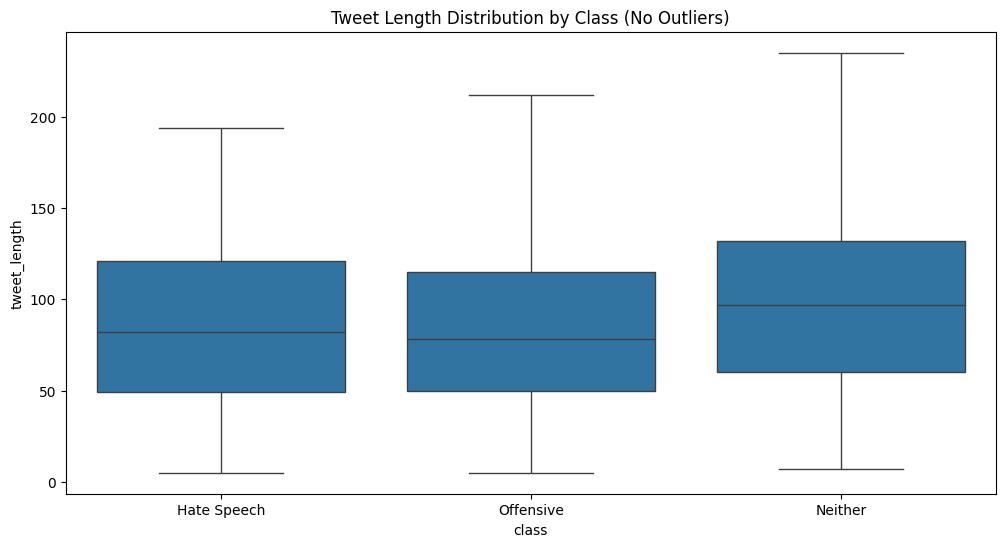

In [ ]:
#raw tweet length (character count)
tweet_data['tweet_length'] = tweet_data['tweet'].str.len()

# Plot length distribution per class
plt.figure(figsize=(12, 6))
sns.boxplot(data=tweet_data, x='class', y='tweet_length', showfliers=False)
plt.title("Tweet Length Distribution by Class (No Outliers)")
plt.xticks([0, 1, 2], ['Hate Speech', 'Offensive', 'Neither'])
plt.show()

# Bivariate Analysis: Hashtag/Mention Counts vs Class

In [ ]:
class_mapping = {
    0: 'Hate Speech',
    1: 'Offensive Language',
    2: 'Neither'
}

#column with class names
tweet_data['class_name'] = tweet_data['class'].map(class_mapping)

#hashtags /mentions counts
tweet_data['hashtag_count'] = tweet_data['tweet'].str.count('#')
tweet_data['mention_count'] = tweet_data['tweet'].str.count('@')

#hashtag/mention means
print("\nAverage Hashtags per Class:")
print(tweet_data.groupby('class_name')['hashtag_count'].mean().sort_values(ascending=False))

print("\nAverage Mentions per Class:")
print(tweet_data.groupby('class_name')['mention_count'].mean().sort_values(ascending=False))

#flags for hashtags/mentions
tweet_data['has_hashtag'] = tweet_data['hashtag_count'] > 0
tweet_data['has_mention'] = tweet_data['mention_count'] > 0

#class distribution for these flags
print("\nTweets with Hashtags by Class:")
print(pd.crosstab(tweet_data['class_name'], tweet_data['has_hashtag']))

print("\nTweets with Mentions by Class:")
print(pd.crosstab(tweet_data['class_name'], tweet_data['has_mention']))

print("\nPercentage of Tweets with Hashtags by Class:")
print(pd.crosstab(tweet_data['class_name'], tweet_data['has_hashtag'], normalize='index').round(2))


Average Hashtags per Class:
class_name
Neither               0.819361
Offensive Language    0.793695
Hate Speech           0.483217
Name: hashtag_count, dtype: float64

Average Mentions per Class:
class_name
Hate Speech           0.946853
Neither               0.864761
Offensive Language    0.755446
Name: mention_count, dtype: float64

Tweets with Hashtags by Class:
has_hashtag         False  True 
class_name                      
Hate Speech          1101    329
Neither              2609   1554
Offensive Language  13428   5762

Tweets with Mentions by Class:
has_mention         False  True 
class_name                      
Hate Speech           513    917
Neither              1621   2542
Offensive Language   8423  10767

Percentage of Tweets with Hashtags by Class:
has_hashtag         False  True 
class_name                      
Hate Speech          0.77   0.23
Neither              0.63   0.37
Offensive Language   0.70   0.30


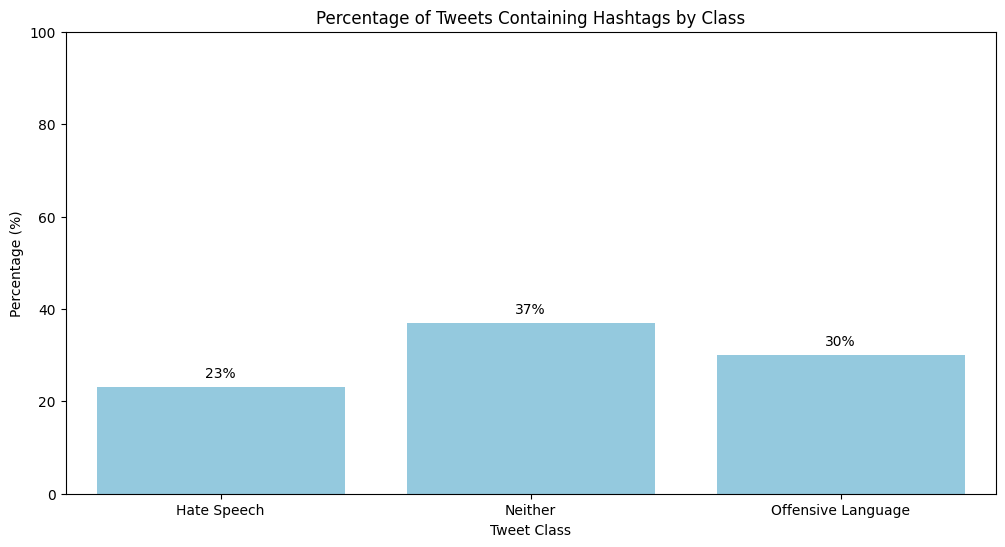

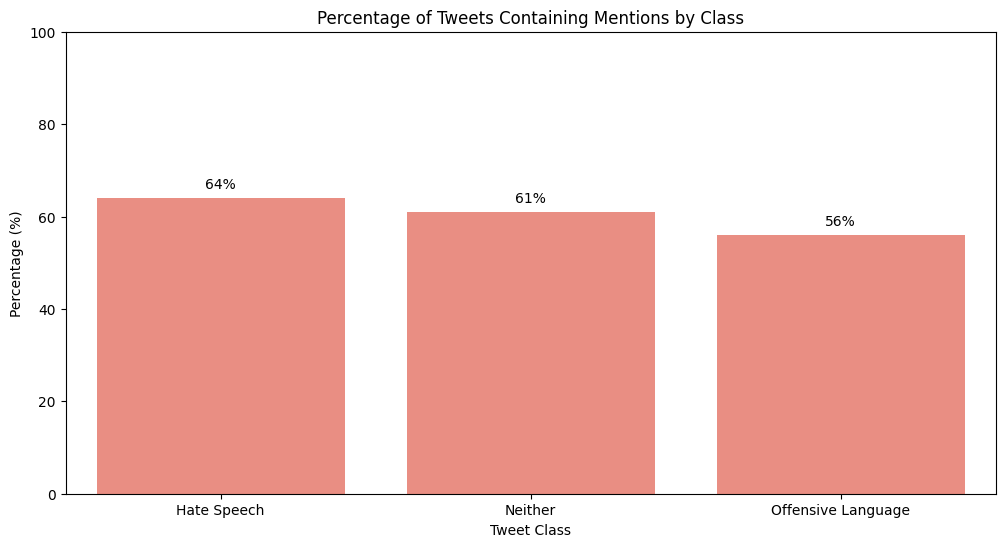

In [ ]:
hashtag_percent = pd.crosstab(tweet_data['class_name'], tweet_data['has_hashtag'], normalize='index').round(2) * 100
mention_percent = pd.crosstab(tweet_data['class_name'], tweet_data['has_mention'], normalize='index').round(2) * 100

#hashtags
plt.figure(figsize=(12, 6))
sns.barplot(data=hashtag_percent.reset_index(), x='class_name', y=True, color='skyblue')
plt.title('Percentage of Tweets Containing Hashtags by Class')
plt.xlabel('Tweet Class')
plt.ylabel('Percentage (%)')
plt.ylim(0, 100)
for i, p in enumerate(plt.gca().patches):
    plt.gca().annotate(f'{p.get_height():.0f}%',
                      (p.get_x() + p.get_width() / 2., p.get_height()),
                      ha='center', va='center',
                      xytext=(0, 10),
                      textcoords='offset points')
plt.show()

#mentions
plt.figure(figsize=(12, 6))
sns.barplot(data=mention_percent.reset_index(), x='class_name', y=True, color='salmon')
plt.title('Percentage of Tweets Containing Mentions by Class')
plt.xlabel('Tweet Class')
plt.ylabel('Percentage (%)')
plt.ylim(0, 100)
for i, p in enumerate(plt.gca().patches):
    plt.gca().annotate(f'{p.get_height():.0f}%',
                      (p.get_x() + p.get_width() / 2., p.get_height()),
                      ha='center', va='center',
                      xytext=(0, 10),
                      textcoords='offset points')
plt.show()

# Outlier Analysis: Tweet Length

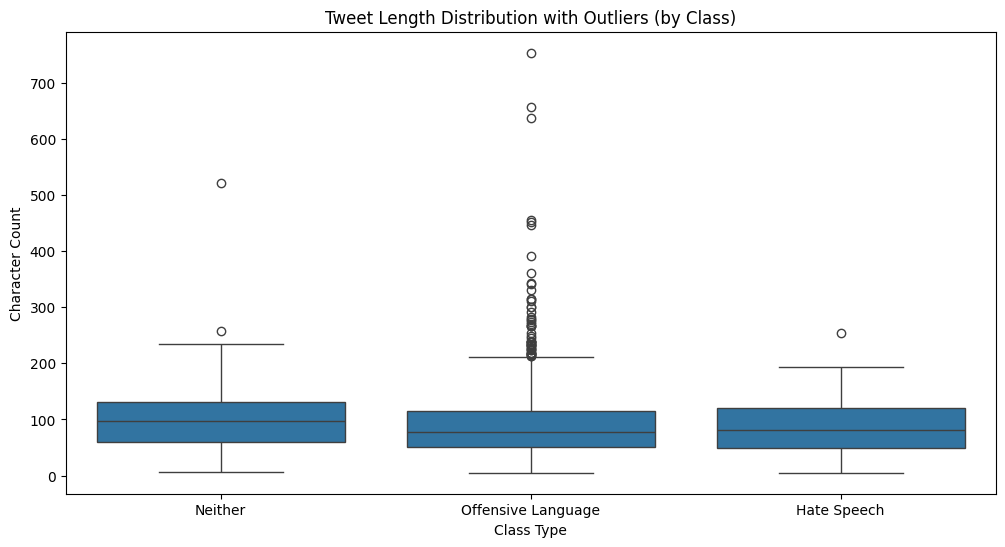

In [ ]:
tweet_data['tweet_length'] = tweet_data['tweet'].str.len()


#boxploat: tweet length by class
plt.figure(figsize=(12, 6))
sns.boxplot(x='class_name', y='tweet_length', data=tweet_data, showfliers=True)
plt.title('Tweet Length Distribution with Outliers (by Class)')
plt.ylabel('Character Count')
plt.xlabel('Class Type')
plt.show()

Found 59 length outliers (0.24% of data)

Tweet length outlier count per class:
class_name
Offensive Language    52
Neither                6
Hate Speech            1
Name: count, dtype: int64


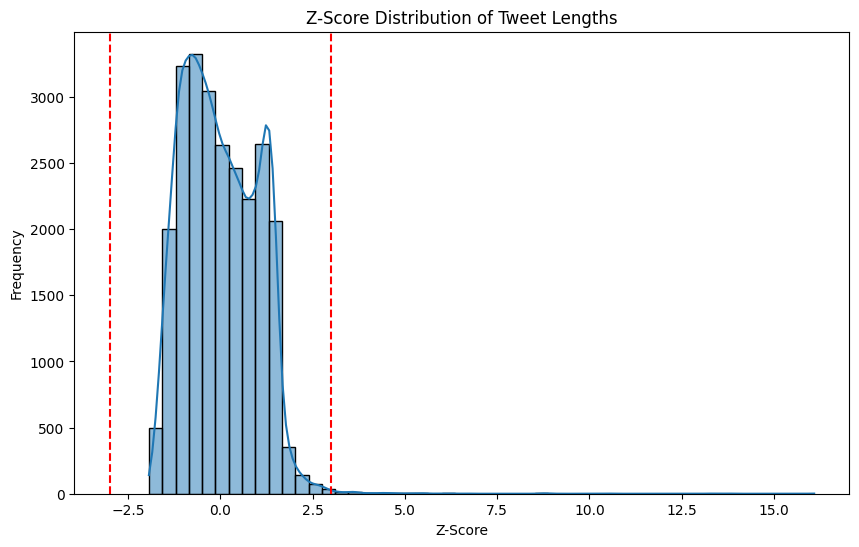

In [ ]:
#z-scores for tweet length
tweet_data['length_zscore'] = stats.zscore(tweet_data['tweet_length'])

#outliers (absolute z-score > 3)
outliers = tweet_data[np.abs(tweet_data['length_zscore']) > 3]
print(f"Found {len(outliers)} length outliers ({len(outliers)/len(tweet_data):.2%} of data)")

# Print outlier count per class
print("\nTweet length outlier count per class:")
print(outliers['class_name'].value_counts())

#z-score distribution
plt.figure(figsize=(10, 6))
sns.histplot(tweet_data['length_zscore'], bins=50, kde=True)
plt.axvline(x=3, color='r', linestyle='--')
plt.axvline(x=-3, color='r', linestyle='--')
plt.title('Z-Score Distribution of Tweet Lengths')
plt.xlabel('Z-Score')
plt.ylabel('Frequency')
plt.show()

# Pre-Processing

clean text

In [ ]:
import re

def clean_text(tweet):
    # Remove mentions (@...)
    tweet = re.sub(r'@\w+', '', tweet)
    # Remove hashtags (#...)
    tweet = re.sub(r'#\w+', '', tweet)
    # Remove URLs
    tweet = re.sub(r'http\S+|www\S+|https\S+', '', tweet, flags=re.MULTILINE)
    # Remove special characters and punctuation
    tweet = re.sub(r'[^A-Za-z0-9 ]', '', tweet)
    # Remove extra whitespace
    tweet = re.sub(r'\s+', ' ', tweet).strip()
    return tweet

tweet_data['cleaned_tweet'] = tweet_data['tweet'].apply(clean_text)

print("Original tweet examples:")
print(tweet_data['tweet'].head())
print("\nCleaned tweet examples:")
print(tweet_data['cleaned_tweet'].head())

Original tweet examples:
0    !!! RT @mayasolovely: As a woman you shouldn't...
1    !!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2    !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3    !!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4    !!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...
Name: tweet, dtype: object

Cleaned tweet examples:
0    RT As a woman you shouldnt complain about clea...
1    RT boy dats coldtyga dwn bad for cuffin dat ho...
2    RT Dawg RT You ever fuck a bitch and she start...
3                            RT she look like a tranny
4    RT The shit you hear about me might be true or...
Name: cleaned_tweet, dtype: object


Tweet length outlier correction

In [ ]:
# Deal with outliers (tweet length outliers)
# We identified tweet length outliers in the previous step using Z-scores.
# Since the number of outliers is relatively small (0.24%), we will remove them.

print(f"Original dataset size: {len(tweet_data)}")
# Remove rows where the absolute z-score of 'tweet_length' is greater than 3.5
tweet_data = tweet_data[np.abs(tweet_data['length_zscore']) <= 3.5].copy()

print(f"Dataset size after removing tweet length outliers: {len(tweet_data)}")

Original dataset size: 24783
Dataset size after removing tweet length outliers: 24740


In [ ]:
tweet_data.shape

(24740, 15)

Dealing with class imbalance - undersampling and upsampling

In [ ]:
from sklearn.utils import resample

# Separate classes
offensive = tweet_data[tweet_data['class'] == 1]
hate_speech = tweet_data[tweet_data['class'] == 0]
neither = tweet_data[tweet_data['class'] == 2]

# Undersample Offensive Language to match Neither (or a target size, e.g., 5,000)
offensive_downsampled = resample(offensive, n_samples= 9000, random_state=42)

#oversample hateful language
hate_speech_upsampled = resample(hate_speech, replace=True, n_samples=len(hate_speech)*2, random_state=42)

# Combine back into a balanced dataset
balanced_data = pd.concat([offensive_downsampled, hate_speech_upsampled, neither])

print(f"Dataset size after undersampling: {len(balanced_data)}")
print("Class distribution after undersampling:")
print(balanced_data['class'].value_counts())

Dataset size after undersampling: 16017
Class distribution after undersampling:
class
1    9000
2    4159
0    2858
Name: count, dtype: int64


In [ ]:
balanced_data.shape

(16017, 15)

# Feature Extraction

Tweet length, Hashtag counts, Mention Counts

In [ ]:
#Calculate cleaned tweet length
balanced_data['cleaned_tweet_length'] = balanced_data['cleaned_tweet'].str.len()

#Count hashtags (already done in previous cell, keeping for completeness)
#Count mentions (already done in previous cell, keeping for completeness)

print(balanced_data['cleaned_tweet_length'].head())
print(balanced_data['hashtag_count'].head())
print(balanced_data['mention_count'].head())

20563     37
1121      26
7297      44
15634     80
14777    119
Name: cleaned_tweet_length, dtype: int64
20563    2
1121     2
7297     0
15634    0
14777    1
Name: hashtag_count, dtype: int64
20563    0
1121     1
7297     2
15634    1
14777    1
Name: mention_count, dtype: int64


Average Length Per Tweet

In [ ]:
def calculate_average_word_length(tweet):
    # Ensure tweet is a string and handle empty cases
    if not isinstance(tweet, str) or not tweet.strip():
        return 0.0
    # Split into words (using space as delimiter, consistent with cleaned text)
    words = tweet.split()
    if not words:
        return 0.0
    # Total characters excluding spaces
    total_chars = sum(len(word) for word in words)
    # Number of words
    num_words = len(words)
    return total_chars / num_words

# Calculate average word length for cleaned tweets
balanced_data['avg_word_length'] = balanced_data['cleaned_tweet'].apply(calculate_average_word_length)

# Verify
print("Cleaned tweet examples:")
print(balanced_data['cleaned_tweet'].head())
print("\nAverage word length examples:")
print(balanced_data['avg_word_length'].head())

Cleaned tweet examples:
20563                Run it up first these hoes come later
1121                            My momma aint raise no hoe
7297          yu betta watch cho mouf bout dat one dea hoe
15634    RT How to deal with cyber bulling1log out2go o...
14777    RT i love girls who arent afraid to encourage ...
Name: cleaned_tweet, dtype: object

Average word length examples:
20563    3.750000
1121     3.500000
7297     3.500000
15634    4.785714
14777    4.454545
Name: avg_word_length, dtype: float64


In [ ]:
# Uninstall existing versions
#!pip uninstall -y transformers torch

# Install compatible versions
#!pip install transformers==4.35.2 torch==2.5.1+cu121 --extra-index-url https://download.pytorch.org/whl/cu121

# Verify installation
#import transformers
#import torch
#print(f"Transformers version: {transformers.__version__}")
#print(f"Torch version: {torch.__version__}")
#print(f"CUDA available: {torch.cuda.is_available()}")

BERT Embeddings

In [ ]:
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm
import pandas as pd

# Check if GPU is available and set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Initialize BERTweet tokenizer and model with error handling and retry
max_retries = 2
for attempt in range(max_retries):
    try:
        tokenizer = AutoTokenizer.from_pretrained("vinai/bertweet-base")
        model = AutoModel.from_pretrained("vinai/bertweet-base").to(device)
        print(f"Successfully loaded BERTweet on attempt {attempt + 1}")
        break
    except Exception as e:
        print(f"Attempt {attempt + 1} failed: {e}")
        if attempt == max_retries - 1:
            raise
        print("Retrying after a short delay...")
        import time; time.sleep(5)  # Wait 5 seconds before retrying

# Function to get BERT embeddings with error handling and dynamic batching
def get_bert_embeddings(tweets, batch_size=32, max_length=128):
    if not isinstance(tweets, (pd.Series, list, np.ndarray)):
        raise ValueError("Input 'tweets' must be a pandas Series, list, or numpy array")

    # Ensure tweets are strings and handle empty or invalid entries
    tweets = [str(tweet) if pd.notna(tweet) and tweet != "" else "" for tweet in tweets]

    embeddings = []
    for i in tqdm(range(0, len(tweets), batch_size), desc="Generating BERT embeddings"):
        batch_tweets = tweets[i:i + batch_size]
        try:
            # Tokenize batch
            inputs = tokenizer(
                batch_tweets,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=max_length
            ).to(device)

            # Get embeddings
            with torch.no_grad():
                outputs = model(**inputs)
                # Mean-pool the last hidden state to get tweet-level embeddings (768D)
                batch_embeddings = outputs.last_hidden_state.mean(dim=1).cpu().numpy()
            embeddings.append(batch_embeddings)
        except RuntimeError as e:
            print(f"Memory error or CUDA out of memory at batch {i}. Reducing batch size to {max(batch_size // 2, 8)}")
            batch_size = max(batch_size // 2, 8)  # Halve batch size, minimum 8 for GPU efficiency
            continue  # Skip this batch and proceed with reduced size

    if not embeddings:
        raise RuntimeError("No embeddings generated. Check input data or device.")

    return np.vstack(embeddings)

# Apply to cleaned tweet text (before lemmatization, stop-word removal, TF-IDF)
try:
    if 'cleaned_tweet' not in balanced_data.columns:
        raise KeyError("Column 'cleaned_tweet' not found in balanced_data. Ensure clean_text was applied.")

    bert_embeddings = get_bert_embeddings(balanced_data['cleaned_tweet'], batch_size=64)  # Optimized for GPU

    print("BERT embeddings shape:", bert_embeddings.shape)
    # Note: Combine with TF-IDF later after computing tfidf_matrix (e.g., combined_features = hstack([tfidf_matrix, bert_embeddings]))
except Exception as e:
    print(f"Error during embedding generation: {e}")
    raise

Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/558 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Successfully loaded BERTweet on attempt 1



Generating BERT embeddings: 100%|██████████| 251/251 [00:10<00:00, 23.05it/s]


BERT embeddings shape: (16017, 768)


In [ ]:
balanced_data['bert_embeddings'] = list(bert_embeddings)
print(bert_embeddings)

[[-0.03626326  0.1640982   0.11044491 ... -0.03782374 -0.00831516
  -0.18535565]
 [-0.00904193  0.24902001  0.27470255 ...  0.06416557  0.06377639
  -0.10554613]
 [ 0.08636285  0.16022497  0.21715099 ...  0.01323874  0.14467247
  -0.06544578]
 ...
 [ 0.13066307  0.08806948 -0.01381801 ...  0.08020829  0.24704579
  -0.01393022]
 [-0.05433369  0.10401636  0.01284003 ... -0.06781442  0.16272585
  -0.05182486]
 [-0.16910112  0.05138674  0.16990575 ...  0.04026426  0.15787579
  -0.09006708]]


In [ ]:
import nltk
from nltk.tokenize import word_tokenize

#punkt tokenizer
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

Preprocessing for other features: Tokenization

In [ ]:
# Handle potential encoding issues before tokenization
balanced_data['cleaned_tweet'] = balanced_data['cleaned_tweet'].str.encode('ascii', 'ignore').str.decode('ascii')

balanced_data['tokens'] = balanced_data['cleaned_tweet'].apply(word_tokenize)

In [ ]:
print("Original tweet examples:")
print(balanced_data['tweet'].head())
print("\nCleaned tweet examples:")
print(balanced_data['cleaned_tweet'].head())
print("\nTokenized tweet examples:")
print(balanced_data['tokens'].head())

Original tweet examples:
20563    Run it up first , these hoes come later&#9996;...
1121     &#8220;@BINDLE13: My momma aint raise no hoe&#...
7297     @wodaeeex3 @aaliyahh_lovee yu betta watch cho ...
15634    RT @ImNotTwitFamous: How to deal with cyber bu...
14777    RT @CorySayFukEm: i love girls who aren't afra...
Name: tweet, dtype: object

Cleaned tweet examples:
20563                Run it up first these hoes come later
1121                            My momma aint raise no hoe
7297          yu betta watch cho mouf bout dat one dea hoe
15634    RT How to deal with cyber bulling1log out2go o...
14777    RT i love girls who arent afraid to encourage ...
Name: cleaned_tweet, dtype: object

Tokenized tweet examples:
20563       [Run, it, up, first, these, hoes, come, later]
1121                     [My, momma, aint, raise, no, hoe]
7297     [yu, betta, watch, cho, mouf, bout, dat, one, ...
15634    [RT, How, to, deal, with, cyber, bulling1log, ...
14777    [RT, i, love, girls, who, 

Feature: Lemmatization

In [ ]:
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

# Download WordNet and the POS tagger
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [ ]:
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(word):
    """Map POS tags to first letter used by WordNetLemmatizer"""
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_dict = {"N": wordnet.NOUN,
                "V": wordnet.VERB,
                "A": wordnet.ADJ,
                "R": wordnet.ADV}
    return tag_dict.get(tag, wordnet.NOUN)

balanced_data['tokens_lemmatized'] = balanced_data['tokens'].apply(lambda tokens: [lemmatizer.lemmatize(word, get_wordnet_pos(word)) for word in tokens])

In [ ]:
print("\nTokens before lemmatization:")
print(balanced_data['tokens'].head(15))
print("\nTokens after lemmatization:")
print(balanced_data['tokens_lemmatized'].head(15))


Tokens before lemmatization:
20563       [Run, it, up, first, these, hoes, come, later]
1121                     [My, momma, aint, raise, no, hoe]
7297     [yu, betta, watch, cho, mouf, bout, dat, one, ...
15634    [RT, How, to, deal, with, cyber, bulling1log, ...
14777    [RT, i, love, girls, who, arent, afraid, to, e...
8382     [Carl, try, eat, the, pussy, but, that, big, a...
21909          [Thirsty, bitchesltltltlt, Not, attractive]
5944     [bitch, please, are, you, trying, to, say, I, ...
18772    [RT, Im, a, knock, the, pussy, out, like, figh...
14869    [RT, Marriage, not, for, everyone, Some, bitch...
20843    [Side, bitches, are, basically, new, relations...
11039    [I, was, a, huge, tomboy, Like, I, had, barbie...
2096     [See, I, got, ta, get, this, money, ma, palms,...
1010       [RT, Hood, hoes, love, Harrell, football, team]
3137               [they, can, see, this, dumbass, nigger]
Name: tokens, dtype: object

Tokens after lemmatization:
20563        [Run, it, up, f

Preprocessing for other features: Stopword removal

In [ ]:
from nltk.corpus import stopwords

# Download stop words
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
stop_words = set(stopwords.words('english'))

balanced_data['tokens_no_stopwords'] = balanced_data['tokens'].apply(lambda tokens: [word for word in tokens if word.lower() not in stop_words])

In [ ]:
print("\nTokens before stop word removal:")
print(balanced_data['tokens'].head(15))
print("\nTokens after stop word removal:")
print(balanced_data['tokens_no_stopwords'].head(15))


Tokens before stop word removal:
20563       [Run, it, up, first, these, hoes, come, later]
1121                     [My, momma, aint, raise, no, hoe]
7297     [yu, betta, watch, cho, mouf, bout, dat, one, ...
15634    [RT, How, to, deal, with, cyber, bulling1log, ...
14777    [RT, i, love, girls, who, arent, afraid, to, e...
8382     [Carl, try, eat, the, pussy, but, that, big, a...
21909          [Thirsty, bitchesltltltlt, Not, attractive]
5944     [bitch, please, are, you, trying, to, say, I, ...
18772    [RT, Im, a, knock, the, pussy, out, like, figh...
14869    [RT, Marriage, not, for, everyone, Some, bitch...
20843    [Side, bitches, are, basically, new, relations...
11039    [I, was, a, huge, tomboy, Like, I, had, barbie...
2096     [See, I, got, ta, get, this, money, ma, palms,...
1010       [RT, Hood, hoes, love, Harrell, football, team]
3137               [they, can, see, this, dumbass, nigger]
Name: tokens, dtype: object

Tokens after stop word removal:
20563               

Feature: TF-IDF Matrix

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Convert the list of tokens back to strings for vectorization
balanced_data['text_for_vectorization'] = balanced_data['tokens_no_stopwords'].apply(lambda tokens: ' '.join(tokens))

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # You can adjust max_features

# Fit and transform the text data
tfidf_matrix = tfidf_vectorizer.fit_transform(balanced_data['text_for_vectorization'])

print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (16017, 5000)


In [ ]:
#Summarized TF-IDF matrix
print("\nTF-IDF Matrix Summary:")
print(f"Shape: {tfidf_matrix.shape}")
print("Sample values (first 5 rows, first 5 columns):")
print(tfidf_matrix[:5, :5].toarray())  # Convert sparse slice to dense for display


TF-IDF Matrix Summary:
Shape: (16017, 5000)
Sample values (first 5 rows, first 5 columns):
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


Representation for the most common words after preprocessing

Most Common Words:
[('RT', 4796), ('bitch', 4133), ('like', 1585), ('bitches', 1458), ('hoes', 1167), ('pussy', 1062), ('trash', 1041), ('Im', 976), ('hoe', 968), ('dont', 967), ('ass', 897), ('got', 854), ('get', 834), ('u', 731), ('nigga', 668), ('fuck', 658), ('shit', 619), ('amp', 605), ('aint', 603), ('know', 504)]


/tmp/ipython-input-2703281051.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='word', data=most_common_df, palette='viridis')


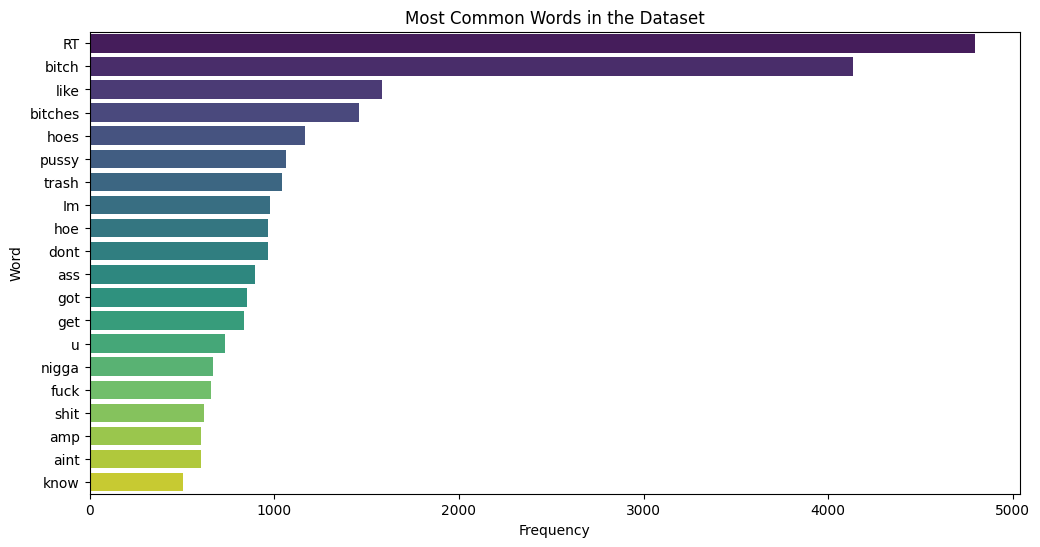

In [ ]:
from collections import Counter

# Join all lemmatized tokens into a single string
all_words = ' '.join(balanced_data['text_for_vectorization'])

# Get the most common words
most_common_words = Counter(all_words.split()).most_common(20) # Adjust the number as needed

# Print the most common words
print("Most Common Words:")
print(most_common_words)

# Create a DataFrame for plotting
most_common_df = pd.DataFrame(most_common_words, columns=['word', 'count'])

# Plot a bar chart of the most common words
plt.figure(figsize=(12, 6))
sns.barplot(x='count', y='word', data=most_common_df, palette='viridis')
plt.title('Most Common Words in the Dataset')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.show()

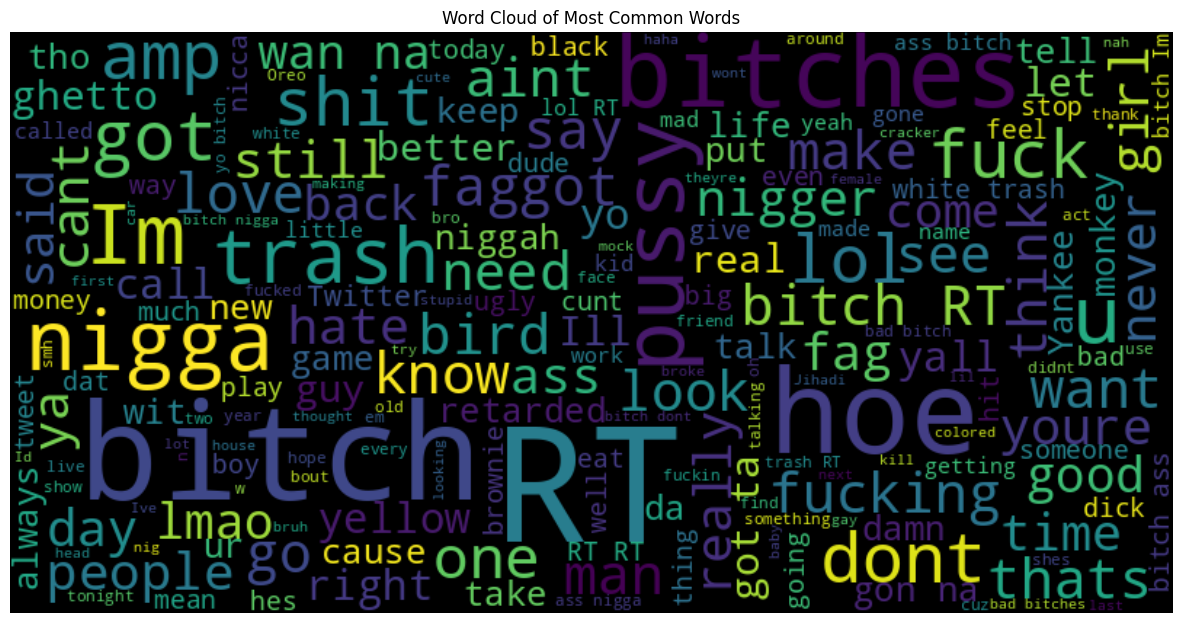

In [ ]:
from wordcloud import WordCloud

# Generate a word cloud
wordcloud = WordCloud(width=800, height=400, random_state=21, max_font_size=110).generate(all_words)

plt.figure(figsize=(15, 10))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis('off')
plt.title('Word Cloud of Most Common Words')
plt.show()

Feature: Sentiment Score

In [ ]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import pandas as pd
import numpy as np
from tqdm import tqdm  # For progress bar

# Download VADER lexicon if not already downloaded
try:
    analyzer = SentimentIntensityAnalyzer()
except LookupError:
    nltk.download('vader_lexicon')
    analyzer = SentimentIntensityAnalyzer()

# Function to calculate sentiment scores with error handling
def get_sentiment_score(tweet):
    if not isinstance(tweet, str) or pd.isna(tweet):
        return 0.0  # Default for NaN or non-string
    scores = analyzer.polarity_scores(tweet)
    return scores['compound']  # Can extend to 'neg', 'neu', 'pos' if needed

# Calculate sentiment scores in batches for efficiency
batch_size = 1000
sentiment_scores = []
for i in tqdm(range(0, len(balanced_data), batch_size), desc="Calculating sentiment scores"):
    batch = balanced_data['cleaned_tweet'].iloc[i:i + batch_size]
    batch_scores = [get_sentiment_score(tweet) for tweet in batch]
    sentiment_scores.extend(batch_scores)

# Add to DataFrame
balanced_data['sentiment_score'] = sentiment_scores

# Verify
print("Sentiment score examples:")
print(balanced_data['sentiment_score'].head())

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
Calculating sentiment scores: 100%|██████████| 17/17 [00:02<00:00,  7.78it/s]

Sentiment score examples:
20563    0.0000
1121     0.2235
7297     0.0000
15634    0.0000
14777   -0.4592
Name: sentiment_score, dtype: float64


Feature: Lexical Density

In [ ]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.tag import pos_tag
import pandas as pd
from tqdm import tqdm  # For progress bar

# Download required NLTK data if not already downloaded
try:
    nltk.data.find('averaged_perceptron_tagger')
except LookupError:
    nltk.download('averaged_perceptron_tagger')
try:
    nltk.data.find('punkt')
except LookupError:
    nltk.download('punkt')

# Function to calculate lexical density
def calculate_lexical_density(tweet):
    if not isinstance(tweet, str) or not tweet.strip():
        return 0.0  # Default for NaN or empty tweets
    # Tokenize the tweet
    tokens = word_tokenize(tweet.lower())  # Convert to lowercase for consistency
    if not tokens:
        return 0.0
    # POS tag the tokens
    pos_tags = pos_tag(tokens)
    # Count lexical words (nouns, verbs, adjectives, adverbs)
    lexical_count = sum(1 for _, tag in pos_tags if tag.startswith(('NN', 'VB', 'JJ', 'RB')))
    total_words = len(tokens)
    return lexical_count / total_words if total_words > 0 else 0.0

# Calculate lexical density in batches for efficiency
batch_size = 1000
lexical_densities = []
for i in tqdm(range(0, len(balanced_data), batch_size), desc="Calculating lexical densities"):
    batch = balanced_data['cleaned_tweet'].iloc[i:i + batch_size]
    batch_densities = [calculate_lexical_density(tweet) for tweet in batch]
    lexical_densities.extend(batch_densities)

# Add to DataFrame
balanced_data['lexical_density'] = lexical_densities

# Verify
print("Cleaned tweet examples:")
print(balanced_data['cleaned_tweet'].head())
print("\nLexical density examples:")
print(balanced_data['lexical_density'].head())

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
Calculating lexical densities: 100%|██████████| 17/17 [00:08<00:00,  1.99it/s]

Cleaned tweet examples:
20563                Run it up first these hoes come later
1121                            My momma aint raise no hoe
7297          yu betta watch cho mouf bout dat one dea hoe
15634    RT How to deal with cyber bulling1log out2go o...
14777    RT i love girls who arent afraid to encourage ...
Name: cleaned_tweet, dtype: object

Lexical density examples:
20563    0.625000
1121     0.666667
7297     0.800000
15634    0.642857
14777    0.772727
Name: lexical_density, dtype: float64


Feature: Readability Score

In [ ]:
# Install textstat library
!pip install textstat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 239.1/239.1 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 939.7/939.7 kB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 74.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from textstat import textstat
from tqdm import tqdm  # For progress bar

# Install textstat if not already installed
try:
    import textstat
except ImportError:
    !pip install textstat
    import textstat


# Reset index to ensure unique, sequential indices
balanced_data = balanced_data.reset_index(drop=True)

# Function to calculate readability scores
def calculate_readability_scores(tweet):
    if not isinstance(tweet, str) or not tweet.strip():
        return {'flesch_kincaid': 0.0, 'flesch_ease': 0.0, 'gunning_fog': 0.0}  # Default for NaN or empty tweets
    # Calculate readability scores
    flesch_kincaid = textstat.flesch_kincaid_grade(tweet)
    flesch_ease = textstat.flesch_reading_ease(tweet)
    gunning_fog = textstat.gunning_fog(tweet)
    return {'flesch_kincaid': flesch_kincaid, 'flesch_ease': flesch_ease, 'gunning_fog': gunning_fog}

# Calculate readability scores in batches for efficiency
batch_size = 1000
readability_scores = []
for i in tqdm(range(0, len(balanced_data), batch_size), desc="Calculating readability scores"):
    batch = balanced_data['cleaned_tweet'].iloc[i:i + batch_size]
    batch_scores = [calculate_readability_scores(tweet) for tweet in batch]
    readability_scores.extend(batch_scores)

# Convert to DataFrame and add to balanced_data
readability_df = pd.DataFrame(readability_scores)
balanced_data = pd.concat([balanced_data, readability_df], axis=1)

# Verify
print("Cleaned tweet examples:")
print(balanced_data['cleaned_tweet'].head())
print("\nReadability score examples:")
print(balanced_data[['flesch_kincaid', 'flesch_ease', 'gunning_fog']].head())

Calculating readability scores: 100%|██████████| 17/17 [00:02<00:00,  7.25it/s]

Cleaned tweet examples:
0                Run it up first these hoes come later
1                           My momma aint raise no hoe
2         yu betta watch cho mouf bout dat one dea hoe
3    RT How to deal with cyber bulling1log out2go o...
4    RT i love girls who arent afraid to encourage ...
Name: cleaned_tweet, dtype: object

Readability score examples:
   flesch_kincaid  flesch_ease  gunning_fog
0        0.805000   103.540000     3.200000
1        0.516667   102.045000     2.400000
2        1.290000   103.625000     4.000000
3        7.570000    65.725000     8.457143
4        9.080909    69.141364    12.436364


Feature: Sentiment Shifts

In [ ]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Download VADER lexicon
nltk.download('vader_lexicon')


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [ ]:
# Initialize VADER sentiment analyzer
sid = SentimentIntensityAnalyzer()

# Function to compute sentiment shift
def calculate_sentiment_shift(tweet):
    if not isinstance(tweet, str) or not tweet.strip():
        return 0.0

    # Split tweet into words
    words = tweet.split()
    if len(words) < 2:
        return 0.0

    # Split into two halves based on word count
    split_point = len(words) // 2
    seg1 = ' '.join(words[:split_point])
    seg2 = ' '.join(words[split_point:])
    segments = [seg1, seg2]

    # Compute sentiment scores for each segment
    sentiment_scores = [sid.polarity_scores(seg)['compound'] for seg in segments]

    # Calculate absolute difference
    return abs(sentiment_scores[1] - sentiment_scores[0])

balanced_data['sentiment_shift'] = balanced_data['cleaned_tweet'].apply(calculate_sentiment_shift)
print(balanced_data['cleaned_tweet'].head())
print(balanced_data['sentiment_shift'].head())

0                Run it up first these hoes come later
1                           My momma aint raise no hoe
2         yu betta watch cho mouf bout dat one dea hoe
3    RT How to deal with cyber bulling1log out2go o...
4    RT i love girls who arent afraid to encourage ...
Name: cleaned_tweet, dtype: object
0    0.0000
1    0.2960
2    0.0000
3    0.0000
4    1.5031
Name: sentiment_shift, dtype: float64


Feature: N-Gram Pattern Vectors

In [ ]:
# New Feature: N-Gram Patterns (Bigrams/Trigrams) using TfidfVectorizer
# We use TfidfVectorizer with ngram_range=(2, 3) to capture phrases/slurs
# Limit max_features to 2000 to control dimensionality and focus on top n-grams
ngram_vectorizer = TfidfVectorizer(ngram_range=(2, 3), max_features=2000, analyzer='word')
ngram_matrix = ngram_vectorizer.fit_transform(balanced_data['cleaned_tweet'])

# Print some top n-grams for verification
print("Top 10 bigrams/trigrams:")
print(ngram_vectorizer.get_feature_names_out()[:10])
#print(ngram_matrix)

Top 10 bigrams/trigrams:
['7186220221 24' 'about how' 'about it' 'about me' 'about that'
 'about the' 'about their' 'about this' 'about to' 'about what']


Feature: Slang Markers

In [ ]:
#Slang/Dialect Markers
#custom dictionary of regex patterns for phonetic/misspelled slurs and code words
#common patterns: leetspeak (e.g., h8 for hate), symbols (*, @), misspellings
slang_patterns = [
    r'\bh8\b',              # h8 for hate
    r'\bh@te\b',            # h@te for hate
    r'\bn1gger\b',          # n1gger for n-word
    r'\bn\*gger\b',         # n*gger
    r'\bnigg?r\b',          # nigg*r or niggr
    r'\bf@g\b',             # f@g for fag
    r'\bf4g\b',             # f4g
    r'\bk1ke\b',            # k1ke for kike
    r'\bk\*ke\b',           # k*ke
    r'\bj3w\b',             # j3w for jew
    r'\bch1nk\b',           # ch1nk for chink
    r'\bsp1c\b',            # sp1c for spic
    r'\bw3tb4ck\b',         # w3tb4ck for wetback
    r'\bt4rd\b',            # t4rd for retard
    r'\br3t4rd\b',          # r3t4rd
    r'\btr4nny\b',          # tr4nny for tranny
    r'\btr\*nny\b',         # tr*nny
    r'\bwh0re\b',           # wh0re for whore
    r'\bc\*nt\b',           # c*nt for cunt
    r'\bb1tch\b',           # b1tch for bitch
    r'\bsh1t\b',            # sh1t for shit
    r'\bj1hadi\b',          # j1hadi for jihadi
    r'\bjih@di\b',
    r'\bjihad1\b',
    r'\bfck\b',
    r'\bfuk\b',
    r'\bd1ke\b',
    r'\bkys\b',
    r'\bcoon\b',
    r'\bgypo\b',
    r'\bchinks\b',
    r'\bspics\b',
    r'\bretard\b',
    r'\bfaggot\b'
    # General patterns for leetspeak or censored words
    r'\b\w*[\d@*]+\w*\b'    # Words with numbers/symbols (e.g., h8, n*gg*r)
]

# Compile regex patterns
slang_regex = re.compile('|'.join(slang_patterns), re.IGNORECASE)

# Function to count slang markers in a tweet
def count_slang_markers(tweet):
    if not isinstance(tweet, str) or not tweet.strip():
        return 0
    matches = slang_regex.findall(tweet)
    return len(matches)

# Apply to balanced_data (using cleaned_tweet, as it's tokenized and cleaned)
balanced_data['slang_marker_count'] = balanced_data['cleaned_tweet'].apply(count_slang_markers)

# Print some examples for verification
print("Slang marker count distribution:")
print(balanced_data['slang_marker_count'].describe())
print("\nSample tweets with slang markers (>0):")
print(balanced_data[balanced_data['slang_marker_count'] > 0][['cleaned_tweet', 'slang_marker_count']].head(10))

Slang marker count distribution:
count    16017.000000
mean         0.012549
std          0.112438
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          2.000000
Name: slang_marker_count, dtype: float64

Sample tweets with slang markers (>0):
                                         cleaned_tweet  slang_marker_count
133  RT Full retard NAR blaming slow April sales on...                   1
425  If you act like a fucking retard when your hig...                   1
483  Fluffy is a retard homeboy is calling a baby r...                   1
496  when youre stupid you dont know it life is so ...                   1
575           man fck dat tranny Juwanna man ass nigga                   1
643  bitch I aint arguing with you Fuk on You said ...                   1
796                Cant fuck with a coon ass girl bruh                   1
852  Bitch fuk wat a hater gotta say brickk ent ya ...                   1
978  Well now that Im basically gon

Feature: Named Entity Recognition (NER)

In [ ]:
# New Feature: Named Entity Recognition (NER) - Dictionary-based for targeted entities
# Define a custom dictionary of regex patterns for race, religion, and public figures
# Race/Nationality (NORP-like): common terms
# Religion: common terms
# Public figures: a few common examples (expand as needed; hard to cover all)
ner_patterns = {
    'race_nationality': [
        r'\bafrican\b', r'\basian\b', r'\bblack\b', r'\bwhite\b', r'\blatino\b', r'\bhispanic\b',
        r'\bindian\b', r'\barab\b', r'\bjewish\b', r'\bchinese\b', r'\bmexican\b', r'\bafrican american\b',
        r'\bcaucasian\b', r'\bindigenous\b', r'\bnative american\b', r'\bimmigrant\b'
    ],
    'religion': [
        r'\bmuslim\b', r'\bchristian\b', r'\bjew\b', r'\bhindu\b', r'\bbuddhist\b', r'\bsikh\b',
        r'\bathiest\b', r'\bislam\b', r'\bchristianity\b', r'\bjudaism\b', r'\bzionist\b'
    ],
    'public_figures': [  # Limited examples; can expand based on domain knowledge
        r'\bobama\b', r'\btrump\b', r'\bbiden\b', r'\bclinton\b', r'\bputin\b', r'\bkim\b',
        r'\belon musk\b', r'\bmark zuckerberg\b', r'\btaylor swift\b'  # Add more as relevant
    ]
}

# Compile regex for each category
race_regex = re.compile('|'.join(ner_patterns['race_nationality']), re.IGNORECASE)
religion_regex = re.compile('|'.join(ner_patterns['religion']), re.IGNORECASE)
figures_regex = re.compile('|'.join(ner_patterns['public_figures']), re.IGNORECASE)

# Function to count targeted entities in a tweet
def count_targeted_entities(tweet):
    if not isinstance(tweet, str) or not tweet.strip():
        return {'race_count': 0, 'religion_count': 0, 'figures_count': 0}
    race_matches = len(race_regex.findall(tweet))
    religion_matches = len(religion_regex.findall(tweet))
    figures_matches = len(figures_regex.findall(tweet))
    return {'race_count': race_matches, 'religion_count': religion_matches, 'figures_count': figures_matches}

# Apply to balanced_data (using cleaned_tweet for token matching)
ner_results = [count_targeted_entities(tweet) for tweet in tqdm(balanced_data['cleaned_tweet'], desc="Calculating NER counts")]
ner_df = pd.DataFrame(ner_results)
balanced_data = pd.concat([balanced_data, ner_df], axis=1)

# Print distribution for verification
print("NER counts distribution:")
print(balanced_data[['race_count', 'religion_count', 'figures_count']].describe())
print("\nSample tweets with targeted entities (>0 in any category):")
print(balanced_data[(balanced_data['race_count'] > 0) | (balanced_data['religion_count'] > 0) | (balanced_data['figures_count'] > 0)][['cleaned_tweet', 'race_count', 'religion_count', 'figures_count']].head(10))

Calculating NER counts: 100%|██████████| 16017/16017 [00:00<00:00, 55405.91it/s]


NER counts distribution:
         race_count  religion_count  figures_count
count  16017.000000    16017.000000   16017.000000
mean       0.042268        0.002560       0.003808
std        0.226600        0.054111       0.063592
min        0.000000        0.000000       0.000000
25%        0.000000        0.000000       0.000000
50%        0.000000        0.000000       0.000000
75%        0.000000        0.000000       0.000000
max        3.000000        2.000000       2.000000

Sample tweets with targeted entities (>0 in any category):
                                         cleaned_tweet  race_count  \
205  RT The nae nae got to the white ppl its too la...           1   
312   Putin making look like a bitch on foreign policy           0   
361  RT Twerking is ghetto until White people do it...           1   
386  nigga I talk shit period this aint nun new whi...           1   
407                                  fugly white bitch           1   
467  you out yo mind Rose colder tha

Feature: POS Tags

In [ ]:
from nltk import pos_tag, word_tokenize


#Part-of-Speech (POS) Tags
#NLTK to extract POS tag frequencies and count aggressive verb-noun combos
#define aggressive verbs (expand as needed)
aggressive_verbs = [
    'destroy', 'kill', 'hate', 'attack', 'hurt', 'beat', 'fight', 'ruin', 'trash', 'bash',
    'slam', 'crush', 'rape', 'smother', 'smash', 'bomb', 'burn', 'erase', 'wipe', 'eliminate', 'annihilate'
]

# Function to compute POS features
def calculate_pos_features(tweet):
    if not isinstance(tweet, str) or not tweet.strip():
        return {'verb_count': 0, 'noun_count': 0, 'pronoun_count': 0, 'aggressive_verb_count': 0, 'aggressive_combo_count': 0}

    # Tokenize and POS tag
    tokens = word_tokenize(tweet)
    tagged = pos_tag(tokens)

    # Count POS frequencies (using Penn Treebank tags)
    verb_count = sum(1 for word, tag in tagged if tag.startswith('VB'))  # Verbs (VB*)
    noun_count = sum(1 for word, tag in tagged if tag.startswith('NN'))  # Nouns (NN*)
    pronoun_count = sum(1 for word, tag in tagged if tag.startswith('PRP'))  # Pronouns (PRP*)

    # Count aggressive verbs
    aggressive_verb_count = sum(1 for word, tag in tagged if word.lower() in aggressive_verbs and tag.startswith('VB'))

    # Count aggressive verb-noun/pronoun combos (e.g., verb followed by noun/pronoun)
    aggressive_combo_count = 0
    for i in range(len(tagged) - 1):
        word1, tag1 = tagged[i]
        word2, tag2 = tagged[i+1]
        if word1.lower() in aggressive_verbs and tag1.startswith('VB') and (tag2.startswith('NN') or tag2.startswith('PRP')):
            aggressive_combo_count += 1

    return {
        'verb_count': verb_count,
        'noun_count': noun_count,
        'pronoun_count': pronoun_count,
        'aggressive_verb_count': aggressive_verb_count,
        'aggressive_combo_count': aggressive_combo_count
    }

# Apply to balanced_data (using cleaned_tweet)
pos_results = [calculate_pos_features(tweet) for tweet in tqdm(balanced_data['cleaned_tweet'], desc="Calculating POS features")]
pos_df = pd.DataFrame(pos_results)
balanced_data = pd.concat([balanced_data, pos_df], axis=1)

# Print distribution for verification
print("POS features distribution:")
print(balanced_data[['verb_count', 'noun_count', 'pronoun_count', 'aggressive_verb_count', 'aggressive_combo_count']].describe())
print("\nSample tweets with aggressive combos (>0):")
print(balanced_data[balanced_data['aggressive_combo_count'] > 0][['cleaned_tweet', 'aggressive_combo_count']].head(10))

Calculating POS features: 100%|██████████| 16017/16017 [00:09<00:00, 1709.55it/s]


POS features distribution:
         verb_count    noun_count  pronoun_count  aggressive_verb_count  \
count  16017.000000  16017.000000   16017.000000           16017.000000   
mean       2.335768      4.561653       1.191671               0.037772   
std        1.775243      2.606107       1.303322               0.198670   
min        0.000000      0.000000       0.000000               0.000000   
25%        1.000000      3.000000       0.000000               0.000000   
50%        2.000000      4.000000       1.000000               0.000000   
75%        3.000000      6.000000       2.000000               0.000000   
max       12.000000     21.000000      10.000000               3.000000   

       aggressive_combo_count  
count            16017.000000  
mean                 0.013423  
std                  0.117764  
min                  0.000000  
25%                  0.000000  
50%                  0.000000  
75%                  0.000000  
max                  3.000000  

Sample t

Combining All the Features

In [ ]:
from scipy.sparse import hstack
readability_array = np.column_stack([balanced_data['flesch_kincaid'], balanced_data['flesch_ease'], balanced_data['gunning_fog']])
tweet_length_array = np.array(balanced_data['tweet_length']).reshape(-1, 1)
hashtag_count_array = np.array(balanced_data['hashtag_count']).reshape(-1, 1)
mention_count_array = np.array(balanced_data['mention_count']).reshape(-1, 1)
avg_word_length_array = np.array(balanced_data['avg_word_length']).reshape(-1, 1)
sentiment_array = np.array(balanced_data['sentiment_score']).reshape(-1, 1)
lexical_density_array = np.array(balanced_data['lexical_density']).reshape(-1, 1)
sentiment_shift_array = np.array(balanced_data['sentiment_shift']).reshape(-1, 1)
slang_marker_count_array = np.array(balanced_data['slang_marker_count']).reshape(-1, 1)
race_count_array = np.array(balanced_data['race_count']).reshape(-1, 1)
religion_count_array = np.array(balanced_data['religion_count']).reshape(-1, 1)
figures_count_array = np.array(balanced_data['figures_count']).reshape(-1, 1)
verb_count_array = np.array(balanced_data['verb_count']).reshape(-1, 1)
noun_count_array = np.array(balanced_data['noun_count']).reshape(-1, 1)
pronoun_count_array = np.array(balanced_data['pronoun_count']).reshape(-1, 1)
aggressive_verb_count_array = np.array(balanced_data['aggressive_verb_count']).reshape(-1, 1)
aggressive_combo_count_array = np.array(balanced_data['aggressive_combo_count']).reshape(-1, 1)

combined_features = hstack([tfidf_matrix, ngram_matrix, bert_embeddings, tweet_length_array, avg_word_length_array, sentiment_array, lexical_density_array, readability_array, sentiment_shift_array, slang_marker_count_array, race_count_array, religion_count_array, figures_count_array, verb_count_array, noun_count_array, pronoun_count_array, aggressive_verb_count_array, aggressive_combo_count_array])

print("New features added to balanced_data:")
print(balanced_data[['bert_embeddings', 'cleaned_tweet_length', 'hashtag_count', 'avg_word_length', 'mention_count', 'sentiment_score', 'lexical_density','flesch_kincaid', 'flesch_ease', 'gunning_fog', 'sentiment_shift', 'slang_marker_count', 'race_count', 'religion_count', 'figures_count', 'verb_count', 'noun_count', 'pronoun_count', 'aggressive_verb_count', 'aggressive_combo_count']].head())

New features added to balanced_data:
                                     bert_embeddings  cleaned_tweet_length  \
0  [-0.036263265, 0.1640982, 0.11044491, -0.04599...                    37   
1  [-0.009041926, 0.24902001, 0.27470255, -0.1671...                    26   
2  [0.086362846, 0.16022497, 0.21715099, 0.031421...                    44   
3  [0.10656463, 0.2600914, 0.06790585, 0.07926537...                    80   
4  [0.18420361, 0.043962996, 0.0630385, 0.0796131...                   119   

   hashtag_count  avg_word_length  mention_count  sentiment_score  \
0              2         3.750000              0           0.0000   
1              2         3.500000              1           0.2235   
2              0         3.500000              2           0.0000   
3              0         4.785714              1           0.0000   
4              1         4.454545              1          -0.4592   

   lexical_density  flesch_kincaid  flesch_ease  gunning_fog  sentiment_shift  

Scaling Numeric Features

In [ ]:
from sklearn.preprocessing import StandardScaler
# Scale numerical features
scaler = StandardScaler()
numerical_features = scaler.fit_transform(np.column_stack([
    tweet_length_array,
    avg_word_length_array,
    sentiment_array,
    lexical_density_array,
    hashtag_count_array,
    mention_count_array,
    readability_array,
    sentiment_shift_array,
    slang_marker_count_array,
    race_count_array,
    religion_count_array,
    figures_count_array,
    verb_count_array,
    noun_count_array,
    pronoun_count_array,
    aggressive_verb_count_array,
    aggressive_combo_count_array,

]))

# Combine all features
combined_features = hstack([tfidf_matrix, ngram_matrix, bert_embeddings, numerical_features])

Using SMOTE For Class Imbalance

In [ ]:
from imblearn.over_sampling import SMOTE
# Apply SMOTE
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(combined_features, balanced_data['class'])

print("Class distribution after SMOTE:")
print(pd.Series(y_smote).value_counts())

Class distribution after SMOTE:
class
1    9000
0    9000
2    9000
Name: count, dtype: int64


# Training and Testing Models

Splitting Cleaned Dataset for Training and Testing

In [ ]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_smote, y_smote, test_size=0.2, random_state=42, stratify=y_smote)


print("\nShape of training data:", X_train.shape)
print("Shape of testing data:", X_test.shape)

print("\nClass distribution in training set:")
print(pd.Series(y_train).value_counts())
print("\nClass distribution in testing set:")
print(pd.Series(y_test).value_counts())


Shape of training data: (21600, 7787)
Shape of testing data: (5400, 7787)

Class distribution in training set:
class
2    7200
0    7200
1    7200
Name: count, dtype: int64

Class distribution in testing set:
class
0    1800
1    1800
2    1800
Name: count, dtype: int64


Dictionary for storing testing accuracy

In [ ]:
# Initialize a dictionary to store all model metrics
model_metrics = {
    'NaiveBayes': {'accuracy': 0, 'precision': 0, 'recall': 0, 'f1': 0, 'auc': 0},
    'LogisticRegression': {'accuracy': 0, 'precision': 0, 'recall': 0, 'f1': 0, 'auc': 0},
    'RandomForest': {'accuracy': 0, 'precision': 0, 'recall': 0, 'f1': 0, 'auc': 0},
    'XGBoost': {'accuracy': 0, 'precision': 0, 'recall': 0, 'f1': 0, 'auc': 0},
    'BiLSTM': {'accuracy': 0, 'precision': 0, 'recall': 0, 'f1': 0, 'auc': 0},
    'DistilBERT': {'accuracy': 0, 'precision': 0, 'recall': 0, 'f1': 0, 'auc': 0},
    'Hybrid BiLSTM-XGBoost': {'accuracy': 0, 'precision': 0, 'recall': 0, 'f1': 0, 'auc': 0},
    'Hybrid BiLSTM-RF': {'accuracy': 0, 'precision': 0, 'recall': 0, 'f1': 0, 'auc': 0}
}

# Function to store metrics
def store_metrics(model_name, accuracy, precision, recall, f1, auc=0):
    model_metrics[model_name]['accuracy'] = accuracy
    model_metrics[model_name]['precision'] = precision
    model_metrics[model_name]['recall'] = recall
    model_metrics[model_name]['f1'] = f1
    model_metrics[model_name]['auc'] = auc
    print(f"✓ Metrics stored for {model_name}")

# Naive Bayes

Model Training

In [ ]:
from sklearn.naive_bayes import GaussianNB

# Initialize the Gaussian Naive Bayes model
gaussian_naive_bayes_model = GaussianNB()

# Train the model on the training data
gaussian_naive_bayes_model.fit(X_train.toarray(), y_train)

GaussianNB()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Predict on the training set
y_train_pred = gaussian_naive_bayes_model.predict(X_train.toarray())

# Calculate metrics on the training set
accuracy_train = accuracy_score(y_train, y_train_pred)
precision_train = precision_score(y_train, y_train_pred, average='weighted')
recall_train = recall_score(y_train, y_train_pred, average='weighted')
f1_train = f1_score(y_train, y_train_pred, average='weighted')

print(f"Training Accuracy: {accuracy_train:.4f}")
print(f"Training Precision: {precision_train:.4f}")
print(f"Training Recall: {recall_train:.4f}")
print(f"Training F1-score: {f1_train:.4f}")

Training Accuracy: 0.8767
Training Precision: 0.8977
Training Recall: 0.8767
Training F1-score: 0.8746


Ablation Study


ABLATION STUDY RESULTS (F1 Scores)
TF-IDF: 0.6363
N-grams: 0.5963
BERT: 0.6914
Numerical: 0.5380


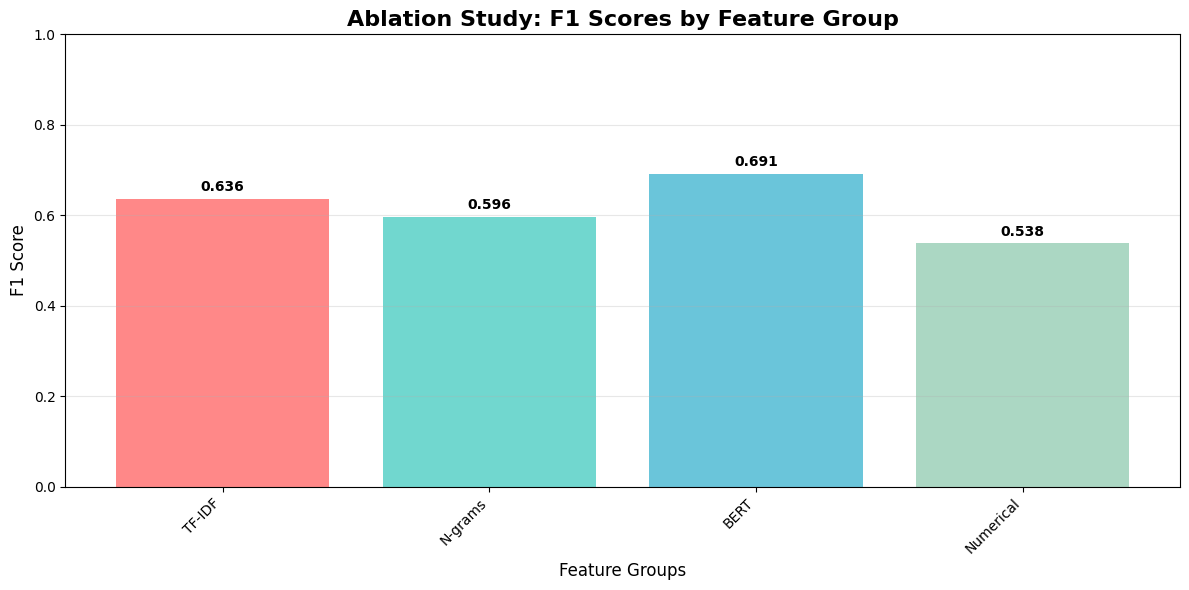

In [ ]:
from sklearn.metrics import f1_score
feature_groups = {
    'TF-IDF': range(tfidf_matrix.shape[1]),
    'N-grams': range(tfidf_matrix.shape[1], tfidf_matrix.shape[1] + ngram_matrix.shape[1]),
    'BERT': range(tfidf_matrix.shape[1] + ngram_matrix.shape[1], tfidf_matrix.shape[1] + ngram_matrix.shape[1] + bert_embeddings.shape[1]),
    'Numerical': range(tfidf_matrix.shape[1] + ngram_matrix.shape[1] + bert_embeddings.shape[1], combined_features.shape[1]),

}

def ablation_study_nb(X, y, feature_groups, model=GaussianNB()):
    # Convert sparse matrix to a format that supports indexing
    if hasattr(X, 'toarray'):
        X = X.toarray()
    elif hasattr(X, 'todense'):
        X = X.todense()

    results = {}
    for group_name, indices in feature_groups.items():
        X_subset = X[:, indices]
        model.fit(X_subset, y)
        y_pred = model.predict(X_subset)
        f1 = f1_score(y, y_pred, average='weighted')
        results[group_name] = f1
    return results

ablation_results = ablation_study_nb(combined_features, balanced_data['class'], feature_groups)

print("\n" + "="*50)
print("ABLATION STUDY RESULTS (F1 Scores)")
print("="*50)

# Create a list for plotting
groups = list(ablation_results.keys())
f1_scores = list(ablation_results.values())

# Print results
for group, f1 in ablation_results.items():
    print(f"{group}: {f1:.4f}")

# PLOT 1: Bar chart of F1 scores by feature group
plt.figure(figsize=(12, 6))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD']
bars = plt.bar(groups, f1_scores, color=colors[:len(groups)], alpha=0.8)

plt.title('Ablation Study: F1 Scores by Feature Group', fontsize=16, fontweight='bold')
plt.xlabel('Feature Groups', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.ylim(0, 1.0)
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, score in zip(bars, f1_scores):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{score:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Model Testing

In [ ]:
# Predict on the test set
y_test_pred = gaussian_naive_bayes_model.predict(X_test.toarray())

# Calculate metrics on the test set
accuracy_test = accuracy_score(y_test, y_test_pred)
precision_test = precision_score(y_test, y_test_pred, average='weighted')
recall_test = recall_score(y_test, y_test_pred, average='weighted')
f1_test = f1_score(y_test, y_test_pred, average='weighted')

print(f"Test Accuracy: {accuracy_test:.4f}")
print(f"Test Precision: {precision_test:.4f}")
print(f"Test Recall: {recall_test:.4f}")
print(f"Test F1-score: {f1_test:.4f}")
from sklearn.metrics import roc_auc_score

# Predict probabilities on the test set
y_test_proba = gaussian_naive_bayes_model.predict_proba(X_test.toarray())

# Calculate AUC score
if len(gaussian_naive_bayes_model.classes_) == 2:
    # Binary classification
    auc_score = roc_auc_score(y_test, y_test_proba[:, 1])
else:
    # Multi-class classification
    auc_score = roc_auc_score(y_test, y_test_proba, multi_class='ovr', average='weighted')

print(f"Test AUC Score: {auc_score:.4f}")
# Store metrics
store_metrics('NaiveBayes', accuracy_test, precision_test, recall_test, f1_test, auc_score)

Test Accuracy: 0.8361
Test Precision: 0.8524
Test Recall: 0.8361
Test F1-score: 0.8323
Test AUC Score: 0.8786
✓ Metrics stored for NaiveBayes


Confusion Matrix, Classification Report, Error Analysis and Feature Importance

ERROR ANALYSIS


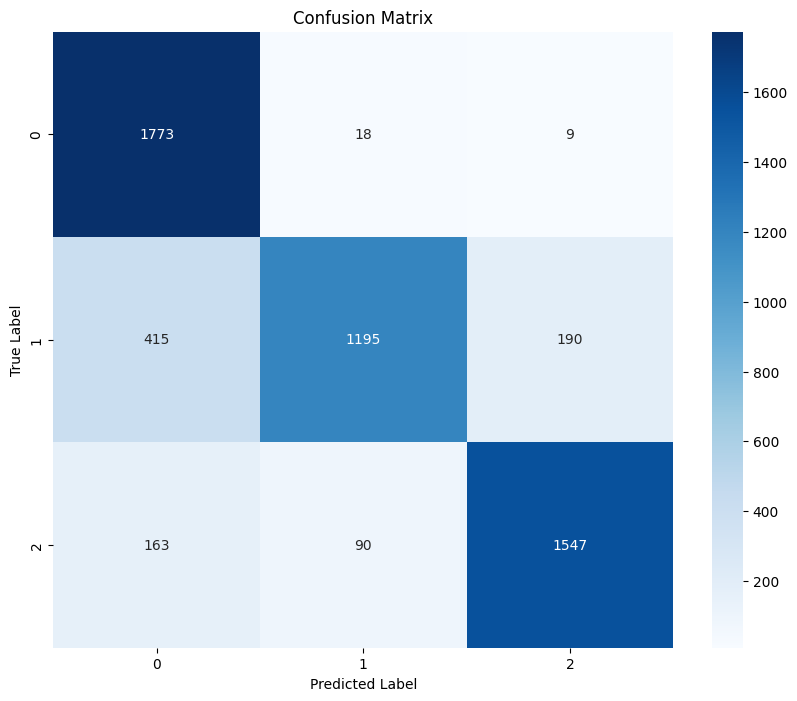


DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.75      0.98      0.85      1800
           1       0.92      0.66      0.77      1800
           2       0.89      0.86      0.87      1800

    accuracy                           0.84      5400
   macro avg       0.85      0.84      0.83      5400
weighted avg       0.85      0.84      0.83      5400


ERROR ANALYSIS DATAFRAME (First 10 errors)
Total misclassified instances: 885/5400 (16.39%)

First 10 misclassified examples:
       True_Label  Predicted_Label  Correct  True_Class_Probability  \
471             1                0    False                     0.0   
13843           2                0    False                     0.0   
6382            1                0    False                     0.0   
12727           2                1    False                     0.0   
6346            1                2    False                     0.0   
8686            1                0

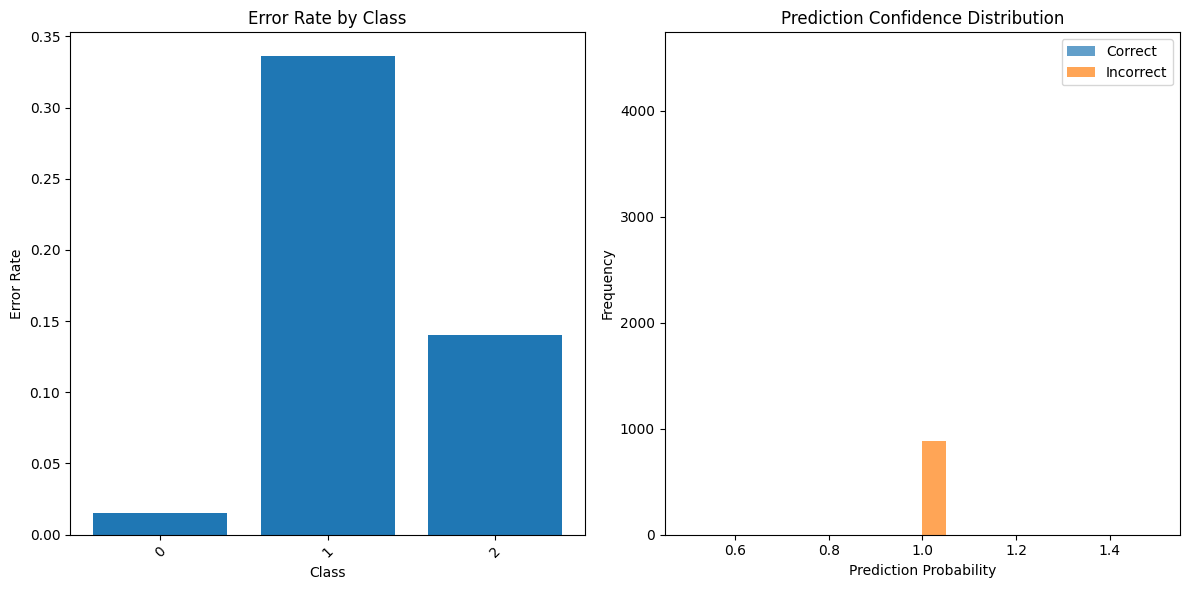

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Confusion Matrix
print("=" * 50)
print("ERROR ANALYSIS")
print("=" * 50)


# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=gaussian_naive_bayes_model.classes_,
            yticklabels=gaussian_naive_bayes_model.classes_)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# 2. Classification Report
print("\n" + "=" * 50)
print("DETAILED CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_test, y_test_pred, target_names=[str(cls) for cls in gaussian_naive_bayes_model.classes_]))

# 3. Error Analysis DataFrame
error_analysis = pd.DataFrame({
    'True_Label': y_test,
    'Predicted_Label': y_test_pred,
    'Correct': y_test == y_test_pred
})


error_analysis['True_Class_Probability'] = [y_test_proba[i, np.where(gaussian_naive_bayes_model.classes_ == true_label)[0][0]]
                                           for i, true_label in enumerate(y_test)]
error_analysis['Predicted_Class_Probability'] = [y_test_proba[i, np.where(gaussian_naive_bayes_model.classes_ == pred_label)[0][0]]
                                                for i, pred_label in enumerate(y_test_pred)]

print("\n" + "=" * 50)
print("ERROR ANALYSIS DATAFRAME (First 10 errors)")
print("=" * 50)

# Show misclassified examples
misclassified = error_analysis[~error_analysis['Correct']]
print(f"Total misclassified instances: {len(misclassified)}/{len(y_test)} ({len(misclassified)/len(y_test)*100:.2f}%)")
print("\nFirst 10 misclassified examples:")
print(misclassified.head(10))

# 4. Most common error patterns
print("\n" + "=" * 50)
print("MOST COMMON ERROR PATTERNS")
print("=" * 50)
error_patterns = misclassified.groupby(['True_Label', 'Predicted_Label']).size().reset_index(name='Count')
error_patterns = error_patterns.sort_values('Count', ascending=False)
print(error_patterns.head(10))

# 5. Class-wise performance analysis
print("\n" + "=" * 50)
print("CLASS-WISE PERFORMANCE ANALYSIS")
print("=" * 50)
class_performance = pd.DataFrame({
    'Class': gaussian_naive_bayes_model.classes_,
    'Total_Instances': [np.sum(y_test == cls) for cls in gaussian_naive_bayes_model.classes_],
    'Correct_Predictions': [np.sum((y_test == cls) & (y_test_pred == cls)) for cls in gaussian_naive_bayes_model.classes_],
    'Error_Rate': [np.sum((y_test == cls) & (y_test_pred != cls)) / np.sum(y_test == cls)
                   if np.sum(y_test == cls) > 0 else 0 for cls in gaussian_naive_bayes_model.classes_]
})

class_performance['Accuracy'] = class_performance['Correct_Predictions'] / class_performance['Total_Instances']
print(class_performance)

# 6. Probability distribution analysis for errors
print("\n" + "=" * 50)
print("PROBABILITY ANALYSIS FOR ERRORS")
print("=" * 50)
print("Probability statistics for correct predictions:")
print(error_analysis[error_analysis['Correct']]['Predicted_Class_Probability'].describe())

print("\nProbability statistics for incorrect predictions:")
print(error_analysis[~error_analysis['Correct']]['Predicted_Class_Probability'].describe())

# 7. Visualize error patterns
plt.figure(figsize=(12, 6))

# Subplot 1: Error rate by class
plt.subplot(1, 2, 1)
plt.bar(range(len(class_performance)), class_performance['Error_Rate'])
plt.xticks(range(len(class_performance)), class_performance['Class'], rotation=45)
plt.title('Error Rate by Class')
plt.xlabel('Class')
plt.ylabel('Error Rate')

# Subplot 2: Confidence in predictions
plt.subplot(1, 2, 2)
plt.hist(error_analysis[error_analysis['Correct']]['Predicted_Class_Probability'],
         alpha=0.7, label='Correct', bins=20)
plt.hist(error_analysis[~error_analysis['Correct']]['Predicted_Class_Probability'],
         alpha=0.7, label='Incorrect', bins=20)
plt.title('Prediction Confidence Distribution')
plt.xlabel('Prediction Probability')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.show()

# Logistic Regression

Model Training

In [ ]:
from sklearn.linear_model import LogisticRegression
# Convert to dense if sparse and scale features (CRUCIAL for Logistic Regression)
if hasattr(X_train, 'toarray'):
    X_train_dense = X_train.toarray()
    X_test_dense = X_test.toarray()
else:
    X_train_dense = X_train
    X_test_dense = X_test

# Scale features - IMPORTANT for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_dense)
X_test_scaled = scaler.transform(X_test_dense)

# Initialize the Logistic Regression model
logistic_regression_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    multi_class='ovr',
    solver='liblinear'
)

# Train the model on the training data
logistic_regression_model.fit(X_train_scaled, y_train)

# Predict on the training set
y_train_pred = logistic_regression_model.predict(X_train_scaled)

# Calculate metrics on the training set
accuracy_train = accuracy_score(y_train, y_train_pred)
precision_train = precision_score(y_train, y_train_pred, average='weighted')
recall_train = recall_score(y_train, y_train_pred, average='weighted')
f1_train = f1_score(y_train, y_train_pred, average='weighted')


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


In [ ]:
print(f"Training Accuracy: {accuracy_train:.4f}")
print(f"Training Precision: {precision_train:.4f}")
print(f"Training Recall: {recall_train:.4f}")
print(f"Training F1-score: {f1_train:.4f}")

Training Accuracy: 0.9990
Training Precision: 0.9990
Training Recall: 0.9990
Training F1-score: 0.9990


Ablation Study


ABLATION STUDY RESULTS (F1 Scores)
TF-IDF: 0.9878
N-grams: 0.7879
BERT: 0.8687
Numerical: 0.5865


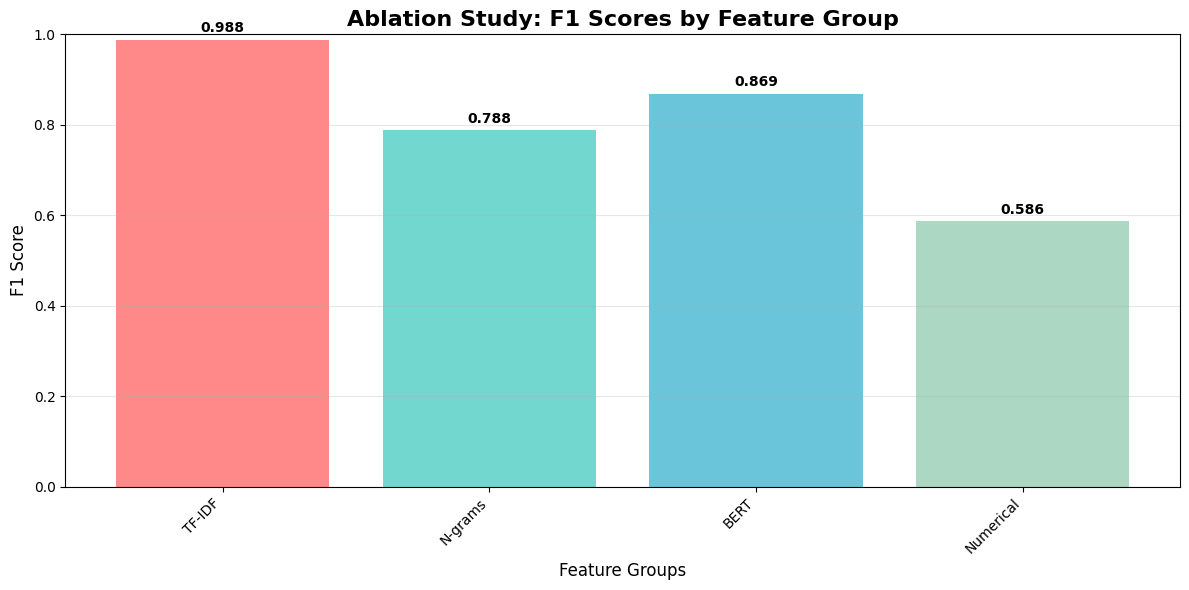

In [ ]:
# ABLATION STUDY
feature_groups = {
    'TF-IDF': range(tfidf_matrix.shape[1]),
    'N-grams': range(tfidf_matrix.shape[1], tfidf_matrix.shape[1] + ngram_matrix.shape[1]),
    'BERT': range(tfidf_matrix.shape[1] + ngram_matrix.shape[1], tfidf_matrix.shape[1] + ngram_matrix.shape[1] + bert_embeddings.shape[1]),
    'Numerical': range(tfidf_matrix.shape[1] + ngram_matrix.shape[1] + bert_embeddings.shape[1], combined_features.shape[1]),
}

def ablation_study_lr(X, y, feature_groups):
    # Convert sparse matrix to a format that supports indexing
    if hasattr(X, 'toarray'):
        X = X.toarray()
    elif hasattr(X, 'todense'):
        X = X.todense()

    results = {}
    for group_name, indices in feature_groups.items():
        X_subset = X[:, indices]

        # Scale the subset features (important for Logistic Regression)
        scaler = StandardScaler()
        X_subset_scaled = scaler.fit_transform(X_subset)

        model = LogisticRegression(random_state=42, max_iter=1000)
        model.fit(X_subset_scaled, y)
        y_pred = model.predict(X_subset_scaled)
        f1 = f1_score(y, y_pred, average='weighted')
        results[group_name] = f1
    return results

ablation_results = ablation_study_lr(combined_features, balanced_data['class'], feature_groups)

print("\n" + "="*50)
print("ABLATION STUDY RESULTS (F1 Scores)")
print("="*50)

# Create a list for plotting
groups = list(ablation_results.keys())
f1_scores = list(ablation_results.values())

# Print results
for group, f1 in ablation_results.items():
    print(f"{group}: {f1:.4f}")

# PLOT 1: Bar chart of F1 scores by feature group
plt.figure(figsize=(12, 6))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD']
bars = plt.bar(groups, f1_scores, color=colors[:len(groups)], alpha=0.8)

plt.title('Ablation Study: F1 Scores by Feature Group', fontsize=16, fontweight='bold')
plt.xlabel('Feature Groups', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.ylim(0, 1.0)
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, score in zip(bars, f1_scores):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{score:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Model Testing

In [ ]:
# Predict on the test set
y_test_pred = logistic_regression_model.predict(X_test_scaled)

# Calculate metrics on the test set
accuracy_test = accuracy_score(y_test, y_test_pred)
precision_test = precision_score(y_test, y_test_pred, average='weighted')
recall_test = recall_score(y_test, y_test_pred, average='weighted')
f1_test = f1_score(y_test, y_test_pred, average='weighted')

print(f"Test Accuracy: {accuracy_test:.4f}")
print(f"Test Precision: {precision_test:.4f}")
print(f"Test Recall: {recall_test:.4f}")
print(f"Test F1-score: {f1_test:.4f}")

# Predict probabilities on the test set
y_test_proba = logistic_regression_model.predict_proba(X_test_scaled)

# Calculate AUC score
if len(logistic_regression_model.classes_) == 2:
    auc_score = roc_auc_score(y_test, y_test_proba[:, 1])
else:
    auc_score = roc_auc_score(y_test, y_test_proba, multi_class='ovr', average='weighted')

print(f"Test AUC Score: {auc_score:.4f}")

store_metrics('LogisticRegression', accuracy_test, precision_test, recall_test, f1_test, auc_score)

Test Accuracy: 0.9361
Test Precision: 0.9376
Test Recall: 0.9361
Test F1-score: 0.9353
Test AUC Score: 0.9769
✓ Metrics stored for LogisticRegression


Error Analysis, Confusion Matrix, Classification Report, Feature Importance


ERROR ANALYSIS


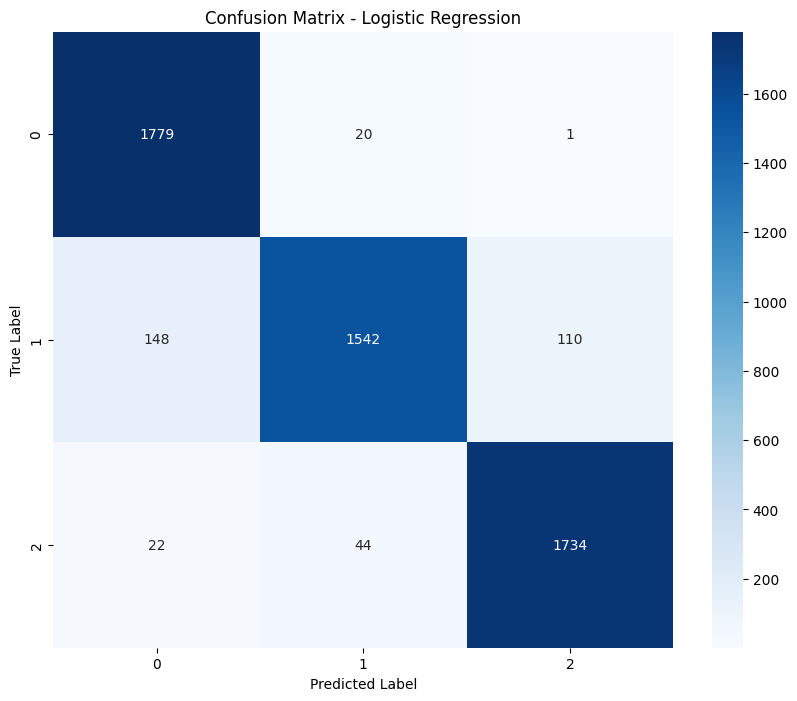


DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.91      0.99      0.95      1800
           1       0.96      0.86      0.91      1800
           2       0.94      0.96      0.95      1800

    accuracy                           0.94      5400
   macro avg       0.94      0.94      0.94      5400
weighted avg       0.94      0.94      0.94      5400


ERROR ANALYSIS DATAFRAME (First 10 errors)
Total misclassified instances: 345/5400 (6.39%)

First 10 misclassified examples:
       True_Label  Predicted_Label  Correct  True_Class_Probability  \
1779            1                2    False                0.000029   
4086            1                0    False                0.080641   
6382            1                0    False                0.000142   
5013            1                0    False                0.336287   
8226            1                0    False                0.000054   
8686            1                0 

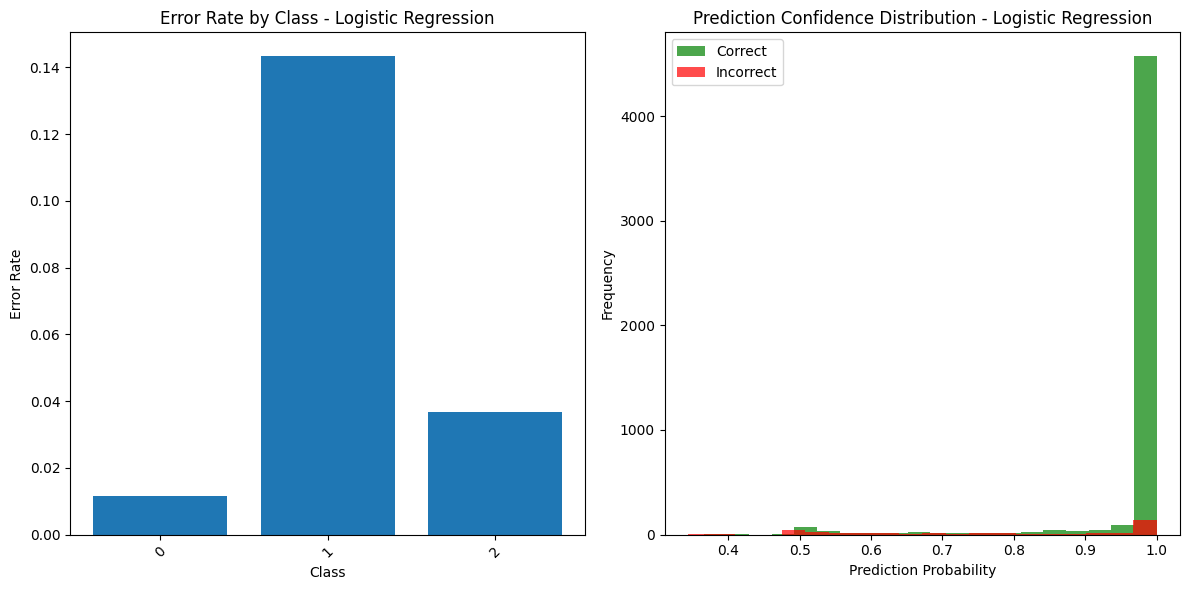


FEATURE IMPORTANCE ANALYSIS (Coefficients)
Average absolute coefficients by feature group:
Numerical: 0.2381
BERT: 0.1214
N-grams: 0.0772
TF-IDF: 0.0651


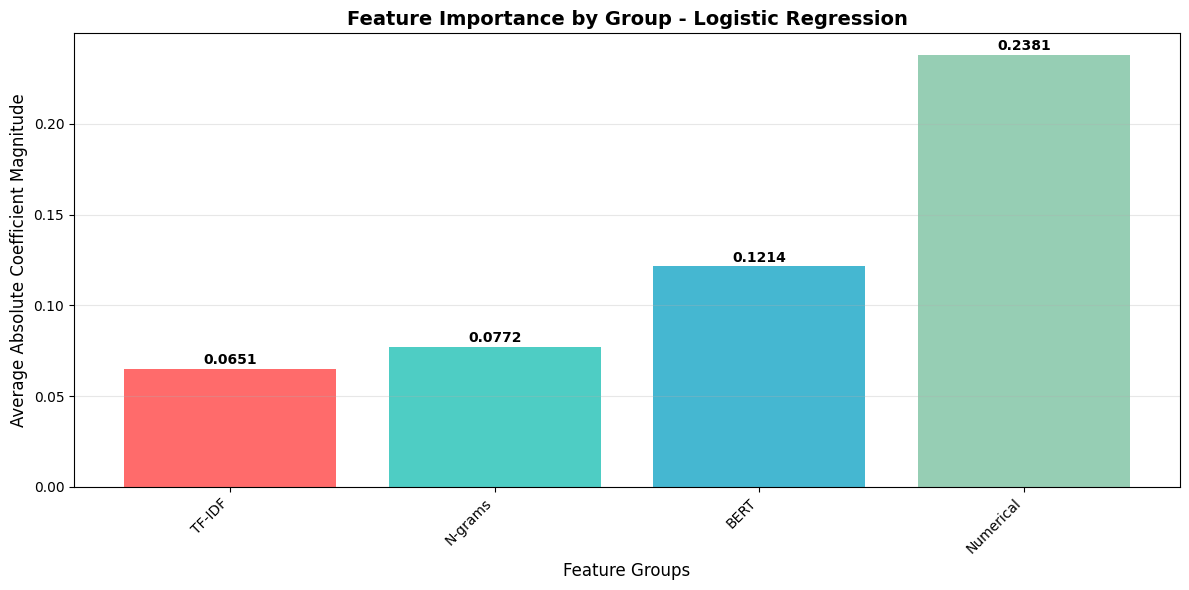


DETAILED FEATURE IMPORTANCE ANALYSIS

Top 5 features in 'TF-IDF':
  Feature 528: 0.7256
  Feature 3454: 0.6986
  Feature 529: 0.5780
  Feature 2069: 0.5482
  Feature 3048: 0.4990

Top 5 features in 'N-grams':
  Feature 5778: 0.5422
  Feature 6172: 0.3187
  Feature 5449: 0.3135
  Feature 5137: 0.3033
  Feature 6839: 0.2905

Top 5 features in 'BERT':
  Feature 7623: 0.3707
  Feature 7667: 0.3657
  Feature 7116: 0.3505
  Feature 7318: 0.3466
  Feature 7657: 0.3136

Top 5 features in 'Numerical':
  Feature 7768: 0.6154
  Feature 7770: 0.5439
  Feature 7776: 0.4202
  Feature 7777: 0.4028
  Feature 7773: 0.3320


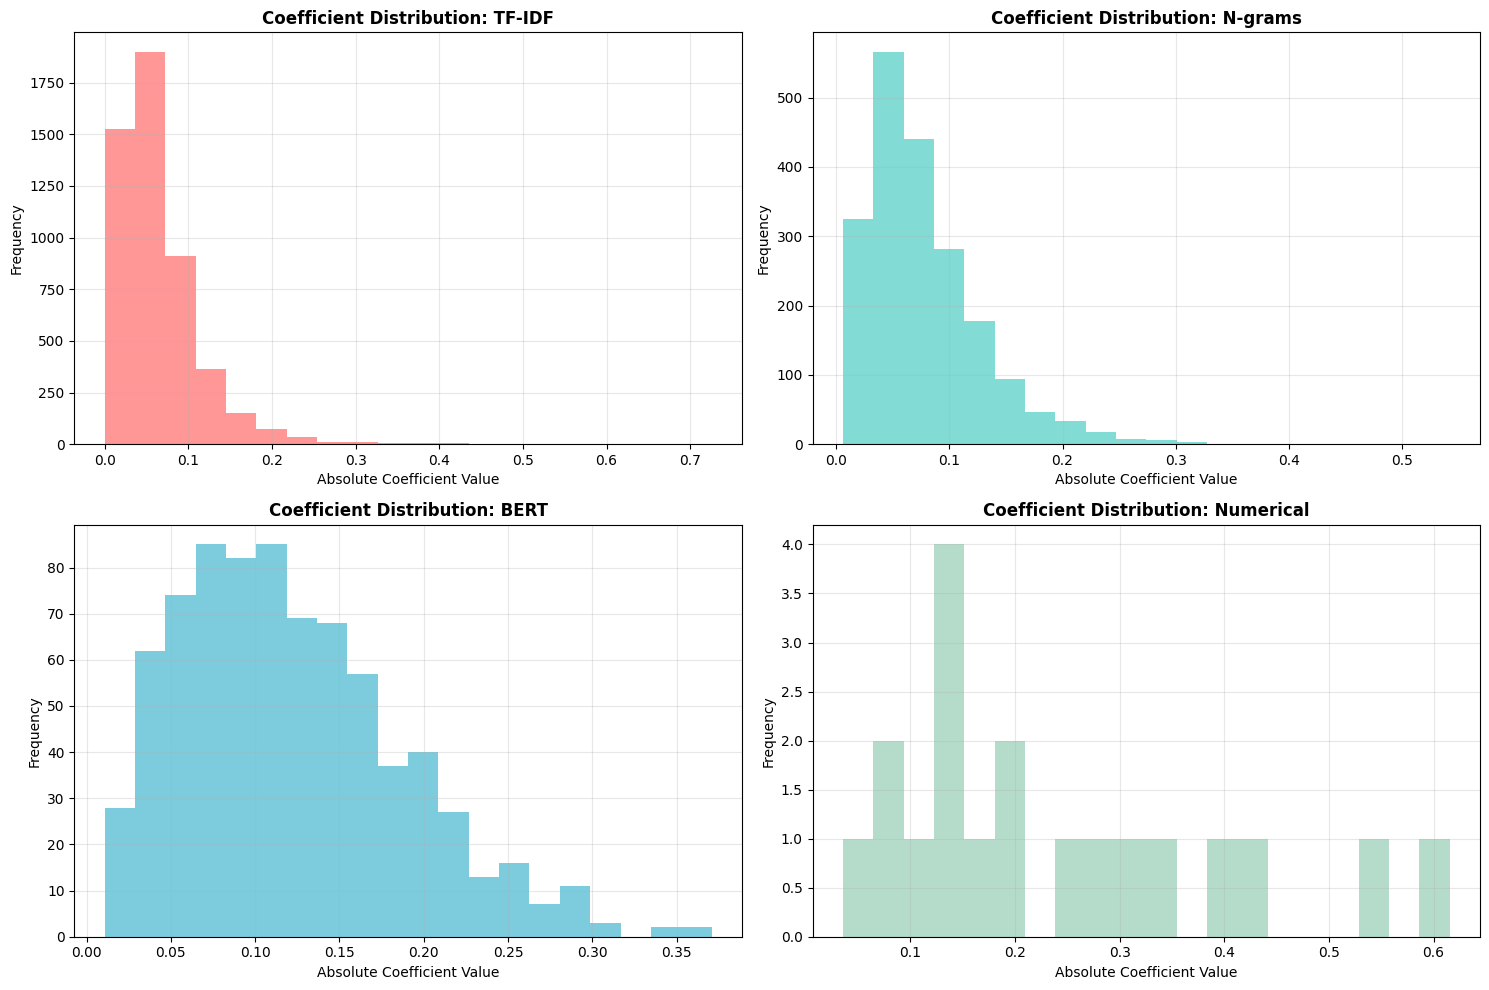


FEATURE IMPORTANCE SUMMARY
Most important feature group: Numerical (0.2381)
Least important feature group: TF-IDF (0.0651)
Importance ratio (most/least): 3.66x

Recommendations based on feature importance:
✓ Numerical: High importance - consider feature engineering
✓ BERT: High importance - consider feature engineering
○ N-grams: Medium importance - keep as is
○ TF-IDF: Medium importance - keep as is


In [ ]:
# ERROR ANALYSIS
print("\n" + "="*50)
print("ERROR ANALYSIS")
print("="*50)

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=logistic_regression_model.classes_,
            yticklabels=logistic_regression_model.classes_)
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Classification Report
print("\nDETAILED CLASSIFICATION REPORT")
print(classification_report(y_test, y_test_pred, target_names=[str(cls) for cls in logistic_regression_model.classes_]))

# Error Analysis DataFrame
error_analysis = pd.DataFrame({
    'True_Label': y_test,
    'Predicted_Label': y_test_pred,
    'Correct': y_test == y_test_pred
})

# Add probabilities for the true and predicted classes
error_analysis['True_Class_Probability'] = [y_test_proba[i, np.where(logistic_regression_model.classes_ == true_label)[0][0]]
                                           for i, true_label in enumerate(y_test)]
error_analysis['Predicted_Class_Probability'] = [y_test_proba[i, np.where(logistic_regression_model.classes_ == pred_label)[0][0]]
                                                for i, pred_label in enumerate(y_test_pred)]

print("\nERROR ANALYSIS DATAFRAME (First 10 errors)")
# Show misclassified examples
misclassified = error_analysis[~error_analysis['Correct']]
print(f"Total misclassified instances: {len(misclassified)}/{len(y_test)} ({len(misclassified)/len(y_test)*100:.2f}%)")
print("\nFirst 10 misclassified examples:")
print(misclassified.head(10))

# Most common error patterns
print("\nMOST COMMON ERROR PATTERNS")
error_patterns = misclassified.groupby(['True_Label', 'Predicted_Label']).size().reset_index(name='Count')
error_patterns = error_patterns.sort_values('Count', ascending=False)
print(error_patterns.head(10))

# Class-wise performance analysis
print("\nCLASS-WISE PERFORMANCE ANALYSIS")
class_performance = pd.DataFrame({
    'Class': logistic_regression_model.classes_,
    'Total_Instances': [np.sum(y_test == cls) for cls in logistic_regression_model.classes_],
    'Correct_Predictions': [np.sum((y_test == cls) & (y_test_pred == cls)) for cls in logistic_regression_model.classes_],
    'Error_Rate': [np.sum((y_test == cls) & (y_test_pred != cls)) / np.sum(y_test == cls)
                   if np.sum(y_test == cls) > 0 else 0 for cls in logistic_regression_model.classes_]
})

class_performance['Accuracy'] = class_performance['Correct_Predictions'] / class_performance['Total_Instances']
print(class_performance)

# Probability distribution analysis for errors
print("\nPROBABILITY ANALYSIS FOR ERRORS")
print("Probability statistics for correct predictions:")
print(error_analysis[error_analysis['Correct']]['Predicted_Class_Probability'].describe())

print("\nProbability statistics for incorrect predictions:")
print(error_analysis[~error_analysis['Correct']]['Predicted_Class_Probability'].describe())

# Visualize error patterns
plt.figure(figsize=(12, 6))

# Subplot 1: Error rate by class
plt.subplot(1, 2, 1)
plt.bar(range(len(class_performance)), class_performance['Error_Rate'])
plt.xticks(range(len(class_performance)), class_performance['Class'], rotation=45)
plt.title('Error Rate by Class - Logistic Regression')
plt.xlabel('Class')
plt.ylabel('Error Rate')

# Subplot 2: Confidence in predictions
plt.subplot(1, 2, 2)
plt.hist(error_analysis[error_analysis['Correct']]['Predicted_Class_Probability'],
         alpha=0.7, label='Correct', bins=20, color='green')
plt.hist(error_analysis[~error_analysis['Correct']]['Predicted_Class_Probability'],
         alpha=0.7, label='Incorrect', bins=20, color='red')
plt.title('Prediction Confidence Distribution - Logistic Regression')
plt.xlabel('Prediction Probability')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("FEATURE IMPORTANCE ANALYSIS (Coefficients)")
print("="*50)

# Convert range objects to numpy arrays first
import numpy as np

# Get average absolute coefficients for each feature group
feature_importance_by_group = {}
for group_name, indices in feature_groups.items():
    if len(indices) > 0:
        # Convert range to numpy array
        indices_array = np.array(list(indices))
        if len(logistic_regression_model.coef_.shape) == 2:  # multi-class
            group_importance = np.mean(np.abs(logistic_regression_model.coef_[:, indices_array]))
        else:  # binary classification
            group_importance = np.mean(np.abs(logistic_regression_model.coef_[indices_array]))
        feature_importance_by_group[group_name] = group_importance

print("Average absolute coefficients by feature group:")
for group, importance in sorted(feature_importance_by_group.items(), key=lambda x: x[1], reverse=True):
    print(f"{group}: {importance:.4f}")

# PLOT FEATURE IMPORTANCE BY GROUP
plt.figure(figsize=(12, 6))

# Bar plot for feature group importance
groups = list(feature_importance_by_group.keys())
importances = list(feature_importance_by_group.values())

# Create bar plot with colors
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD']
bars = plt.bar(range(len(groups)), importances, color=colors[:len(groups)])

plt.title('Feature Importance by Group - Logistic Regression', fontsize=14, fontweight='bold')
plt.xlabel('Feature Groups', fontsize=12)
plt.ylabel('Average Absolute Coefficient Magnitude', fontsize=12)
plt.xticks(range(len(groups)), groups, rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add value labels on top of bars
for bar, importance in zip(bars, importances):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.001,
             f'{importance:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# ADDITIONAL: INDIVIDUAL FEATURE IMPORTANCE WITHIN GROUPS
print("\n" + "="*50)
print("DETAILED FEATURE IMPORTANCE ANALYSIS")
print("="*50)

# Analyze top features within each group
for group_name, indices in feature_groups.items():
    if len(indices) > 0:
        # Convert range to numpy array
        indices_array = np.array(list(indices))

        if len(logistic_regression_model.coef_.shape) == 2:
            # For multi-class, take mean across classes
            group_coefs = np.mean(np.abs(logistic_regression_model.coef_[:, indices_array]), axis=0)
        else:
            group_coefs = np.abs(logistic_regression_model.coef_[indices_array])

        # Get top 5 features in this group
        top_indices = np.argsort(group_coefs)[-5:][::-1]
        top_features = indices_array[top_indices]  # Use the numpy array for indexing
        top_importances = group_coefs[top_indices]

        print(f"\nTop 5 features in '{group_name}':")
        for feat_idx, importance in zip(top_features, top_importances):
            print(f"  Feature {feat_idx}: {importance:.4f}")

# PLOT COEFFICIENT DISTRIBUTION FOR EACH GROUP
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, (group_name, indices) in enumerate(feature_groups.items()):
    if i >= len(axes):
        break

    if len(indices) > 0:
        # Convert range to numpy array
        indices_array = np.array(list(indices))

        if len(logistic_regression_model.coef_.shape) == 2:
            group_coefs = np.mean(np.abs(logistic_regression_model.coef_[:, indices_array]), axis=0)
        else:
            group_coefs = np.abs(logistic_regression_model.coef_[indices_array])

        axes[i].hist(group_coefs, bins=20, alpha=0.7, color=colors[i])
        axes[i].set_title(f'Coefficient Distribution: {group_name}', fontweight='bold')
        axes[i].set_xlabel('Absolute Coefficient Value')
        axes[i].set_ylabel('Frequency')
        axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# SUMMARY OF FEATURE IMPORTANCE FINDINGS
print("\n" + "="*60)
print("FEATURE IMPORTANCE SUMMARY")
print("="*60)

# Find most and least important groups
most_important_group = max(feature_importance_by_group, key=feature_importance_by_group.get)
least_important_group = min(feature_importance_by_group, key=feature_importance_by_group.get)

print(f"Most important feature group: {most_important_group} ({feature_importance_by_group[most_important_group]:.4f})")
print(f"Least important feature group: {least_important_group} ({feature_importance_by_group[least_important_group]:.4f})")

# Calculate importance ratio
if feature_importance_by_group[least_important_group] > 0:
    importance_ratio = feature_importance_by_group[most_important_group] / feature_importance_by_group[least_important_group]
    print(f"Importance ratio (most/least): {importance_ratio:.2f}x")
else:
    print("Least important group has zero importance - ratio cannot be calculated")

print("\nRecommendations based on feature importance:")
for group, importance in sorted(feature_importance_by_group.items(), key=lambda x: x[1], reverse=True):
    if importance > 0.1:
        print(f"✓ {group}: High importance - consider feature engineering")
    elif importance > 0.01:
        print(f"○ {group}: Medium importance - keep as is")
    else:
        print(f"✗ {group}: Low importance - consider removing or reducing")

# Random Forest Classifier

Model Training

In [ ]:
from sklearn.ensemble import RandomForestClassifier
# Initialize the Random Forest model
random_forest_model = RandomForestClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight='balanced'  # Helps with imbalanced data
)

# Train the model on the training data
random_forest_model.fit(X_train_dense, y_train)

# Predict on the training set
y_train_pred = random_forest_model.predict(X_train_dense)

# Calculate metrics on the training set
accuracy_train = accuracy_score(y_train, y_train_pred)
precision_train = precision_score(y_train, y_train_pred, average='weighted')
recall_train = recall_score(y_train, y_train_pred, average='weighted')
f1_train = f1_score(y_train, y_train_pred, average='weighted')

print("\n" + "="*50)
print("TRAINING SET PERFORMANCE")
print("="*50)
print(f"Training Accuracy: {accuracy_train:.4f}")
print(f"Training Precision: {precision_train:.4f}")
print(f"Training Recall: {recall_train:.4f}")
print(f"Training F1-score: {f1_train:.4f}")


TRAINING SET PERFORMANCE
Training Accuracy: 0.9999
Training Precision: 0.9999
Training Recall: 0.9999
Training F1-score: 0.9999



ABLATION STUDY RESULTS (F1 Scores)
TF-IDF: 0.9952
N-grams: 0.8669
BERT: 0.9989
Numerical: 0.9985


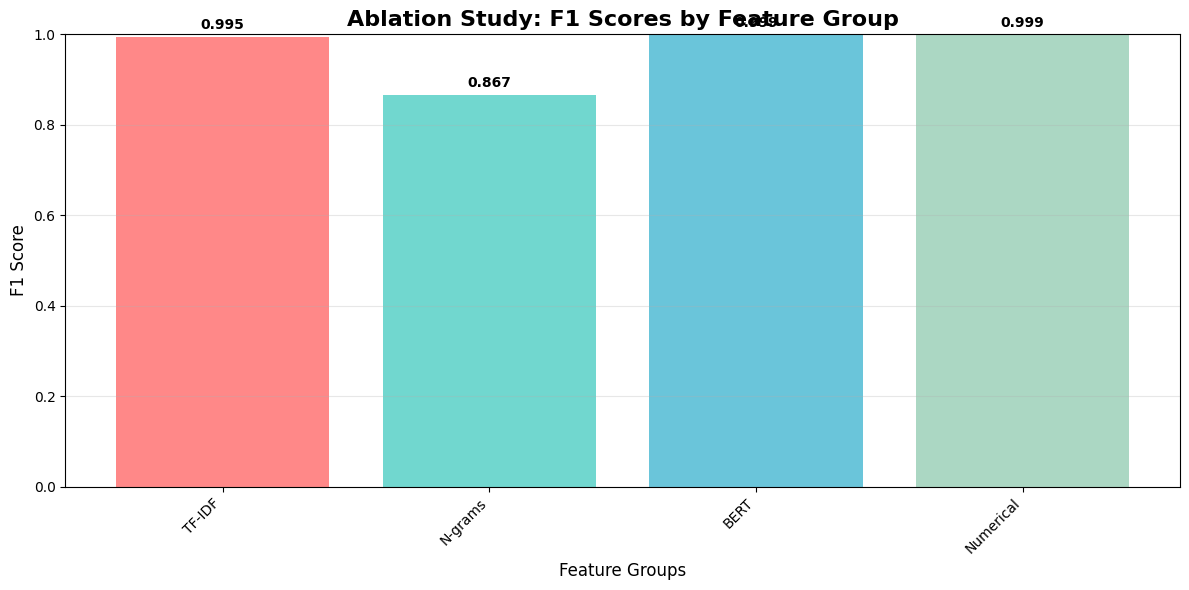

In [ ]:
# ABLATION STUDY
feature_groups = {
    'TF-IDF': range(tfidf_matrix.shape[1]),
    'N-grams': range(tfidf_matrix.shape[1], tfidf_matrix.shape[1] + ngram_matrix.shape[1]),
    'BERT': range(tfidf_matrix.shape[1] + ngram_matrix.shape[1], tfidf_matrix.shape[1] + ngram_matrix.shape[1] + bert_embeddings.shape[1]),
    'Numerical': range(tfidf_matrix.shape[1] + ngram_matrix.shape[1] + bert_embeddings.shape[1], combined_features.shape[1]),
}

def ablation_study_rf(X, y, feature_groups):
    # Convert sparse matrix to a format that supports indexing
    if hasattr(X, 'toarray'):
        X = X.toarray()
    elif hasattr(X, 'todense'):
        X = X.todense()

    results = {}
    for group_name, indices in feature_groups.items():
        X_subset = X[:, indices]

        model = RandomForestClassifier(random_state=42, n_estimators=50, class_weight='balanced')
        model.fit(X_subset, y)
        y_pred = model.predict(X_subset)
        f1 = f1_score(y, y_pred, average='weighted')
        results[group_name] = f1
    return results

ablation_results = ablation_study_rf(combined_features, balanced_data['class'], feature_groups)

print("\n" + "="*50)
print("ABLATION STUDY RESULTS (F1 Scores)")
print("="*50)

# Create a list for plotting
groups = list(ablation_results.keys())
f1_scores = list(ablation_results.values())

# Print results
for group, f1 in ablation_results.items():
    print(f"{group}: {f1:.4f}")

# PLOT 1: Bar chart of F1 scores by feature group
plt.figure(figsize=(12, 6))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD']
bars = plt.bar(groups, f1_scores, color=colors[:len(groups)], alpha=0.8)

plt.title('Ablation Study: F1 Scores by Feature Group', fontsize=16, fontweight='bold')
plt.xlabel('Feature Groups', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.ylim(0, 1.0)
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, score in zip(bars, f1_scores):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{score:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Model Testing

In [ ]:
# Predict on the test set
y_test_pred = random_forest_model.predict(X_test_dense)

# Calculate metrics on the test set
accuracy_test = accuracy_score(y_test, y_test_pred)
precision_test = precision_score(y_test, y_test_pred, average='weighted')
recall_test = recall_score(y_test, y_test_pred, average='weighted')
f1_test = f1_score(y_test, y_test_pred, average='weighted')

print(f"Test Accuracy: {accuracy_test:.4f}")
print(f"Test Precision: {precision_test:.4f}")
print(f"Test Recall: {recall_test:.4f}")
print(f"Test F1-score: {f1_test:.4f}")

# Predict probabilities on the test set
y_test_proba = random_forest_model.predict_proba(X_test_dense)
# Calculate AUC score
if len(random_forest_model.classes_) == 2:
    auc_score = roc_auc_score(y_test, y_test_proba[:, 1])
else:
    auc_score = roc_auc_score(y_test, y_test_proba, multi_class='ovr', average='weighted')

print(f"Test AUC Score: {auc_score:.4f}")
store_metrics('RandomForest', accuracy_test, precision_test, recall_test, f1_test, auc_score)

Test Accuracy: 0.9381
Test Precision: 0.9394
Test Recall: 0.9381
Test F1-score: 0.9384
Test AUC Score: 0.9904
✓ Metrics stored for RandomForest


Error Analysis, Confusion Matrix, Classification Report, Feature Importance


ERROR ANALYSIS


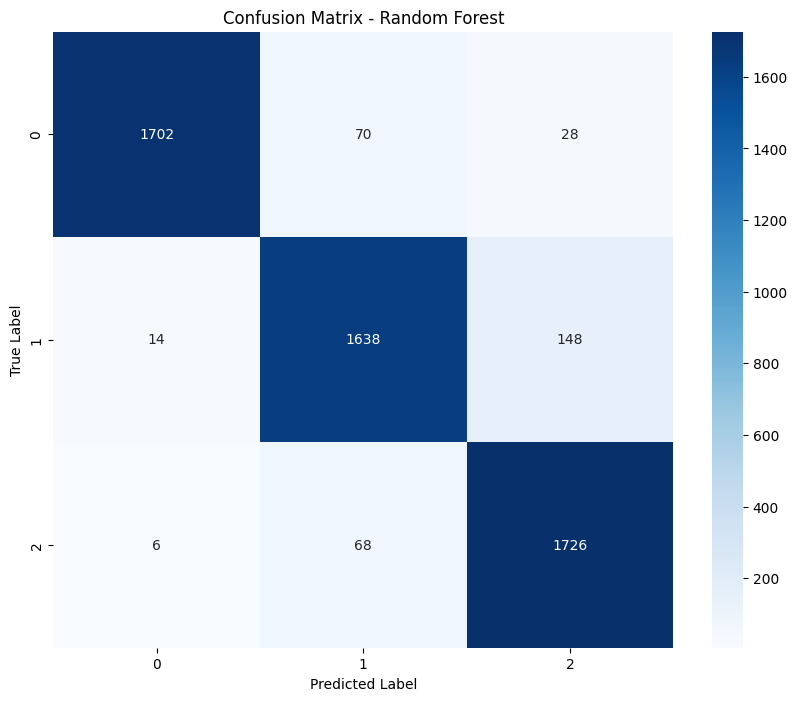


DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.99      0.95      0.97      1800
           1       0.92      0.91      0.92      1800
           2       0.91      0.96      0.93      1800

    accuracy                           0.94      5400
   macro avg       0.94      0.94      0.94      5400
weighted avg       0.94      0.94      0.94      5400


ERROR ANALYSIS DATAFRAME (First 10 errors)
Total misclassified instances: 334/5400 (6.19%)

First 10 misclassified examples:
       True_Label  Predicted_Label  Correct  True_Class_Probability  \
1779            1                2    False                    0.34   
734             1                2    False                    0.39   
2332            1                0    False                    0.29   
10301           0                2    False                    0.20   
1724            1                2    False                    0.39   
21494           0                1 

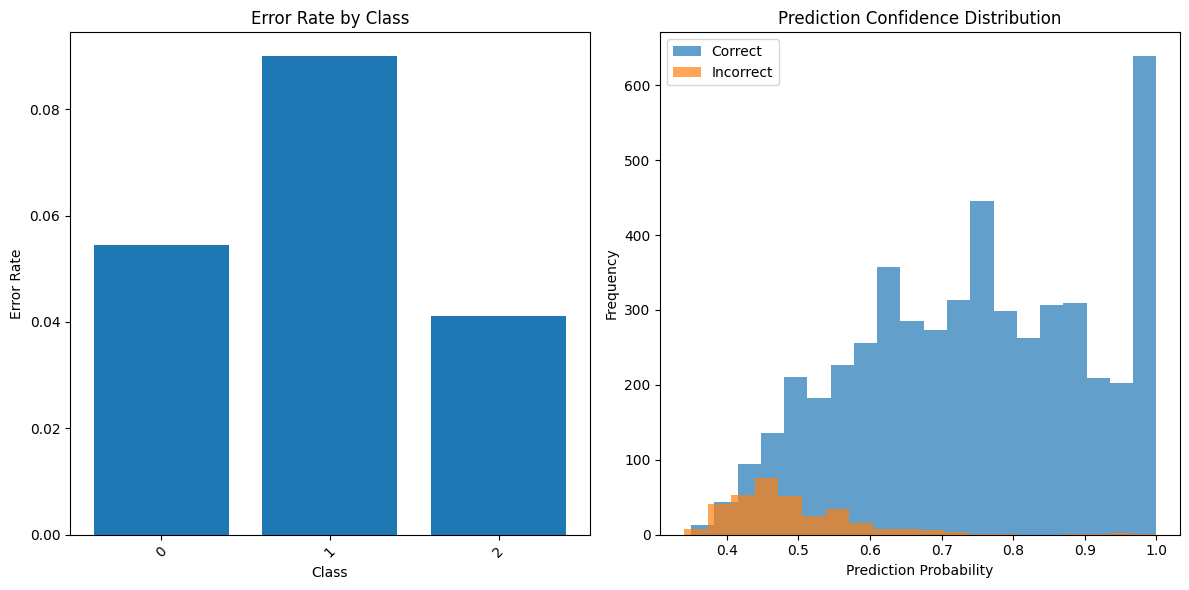


FEATURE IMPORTANCE ANALYSIS (Random Forest)
Average feature importance by feature group:
Numerical: 0.0013
BERT: 0.0012
TF-IDF: 0.0000
N-grams: 0.0000


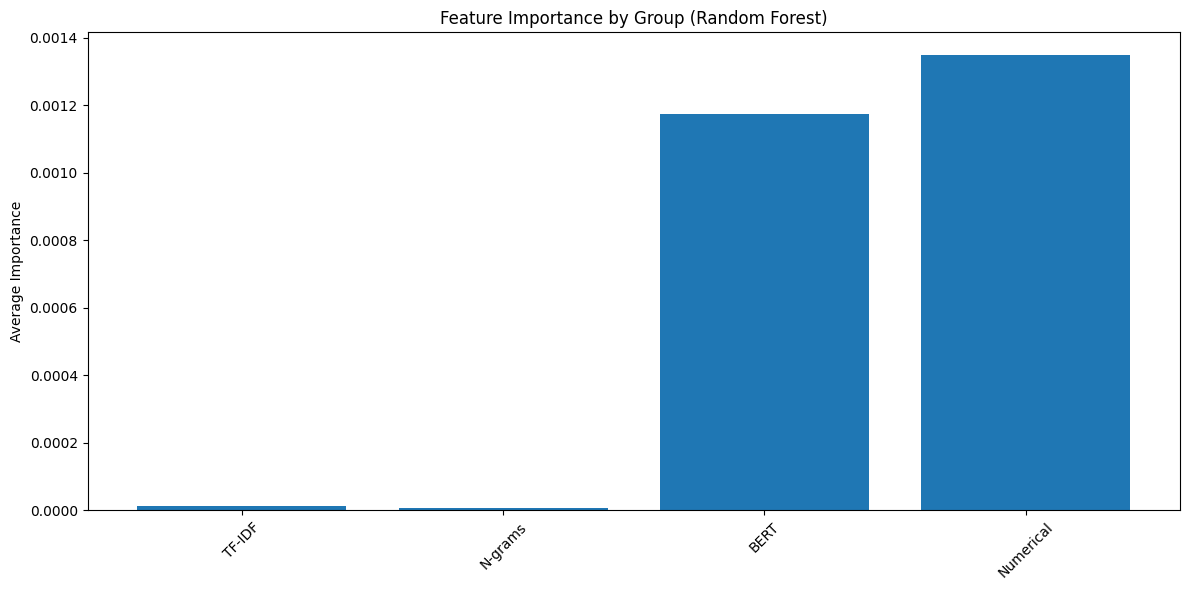

In [ ]:
# ERROR ANALYSIS
print("\n" + "="*50)
print("ERROR ANALYSIS")
print("="*50)

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=random_forest_model.classes_,
            yticklabels=random_forest_model.classes_)
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Classification Report
print("\nDETAILED CLASSIFICATION REPORT")
print(classification_report(y_test, y_test_pred, target_names=[str(cls) for cls in random_forest_model.classes_]))

# Error Analysis DataFrame
error_analysis = pd.DataFrame({
    'True_Label': y_test,
    'Predicted_Label': y_test_pred,
    'Correct': y_test == y_test_pred
})

# Add probabilities for the true and predicted classes
error_analysis['True_Class_Probability'] = [y_test_proba[i, np.where(random_forest_model.classes_ == true_label)[0][0]]
                                           for i, true_label in enumerate(y_test)]
error_analysis['Predicted_Class_Probability'] = [y_test_proba[i, np.where(random_forest_model.classes_ == pred_label)[0][0]]
                                                for i, pred_label in enumerate(y_test_pred)]

print("\nERROR ANALYSIS DATAFRAME (First 10 errors)")
# Show misclassified examples
misclassified = error_analysis[~error_analysis['Correct']]
print(f"Total misclassified instances: {len(misclassified)}/{len(y_test)} ({len(misclassified)/len(y_test)*100:.2f}%)")
print("\nFirst 10 misclassified examples:")
print(misclassified.head(10))

# Most common error patterns
print("\nMOST COMMON ERROR PATTERNS")
error_patterns = misclassified.groupby(['True_Label', 'Predicted_Label']).size().reset_index(name='Count')
error_patterns = error_patterns.sort_values('Count', ascending=False)
print(error_patterns.head(10))

# Class-wise performance analysis
print("\nCLASS-WISE PERFORMANCE ANALYSIS")
class_performance = pd.DataFrame({
    'Class': random_forest_model.classes_,
    'Total_Instances': [np.sum(y_test == cls) for cls in random_forest_model.classes_],
    'Correct_Predictions': [np.sum((y_test == cls) & (y_test_pred == cls)) for cls in random_forest_model.classes_],
    'Error_Rate': [np.sum((y_test == cls) & (y_test_pred != cls)) / np.sum(y_test == cls)
                   if np.sum(y_test == cls) > 0 else 0 for cls in random_forest_model.classes_]
})

class_performance['Accuracy'] = class_performance['Correct_Predictions'] / class_performance['Total_Instances']
print(class_performance)

# Probability distribution analysis for errors
print("\nPROBABILITY ANALYSIS FOR ERRORS")
print("Probability statistics for correct predictions:")
print(error_analysis[error_analysis['Correct']]['Predicted_Class_Probability'].describe())

print("\nProbability statistics for incorrect predictions:")
print(error_analysis[~error_analysis['Correct']]['Predicted_Class_Probability'].describe())

# Visualize error patterns
plt.figure(figsize=(12, 6))

# Subplot 1: Error rate by class
plt.subplot(1, 2, 1)
plt.bar(range(len(class_performance)), class_performance['Error_Rate'])
plt.xticks(range(len(class_performance)), class_performance['Class'], rotation=45)
plt.title('Error Rate by Class')
plt.xlabel('Class')
plt.ylabel('Error Rate')

# Subplot 2: Confidence in predictions
plt.subplot(1, 2, 2)
plt.hist(error_analysis[error_analysis['Correct']]['Predicted_Class_Probability'],
         alpha=0.7, label='Correct', bins=20)
plt.hist(error_analysis[~error_analysis['Correct']]['Predicted_Class_Probability'],
         alpha=0.7, label='Incorrect', bins=20)
plt.title('Prediction Confidence Distribution')
plt.xlabel('Prediction Probability')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.show()

# FEATURE IMPORTANCE ANALYSIS (Specific to Random Forest)
print("\n" + "="*50)
print("FEATURE IMPORTANCE ANALYSIS (Random Forest)")
print("="*50)

# Get feature importances from the trained model
feature_importances = random_forest_model.feature_importances_

# Get average feature importance for each feature group
feature_importance_by_group = {}
for group_name, indices in feature_groups.items():
    if len(indices) > 0:
        group_importance = np.mean(feature_importances[indices])
        feature_importance_by_group[group_name] = group_importance

print("Average feature importance by feature group:")
for group, importance in sorted(feature_importance_by_group.items(), key=lambda x: x[1], reverse=True):
    print(f"{group}: {importance:.4f}")

# Plot feature importances
plt.figure(figsize=(12, 6))
plt.bar(range(len(feature_importance_by_group)), list(feature_importance_by_group.values()))
plt.xticks(range(len(feature_importance_by_group)), list(feature_importance_by_group.keys()), rotation=45)
plt.title('Feature Importance by Group (Random Forest)')
plt.ylabel('Average Importance')
plt.tight_layout()
plt.show()

# XGBoost

Model Training

In [ ]:
from xgboost import XGBClassifier

# Convert to dense if sparse (XGBoost prefers dense arrays)
if hasattr(X_train, 'toarray'):
    X_train_dense = X_train.toarray()
    X_test_dense = X_test.toarray()
else:
    X_train_dense = X_train
    X_test_dense = X_test

# XGBoost doesn't require feature scaling!
# Initialize XGBoost model
xgb_model = XGBClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss'  # for multi-class
)

# Train the model
print("\nTraining XGBoost model...")
xgb_model.fit(X_train_dense, y_train)

# Predict on the training set
y_train_pred = xgb_model.predict(X_train_dense)
y_train_proba = xgb_model.predict_proba(X_train_dense)

# Calculate metrics
accuracy_train = accuracy_score(y_train, y_train_pred)
precision_train = precision_score(y_train, y_train_pred, average='weighted')
recall_train = recall_score(y_train, y_train_pred, average='weighted')
f1_train = f1_score(y_train, y_train_pred, average='weighted')

print("\n" + "="*50)
print("TRAINING SET PERFORMANCE")
print("="*50)
print(f"Training Accuracy: {accuracy_train:.4f}")
print(f"Training Precision: {precision_train:.4f}")
print(f"Training Recall: {recall_train:.4f}")
print(f"Training F1-score: {f1_train:.4f}")


Training XGBoost model...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [12:33:30] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



TRAINING SET PERFORMANCE
Training Accuracy: 0.9745
Training Precision: 0.9748
Training Recall: 0.9745
Training F1-score: 0.9744


Model Testing

In [ ]:
y_test_pred = xgb_model.predict(X_test_dense)
y_test_proba = xgb_model.predict_proba(X_test_dense)

accuracy_test = accuracy_score(y_test, y_test_pred)
precision_test = precision_score(y_test, y_test_pred, average='weighted')
recall_test = recall_score(y_test, y_test_pred, average='weighted')
f1_test = f1_score(y_test, y_test_pred, average='weighted')

print(f"Test Accuracy: {accuracy_test:.4f}")
print(f"Test Precision: {precision_test:.4f}")
print(f"Test Recall: {recall_test:.4f}")
print(f"Test F1-score: {f1_test:.4f}")
# Calculate AUC score
if len(xgb_model.classes_) == 2:
    auc_score = roc_auc_score(y_test, y_test_proba[:, 1])
else:
    auc_score = roc_auc_score(y_test, y_test_proba, multi_class='ovr', average='weighted')
print(f"Test AUC Score: {auc_score:.4f}")


store_metrics('XGBoost', accuracy_test, precision_test, recall_test, f1_test, auc_score)

Test Accuracy: 0.9370
Test Precision: 0.9379
Test Recall: 0.9370
Test F1-score: 0.9366
Test AUC Score: 0.9878
✓ Metrics stored for XGBoost


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [12:35:21] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [12:35:26] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [12:35:29] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [12:35:34] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



ABLATION STUDY RESULTS (F1 Scores)
TF-IDF: 0.8433
N-grams: 0.5545
BERT: 0.9269
Numerical: 0.6870


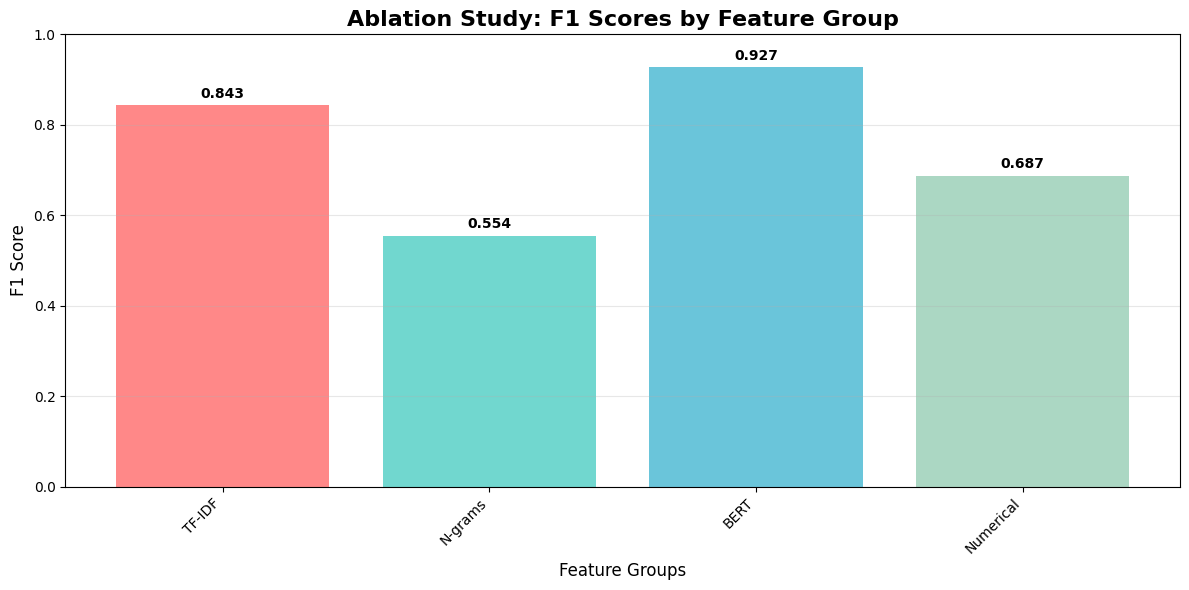

In [ ]:
def ablation_study_xgb(X, y, feature_groups):
    results = {}

    # Convert to dense array if it's a sparse matrix
    if hasattr(X, 'toarray'):
        X_dense = X.toarray()
    elif hasattr(X, 'todense'):
        X_dense = X.todense()
    else:
        X_dense = X

    for group_name, indices in feature_groups.items():
        if len(indices) == 0:
            continue

        # Convert indices to list if it's a range object
        if isinstance(indices, range):
            indices = list(indices)

        X_subset = X_dense[:, indices]

        model = XGBClassifier(
            n_estimators=50,
            max_depth=4,
            random_state=42,
            use_label_encoder=False,
            eval_metric='mlogloss'
        )
        model.fit(X_subset, y)

        y_pred = model.predict(X_subset)
        f1 = f1_score(y, y_pred, average='weighted')
        results[group_name] = f1

    return results

# Now run the ablation study
ablation_results = ablation_study_xgb(combined_features, balanced_data['class'], feature_groups)

print("\n" + "="*50)
print("ABLATION STUDY RESULTS (F1 Scores)")
print("="*50)

# Create a list for plotting
groups = list(ablation_results.keys())
f1_scores = list(ablation_results.values())

# Print results
for group, f1 in ablation_results.items():
    print(f"{group}: {f1:.4f}")

# PLOT 1: Bar chart of F1 scores by feature group
plt.figure(figsize=(12, 6))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD']
bars = plt.bar(groups, f1_scores, color=colors[:len(groups)], alpha=0.8)

plt.title('Ablation Study: F1 Scores by Feature Group', fontsize=16, fontweight='bold')
plt.xlabel('Feature Groups', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.ylim(0, 1.0)
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, score in zip(bars, f1_scores):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{score:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Feature importance, Error Report, Confusion Matrix, Classification Report

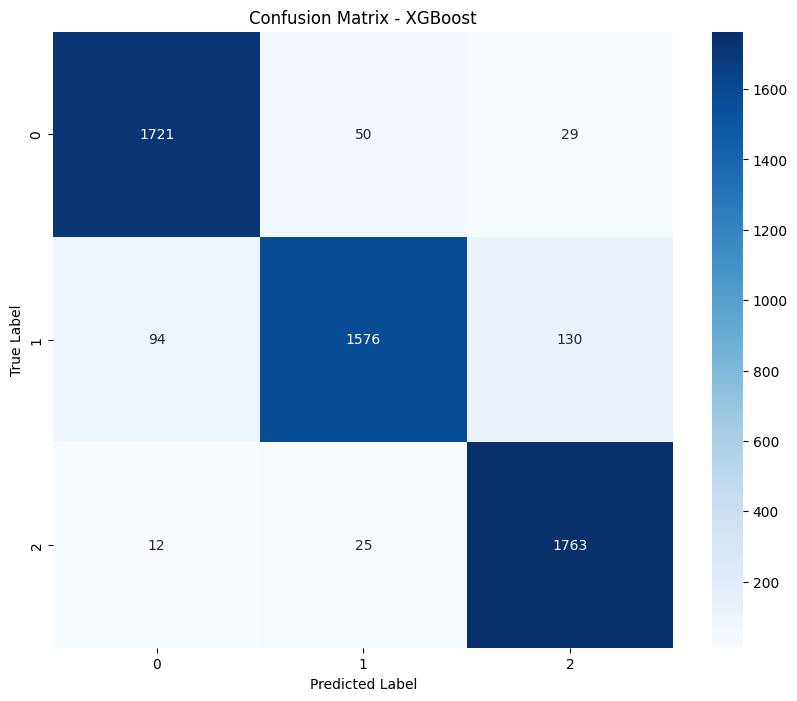


DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      1800
           1       0.95      0.88      0.91      1800
           2       0.92      0.98      0.95      1800

    accuracy                           0.94      5400
   macro avg       0.94      0.94      0.94      5400
weighted avg       0.94      0.94      0.94      5400


ERROR ANALYSIS DATAFRAME (First 10 errors)
Total misclassified instances: 340/5400 (6.30%)

First 10 misclassified examples:
       True_Label  Predicted_Label  Correct  True_Class_Probability  \
1779            1                2    False                0.052055   
1905            1                2    False                0.161638   
734             1                2    False                0.148505   
2332            1                2    False                0.110731   
10301           0                2    False                0.069897   
788             1                0 

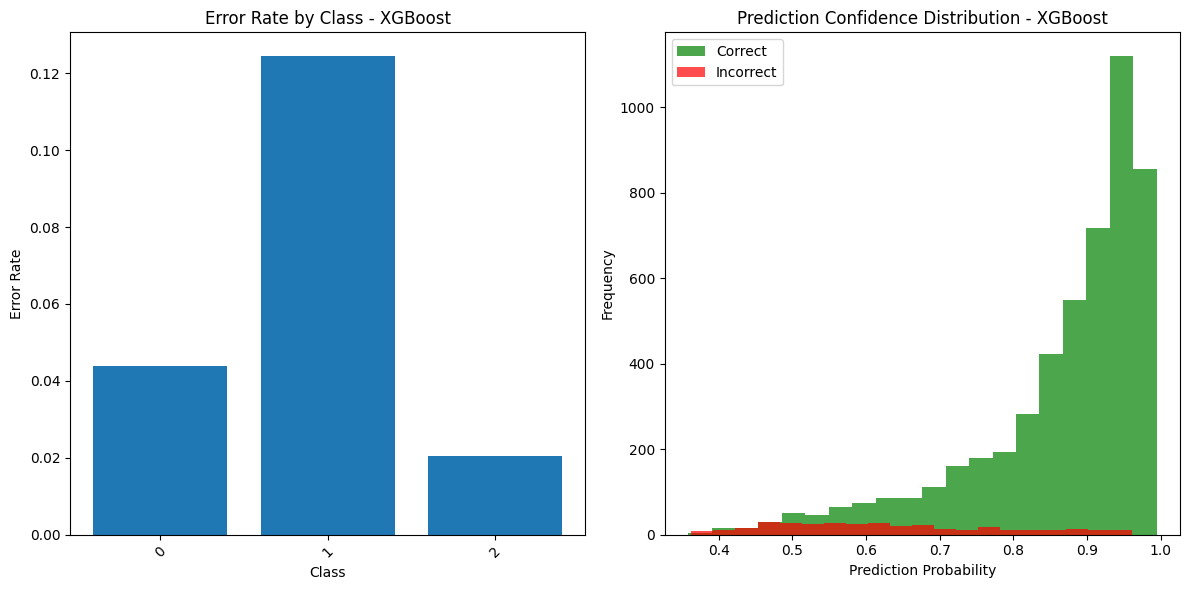


XGBOOST-SPECIFIC ANALYSIS
Number of trees: 100
Number of classes: 3

FEATURE IMPORTANCE ANALYSIS (XGBoost)
Average feature importance by feature group:
Numerical: 0.0019
BERT: 0.0008
TF-IDF: 0.0001
N-grams: 0.0000


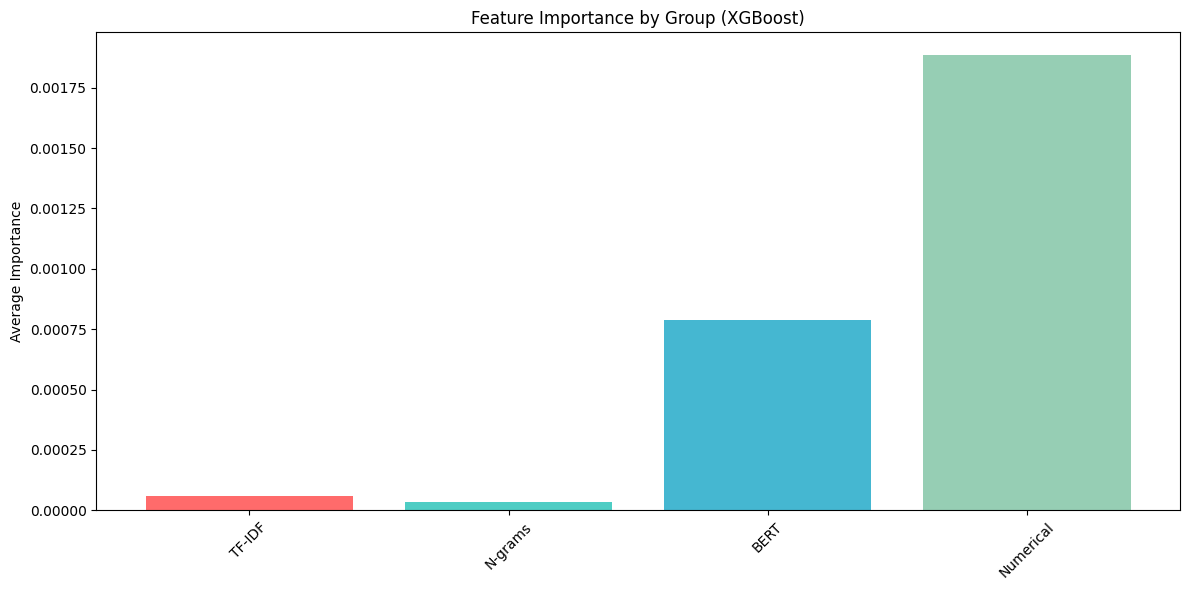


Top 20 Most Important Features:
    Feature_Index  Importance
0             528    0.014669
1            7770    0.012434
2            2071    0.012098
3            2069    0.011587
4            1555    0.011122
5             529    0.009324
6            3454    0.008982
7            3046    0.008024
8            7432    0.006416
9            3048    0.005883
10           6596    0.005875
11           4825    0.005744
12           7779    0.005467
13           7426    0.005393
14           7122    0.005052
15           1553    0.004756
16            521    0.004481
17           7212    0.004284
18           4501    0.004280
19            798    0.004224


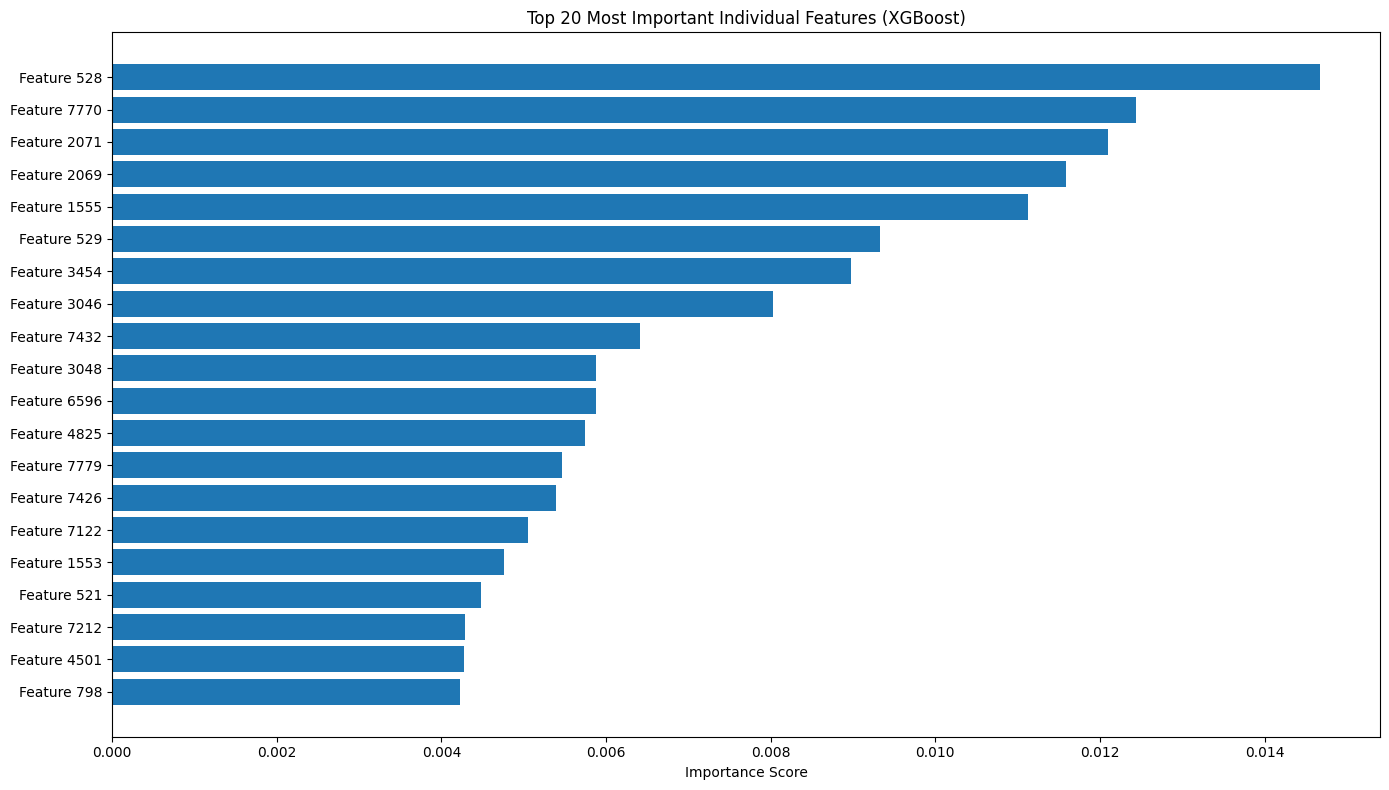


MISCLASSIFICATION CONFIDENCE ANALYSIS
High-confidence errors (confidence > 0.7): 105

High-confidence error patterns:
   True_Label  Predicted_Label  Count
2           1                0     39
3           1                2     38
0           0                1     19
4           2                1      6
1           0                2      3

Low-confidence correct predictions (confidence < 0.6): 265

PREDICTION MARGIN ANALYSIS
Average prediction margin for correct predictions: 0.7674
Average prediction margin for incorrect predictions: 0.3654


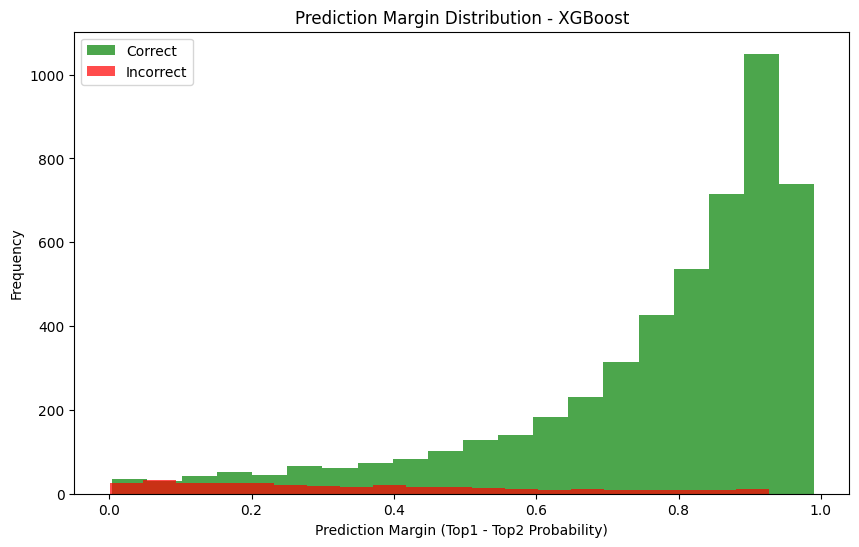

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=xgb_model.classes_,
            yticklabels=xgb_model.classes_)
plt.title('Confusion Matrix - XGBoost')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Classification Report
print("\nDETAILED CLASSIFICATION REPORT")
print(classification_report(y_test, y_test_pred, target_names=[str(cls) for cls in xgb_model.classes_]))

# Error Analysis DataFrame
error_analysis = pd.DataFrame({
    'True_Label': y_test,
    'Predicted_Label': y_test_pred,
    'Correct': y_test == y_test_pred
})

# Add probabilities for the true and predicted classes
error_analysis['True_Class_Probability'] = [y_test_proba[i, np.where(xgb_model.classes_ == true_label)[0][0]]
                                           for i, true_label in enumerate(y_test)]
error_analysis['Predicted_Class_Probability'] = [y_test_proba[i, np.where(xgb_model.classes_ == pred_label)[0][0]]
                                                for i, pred_label in enumerate(y_test_pred)]

print("\nERROR ANALYSIS DATAFRAME (First 10 errors)")
# Show misclassified examples
misclassified = error_analysis[~error_analysis['Correct']]
print(f"Total misclassified instances: {len(misclassified)}/{len(y_test)} ({len(misclassified)/len(y_test)*100:.2f}%)")
print("\nFirst 10 misclassified examples:")
print(misclassified.head(10))

# Most common error patterns
print("\nMOST COMMON ERROR PATTERNS")
error_patterns = misclassified.groupby(['True_Label', 'Predicted_Label']).size().reset_index(name='Count')
error_patterns = error_patterns.sort_values('Count', ascending=False)
print(error_patterns.head(10))

# Class-wise performance analysis
print("\nCLASS-WISE PERFORMANCE ANALYSIS")
class_performance = pd.DataFrame({
    'Class': xgb_model.classes_,
    'Total_Instances': [np.sum(y_test == cls) for cls in xgb_model.classes_],
    'Correct_Predictions': [np.sum((y_test == cls) & (y_test_pred == cls)) for cls in xgb_model.classes_],
    'Error_Rate': [np.sum((y_test == cls) & (y_test_pred != cls)) / np.sum(y_test == cls)
                   if np.sum(y_test == cls) > 0 else 0 for cls in xgb_model.classes_]
})

class_performance['Accuracy'] = class_performance['Correct_Predictions'] / class_performance['Total_Instances']
print(class_performance)

# Probability distribution analysis for errors
print("\nPROBABILITY ANALYSIS FOR ERRORS")
print("Probability statistics for correct predictions:")
print(error_analysis[error_analysis['Correct']]['Predicted_Class_Probability'].describe())

print("\nProbability statistics for incorrect predictions:")
print(error_analysis[~error_analysis['Correct']]['Predicted_Class_Probability'].describe())

# Visualize error patterns
plt.figure(figsize=(12, 6))

# Subplot 1: Error rate by class
plt.subplot(1, 2, 1)
plt.bar(range(len(class_performance)), class_performance['Error_Rate'])
plt.xticks(range(len(class_performance)), class_performance['Class'], rotation=45)
plt.title('Error Rate by Class - XGBoost')
plt.xlabel('Class')
plt.ylabel('Error Rate')

# Subplot 2: Confidence in predictions
plt.subplot(1, 2, 2)
plt.hist(error_analysis[error_analysis['Correct']]['Predicted_Class_Probability'],
         alpha=0.7, label='Correct', bins=20, color='green')
plt.hist(error_analysis[~error_analysis['Correct']]['Predicted_Class_Probability'],
         alpha=0.7, label='Incorrect', bins=20, color='red')
plt.title('Prediction Confidence Distribution - XGBoost')
plt.xlabel('Prediction Probability')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.show()

# ADDITIONAL XGBOOST-SPECIFIC ANALYSIS
print("\n" + "="*50)
print("XGBOOST-SPECIFIC ANALYSIS")
print("="*50)

# Tree statistics
print(f"Number of trees: {xgb_model.n_estimators}")
print(f"Number of classes: {len(xgb_model.classes_)}")

# Feature importance analysis
print("\n" + "="*50)
print("FEATURE IMPORTANCE ANALYSIS (XGBoost)")
print("="*50)

# Get feature importances from the trained model
feature_importances = xgb_model.feature_importances_

# Get average feature importance for each feature group
feature_importance_by_group = {}
for group_name, indices in feature_groups.items():
    if len(indices) > 0:
        group_importance = np.mean(feature_importances[indices])
        feature_importance_by_group[group_name] = group_importance

print("Average feature importance by feature group:")
for group, importance in sorted(feature_importance_by_group.items(), key=lambda x: x[1], reverse=True):
    print(f"{group}: {importance:.4f}")

# Plot feature importances by group
plt.figure(figsize=(12, 6))
plt.bar(range(len(feature_importance_by_group)), list(feature_importance_by_group.values()),
        color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
plt.xticks(range(len(feature_importance_by_group)), list(feature_importance_by_group.keys()), rotation=45)
plt.title('Feature Importance by Group (XGBoost)')
plt.ylabel('Average Importance')
plt.tight_layout()
plt.show()

# Top individual features analysis
print("\nTop 20 Most Important Features:")
top_n = min(20, len(feature_importances))
top_indices = np.argsort(feature_importances)[-top_n:][::-1]
top_features = pd.DataFrame({
    'Feature_Index': top_indices,
    'Importance': feature_importances[top_indices]
})
print(top_features)

# Plot top individual features
plt.figure(figsize=(14, 8))
plt.barh(range(top_n), top_features['Importance'][::-1])
plt.yticks(range(top_n), [f'Feature {i}' for i in top_features['Feature_Index'][::-1]])
plt.title('Top 20 Most Important Individual Features (XGBoost)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# MISCLASSIFICATION CONFIDENCE ANALYSIS
print("\n" + "="*50)
print("MISCLASSIFICATION CONFIDENCE ANALYSIS")
print("="*50)

# Analyze cases where model was wrong but confident
high_confidence_errors = misclassified[misclassified['Predicted_Class_Probability'] > 0.7]
print(f"High-confidence errors (confidence > 0.7): {len(high_confidence_errors)}")
if len(high_confidence_errors) > 0:
    print("\nHigh-confidence error patterns:")
    hc_patterns = high_confidence_errors.groupby(['True_Label', 'Predicted_Label']).size().reset_index(name='Count')
    print(hc_patterns.sort_values('Count', ascending=False))

# Analyze cases where model was right but unconfident
low_confidence_correct = error_analysis[
    (error_analysis['Correct']) &
    (error_analysis['Predicted_Class_Probability'] < 0.6)
]
print(f"\nLow-confidence correct predictions (confidence < 0.6): {len(low_confidence_correct)}")

# PREDICTION MARGIN ANALYSIS
print("\n" + "="*50)
print("PREDICTION MARGIN ANALYSIS")
print("="*50)

# Calculate prediction margins (difference between top and second probability)
prediction_margins = []
for i in range(len(y_test_proba)):
    sorted_probs = np.sort(y_test_proba[i])[::-1]
    margin = sorted_probs[0] - sorted_probs[1] if len(sorted_probs) > 1 else sorted_probs[0]
    prediction_margins.append(margin)

error_analysis['Prediction_Margin'] = prediction_margins

print("Average prediction margin for correct predictions: "
      f"{error_analysis[error_analysis['Correct']]['Prediction_Margin'].mean():.4f}")
print("Average prediction margin for incorrect predictions: "
      f"{error_analysis[~error_analysis['Correct']]['Prediction_Margin'].mean():.4f}")

# Plot margin distribution
plt.figure(figsize=(10, 6))
plt.hist(error_analysis[error_analysis['Correct']]['Prediction_Margin'],
         alpha=0.7, label='Correct', bins=20, color='green')
plt.hist(error_analysis[~error_analysis['Correct']]['Prediction_Margin'],
         alpha=0.7, label='Incorrect', bins=20, color='red')
plt.title('Prediction Margin Distribution - XGBoost')
plt.xlabel('Prediction Margin (Top1 - Top2 Probability)')
plt.ylabel('Frequency')
plt.legend()
plt.show()


# Bi-LSTM

Model Training


Reshaped training data: (21600, 1, 7787)
Reshaped testing data: (5400, 1, 7787)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 1, 256)         │     8,105,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,280,771 (31.59 MB)

 Trainable params: 8,280,771 (31.59 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
540/540 ━━━━━━━━━━━━━━━━━━━━ 21s 19ms/step - accuracy: 0.7204 - loss: 0.6300 - val_accuracy: 0.9303 - val_loss: 0.1983 - learning_rate: 0.0010
Epoch 2/50
540/540 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.9715 - loss: 0.0886 - val_accuracy: 0.9463 - val_loss: 0.1847 - learning_rate: 0.0010
Epoch 3/50
540/540 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.9876 - loss: 0.0398 - val_accuracy: 0.9442 - val_loss: 0.2405 - learning_rate: 0.0010
Epoch 4/50
540/540 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.9902 - loss: 0.0341 - val_accuracy: 0.9438 - val_loss: 0.2484 - learning_rate: 0.0010
Epoch 5/50
540/540 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.9903 - loss: 0.0321 - val_accuracy: 0.9486 - val_loss: 0.2611 - learning_rate: 0.0010
Epoch 6/50
540/540 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.9928 - loss: 0.0238 - val_accuracy: 0.9481 - val_loss: 0.2408 - learning_rate: 0.0010
Epoch 7/50
540/540 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9924 - loss: 0

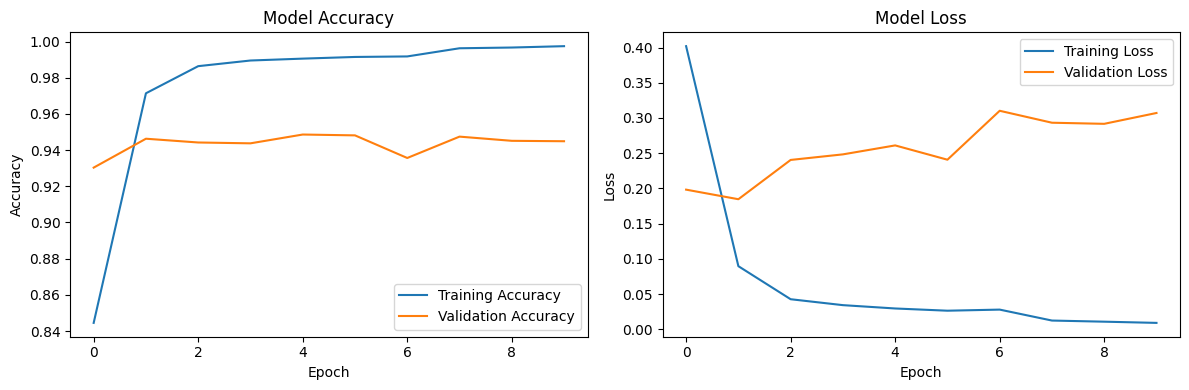

675/675 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step

TRAINING SET PERFORMANCE
Training Accuracy: 0.9842
Training Precision: 0.9842
Training Recall: 0.9842
Training F1-score: 0.9841


In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Bidirectional, LSTM, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Encode labels for neural network
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Convert to categorical for multi-class classification
num_classes = len(np.unique(y_train_encoded))
y_train_categorical = to_categorical(y_train_encoded, num_classes=num_classes)
y_test_categorical = to_categorical(y_test_encoded, num_classes=num_classes)

# Reshape data for LSTM (samples, timesteps, features)
# Since we don't have sequential data, we'll treat each feature as a timestep
X_train_reshaped = X_train_scaled.reshape(X_train_scaled.shape[0], 1, X_train_scaled.shape[1])
X_test_reshaped = X_test_scaled.reshape(X_test_scaled.shape[0], 1, X_test_scaled.shape[1])

print(f"\nReshaped training data: {X_train_reshaped.shape}")
print(f"Reshaped testing data: {X_test_reshaped.shape}")

# Build Bi-LSTM model
def build_bilstm_model(input_shape, num_classes):
    model = Sequential([
        Input(shape=input_shape),
        Bidirectional(LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.2)),
        Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.2)),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Initialize the Bi-LSTM model
bilstm_model = build_bilstm_model((X_train_reshaped.shape[1], X_train_reshaped.shape[2]), num_classes)

bilstm_model.summary()

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6, verbose=1)


history = bilstm_model.fit(
    X_train_reshaped, y_train_categorical,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

# Predict on the training set
y_train_pred_proba = bilstm_model.predict(X_train_reshaped)
y_train_pred = np.argmax(y_train_pred_proba, axis=1)
y_train_true = np.argmax(y_train_categorical, axis=1)

# Calculate metrics on the training set
accuracy_train = accuracy_score(y_train_true, y_train_pred)
precision_train = precision_score(y_train_true, y_train_pred, average='weighted')
recall_train = recall_score(y_train_true, y_train_pred, average='weighted')
f1_train = f1_score(y_train_true, y_train_pred, average='weighted')

print("\n" + "="*50)
print("TRAINING SET PERFORMANCE")
print("="*50)
print(f"Training Accuracy: {accuracy_train:.4f}")
print(f"Training Precision: {precision_train:.4f}")
print(f"Training Recall: {recall_train:.4f}")
print(f"Training F1-score: {f1_train:.4f}")

Model Testing

In [ ]:
# Predict on the test set
y_test_pred_proba = bilstm_model.predict(X_test_reshaped)
y_test_pred = np.argmax(y_test_pred_proba, axis=1)
y_test_true = np.argmax(y_test_categorical, axis=1)

# Calculate metrics on the test set
accuracy_test = accuracy_score(y_test_true, y_test_pred)
precision_test = precision_score(y_test_true, y_test_pred, average='weighted')
recall_test = recall_score(y_test_true, y_test_pred, average='weighted')
f1_test = f1_score(y_test_true, y_test_pred, average='weighted')

print(f"Test Accuracy: {accuracy_test:.4f}")
print(f"Test Precision: {precision_test:.4f}")
print(f"Test Recall: {recall_test:.4f}")
print(f"Test F1-score: {f1_test:.4f}")
# Calculate AUC score
if num_classes == 2:
    auc_score = roc_auc_score(y_test_true, y_test_pred_proba[:, 1])
else:
    auc_score = roc_auc_score(y_test_true, y_test_pred_proba, multi_class='ovr', average='weighted')

print(f"Test AUC Score: {auc_score:.4f}")

store_metrics('BiLSTM', accuracy_test, precision_test, recall_test, f1_test, auc_score)

169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step
Test Accuracy: 0.9381
Test Precision: 0.9388
Test Recall: 0.9381
Test F1-score: 0.9377
Test AUC Score: 0.9888
✓ Metrics stored for BiLSTM


Error Analysis, Confusion Matrix, Classification Report, Feature Importance


ERROR ANALYSIS


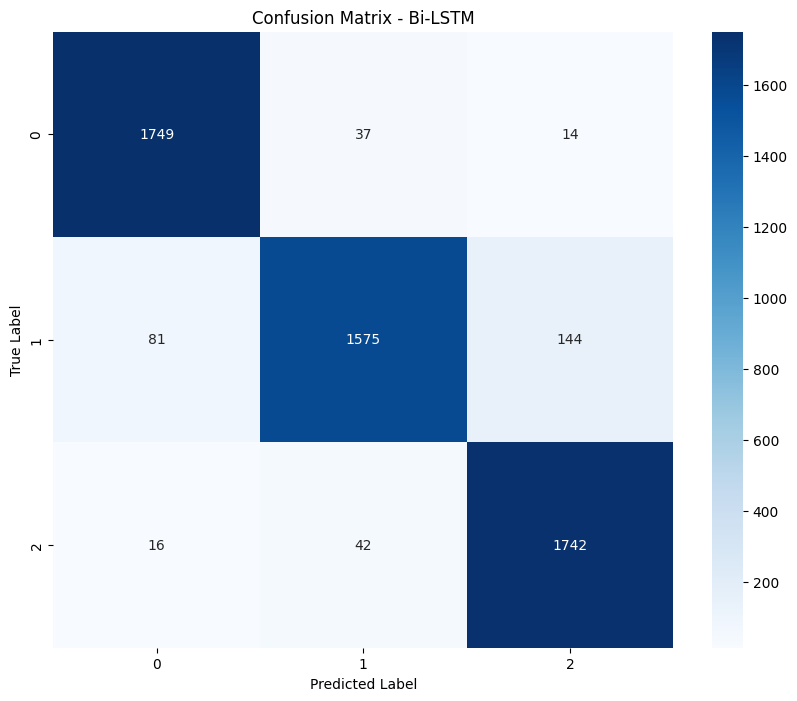


DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1800
           1       0.95      0.88      0.91      1800
           2       0.92      0.97      0.94      1800

    accuracy                           0.94      5400
   macro avg       0.94      0.94      0.94      5400
weighted avg       0.94      0.94      0.94      5400


ERROR ANALYSIS DATAFRAME (First 10 errors)
Total misclassified instances: 334/5400 (6.19%)

First 10 misclassified examples:
     True_Label  Predicted_Label  Correct  True_Class_Probability  \
1             1                2    False                0.034405   
43            1                0    False                0.161391   
60            1                2    False                0.343028   
67            1                2    False                0.003611   
74            0                2    False                0.000021   
90            1                0    False      

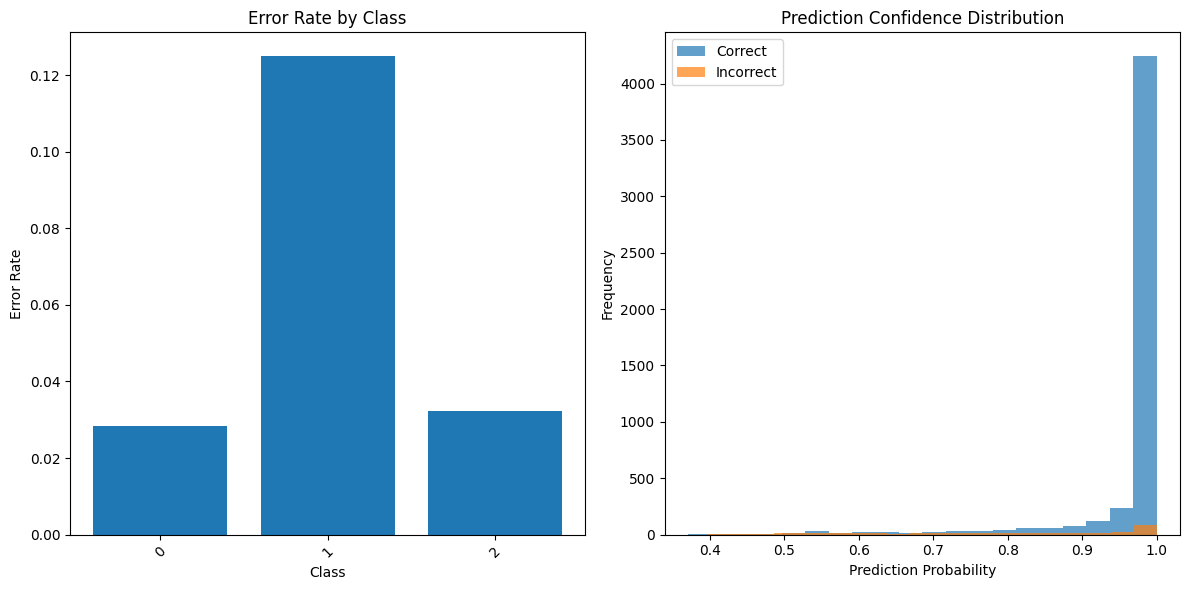

In [ ]:
# ERROR ANALYSIS
print("\n" + "="*50)
print("ERROR ANALYSIS")
print("="*50)

# Confusion Matrix
cm = confusion_matrix(y_test_true, y_test_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - Bi-LSTM')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Classification Report
print("\nDETAILED CLASSIFICATION REPORT")
print(classification_report(y_test_true, y_test_pred, target_names=[str(cls) for cls in label_encoder.classes_]))

# Error Analysis DataFrame
error_analysis = pd.DataFrame({
    'True_Label': y_test_true,
    'Predicted_Label': y_test_pred,
    'Correct': y_test_true == y_test_pred
})

# Add probabilities for the true and predicted classes
error_analysis['True_Class_Probability'] = [y_test_pred_proba[i, true_label] for i, true_label in enumerate(y_test_true)]
error_analysis['Predicted_Class_Probability'] = [y_test_pred_proba[i, pred_label] for i, pred_label in enumerate(y_test_pred)]

print("\nERROR ANALYSIS DATAFRAME (First 10 errors)")
# Show misclassified examples
misclassified = error_analysis[~error_analysis['Correct']]
print(f"Total misclassified instances: {len(misclassified)}/{len(y_test_true)} ({len(misclassified)/len(y_test_true)*100:.2f}%)")
print("\nFirst 10 misclassified examples:")
print(misclassified.head(10))

# Most common error patterns
print("\nMOST COMMON ERROR PATTERNS")
error_patterns = misclassified.groupby(['True_Label', 'Predicted_Label']).size().reset_index(name='Count')
error_patterns = error_patterns.sort_values('Count', ascending=False)
print(error_patterns.head(10))

# Class-wise performance analysis
print("\nCLASS-WISE PERFORMANCE ANALYSIS")
class_performance = pd.DataFrame({
    'Class': label_encoder.classes_,
    'Total_Instances': [np.sum(y_test_true == cls) for cls in range(num_classes)],
    'Correct_Predictions': [np.sum((y_test_true == cls) & (y_test_pred == cls)) for cls in range(num_classes)],
    'Error_Rate': [np.sum((y_test_true == cls) & (y_test_pred != cls)) / np.sum(y_test_true == cls)
                   if np.sum(y_test_true == cls) > 0 else 0 for cls in range(num_classes)]
})

class_performance['Accuracy'] = class_performance['Correct_Predictions'] / class_performance['Total_Instances']
print(class_performance)

# Probability distribution analysis for errors
print("\nPROBABILITY ANALYSIS FOR ERRORS")
print("Probability statistics for correct predictions:")
print(error_analysis[error_analysis['Correct']]['Predicted_Class_Probability'].describe())

print("\nProbability statistics for incorrect predictions:")
print(error_analysis[~error_analysis['Correct']]['Predicted_Class_Probability'].describe())

# Visualize error patterns
plt.figure(figsize=(12, 6))

# Subplot 1: Error rate by class
plt.subplot(1, 2, 1)
plt.bar(range(len(class_performance)), class_performance['Error_Rate'])
plt.xticks(range(len(class_performance)), class_performance['Class'], rotation=45)
plt.title('Error Rate by Class')
plt.xlabel('Class')
plt.ylabel('Error Rate')

# Subplot 2: Confidence in predictions
plt.subplot(1, 2, 2)
plt.hist(error_analysis[error_analysis['Correct']]['Predicted_Class_Probability'],
         alpha=0.7, label='Correct', bins=20)
plt.hist(error_analysis[~error_analysis['Correct']]['Predicted_Class_Probability'],
         alpha=0.7, label='Incorrect', bins=20)
plt.title('Prediction Confidence Distribution')
plt.xlabel('Prediction Probability')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.show()

# DistilBIRT

In [ ]:
pip install transformers --upgrade

Model Training

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Class distribution before SMOTE:
class
1    9000
2    4159
0    2858
Name: count, dtype: int64
Dataset size after SMOTE: 27000
Class distribution after SMOTE:
class
1    9380
2    9102
0    8518
Name: count, dtype: int64

Training DistilBERT...


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: nawroz-haseen-tumul (nawroz-haseen-tumul-brac-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.245300,0.199065,0.943519,0.944478,0.943519,0.943466
2,0.066100,0.179029,0.962778,0.962829,0.962778,0.962733
3,0.042700,0.179239,0.967593,0.967645,0.967593,0.967553


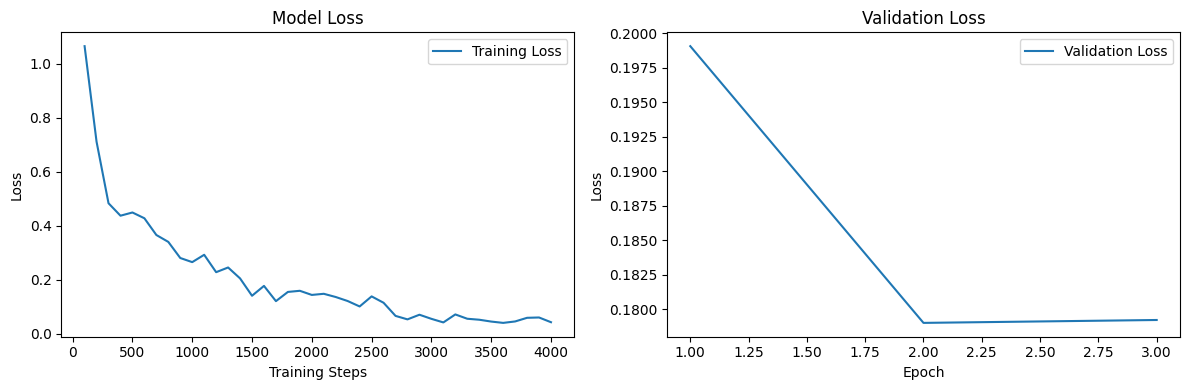


TRAINING SET PERFORMANCE
Training Accuracy: 0.9890
Training Precision: 0.9890
Training Recall: 0.9890
Training F1-score: 0.9890


In [ ]:
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.neighbors import NearestNeighbors
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from transformers import Trainer, TrainingArguments
import torch
from torch.utils.data import Dataset
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

#separate dataset for bert
class TweetDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
bert_model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=3
)

#SMOTE on raw text and labels
print("Class distribution before SMOTE:")
print(balanced_data['class'].value_counts())

count_vectorizer = CountVectorizer(max_features=1000)
X_initial_clean = count_vectorizer.fit_transform(balanced_data['cleaned_tweet'])
y_initial_clean = balanced_data['class']
smote = SMOTE(random_state=42, k_neighbors=1)
X_smote_clean, y_smote_clean = smote.fit_resample(X_initial_clean, y_initial_clean)

#synthetic samples remapped
nn = NearestNeighbors(n_neighbors=1, metric='cosine')
nn.fit(X_initial_clean)
_, indices = nn.kneighbors(X_smote_clean)
balanced_data_smote = balanced_data.iloc[indices.flatten()].copy()
balanced_data_smote['class'] = y_smote_clean

print(f"Dataset size after SMOTE: {len(balanced_data_smote)}")
print("Class distribution after SMOTE:")
print(balanced_data_smote['class'].value_counts())

X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    balanced_data_smote['cleaned_tweet'], balanced_data_smote['class'],
    test_size=0.2, stratify=balanced_data_smote['class'], random_state=42
)

label_encoder = LabelEncoder()
y_train_clean_encoded = label_encoder.fit_transform(y_train_clean)
y_test_clean_encoded = label_encoder.transform(y_test_clean)

train_dataset = TweetDataset(X_train_clean.values, y_train_clean_encoded, tokenizer)
test_dataset = TweetDataset(X_test_clean.values, y_test_clean_encoded, tokenizer)

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=100,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss'
)


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    accuracy = accuracy_score(labels, predictions)
    precision = precision_score(labels, predictions, average='weighted')
    recall = recall_score(labels, predictions, average='weighted')
    f1 = f1_score(labels, predictions, average='weighted')
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

print("\nTraining DistilBERT...")
trainer.train()

train_logs = trainer.state.log_history
train_loss = [log['loss'] for log in train_logs if 'loss' in log]
val_loss = [log['eval_loss'] for log in train_logs if 'eval_loss' in log]
train_steps = [log['step'] for log in train_logs if 'loss' in log]
val_epochs = [log['epoch'] for log in train_logs if 'eval_loss' in log]

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_steps, train_loss, label='Training Loss')
plt.title('Model Loss')
plt.xlabel('Training Steps')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(val_epochs, val_loss, label='Validation Loss')
plt.title('Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

train_predictions = trainer.predict(train_dataset)
y_train_clean_pred = np.argmax(train_predictions.predictions, axis=1)
y_train_clean_true = y_train_clean_encoded

accuracy_train_clean = accuracy_score(y_train_clean_true, y_train_clean_pred)
precision_train = precision_score(y_train_clean_true, y_train_clean_pred, average='weighted')
recall_train = recall_score(y_train_clean_true, y_train_clean_pred, average='weighted')
f1_train = f1_score(y_train_clean_true, y_train_clean_pred, average='weighted')

print("\n" + "="*50)
print("TRAINING SET PERFORMANCE")
print("="*50)
print(f"Training Accuracy: {accuracy_train_clean:.4f}")
print(f"Training Precision: {precision_train:.4f}")
print(f"Training Recall: {recall_train:.4f}")
print(f"Training F1-score: {f1_train:.4f}")

Model Testing

In [ ]:
test_predictions = trainer.predict(test_dataset)
y_test_clean_pred = np.argmax(test_predictions.predictions, axis=1)
y_test_clean_true = y_test_clean_encoded

accuracy_test = accuracy_score(y_test_clean_true, y_test_clean_pred)
precision_test = precision_score(y_test_clean_true, y_test_clean_pred, average='weighted')
recall_test = recall_score(y_test_clean_true, y_test_clean_pred, average='weighted')
f1_test = f1_score(y_test_clean_true, y_test_clean_pred, average='weighted')

print(f"Test Accuracy: {accuracy_test:.4f}")
print(f"Test Precision: {precision_test:.4f}")
print(f"Test Recall: {recall_test:.4f}")
print(f"Test F1-score: {f1_test:.4f}")

y_test_clean_proba = torch.softmax(torch.tensor(test_predictions.predictions), dim=1).numpy()
if num_classes == 2:
    auc_score = roc_auc_score(y_test_clean_true, y_test_clean_proba[:, 1])
else:
    auc_score = roc_auc_score(y_test_clean_true, y_test_clean_proba, multi_class='ovr', average='weighted')

print(f"Test AUC Score: {auc_score:.4f}")

store_metrics('DistilBERT', accuracy_test, precision_test, recall_test, f1_test, auc_score)

Test Accuracy: 0.9628
Test Precision: 0.9628
Test Recall: 0.9628
Test F1-score: 0.9627
Test AUC Score: 0.9924
✓ Metrics stored for DistilBERT


Error Analysis, Confusion Matrix, Classification Report, Prediction Confidence


ERROR ANALYSIS


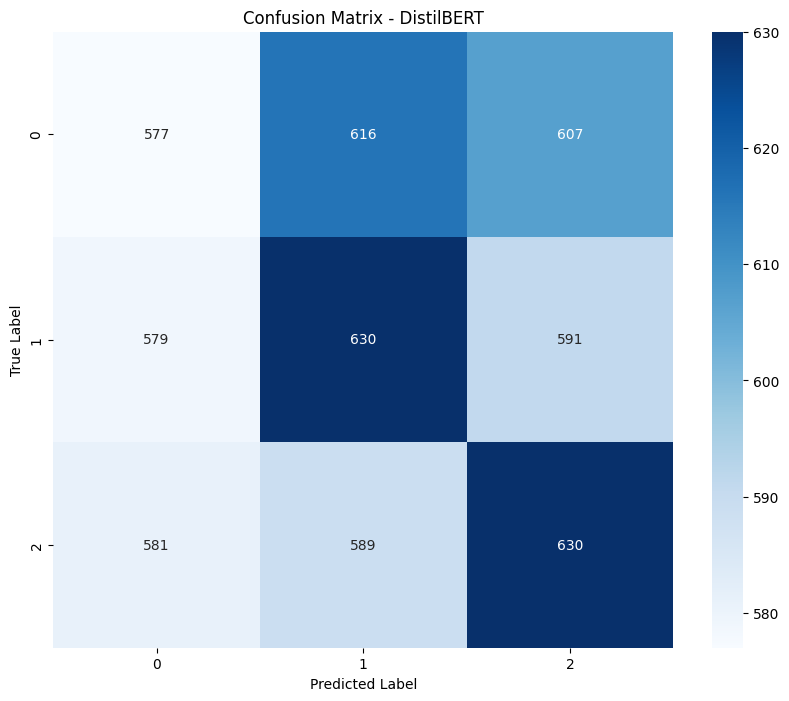


DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.33      0.32      0.33      1800
           1       0.34      0.35      0.35      1800
           2       0.34      0.35      0.35      1800

    accuracy                           0.34      5400
   macro avg       0.34      0.34      0.34      5400
weighted avg       0.34      0.34      0.34      5400


ERROR ANALYSIS DATAFRAME (First 10 errors)
Total misclassified instances: 3563/5400 (65.98%)

First 10 misclassified examples:
    True_Label  Predicted_Label  Correct  True_Class_Probability  \
0            0                1    False                0.002160   
3            0                2    False                0.000108   
4            1                2    False                0.000889   
6            0                2    False                0.000131   
8            1                2    False                0.000371   
10           2                1    False           

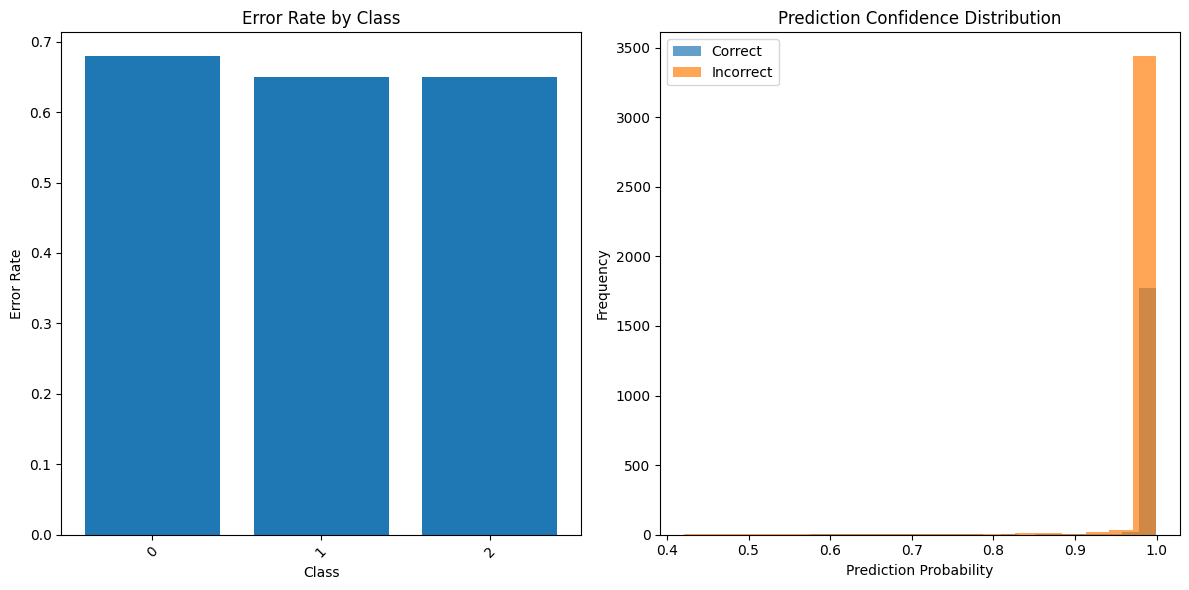

In [ ]:
# ERROR ANALYSIS
print("\n" + "="*50)
print("ERROR ANALYSIS")
print("="*50)

# Confusion Matrix
cm = confusion_matrix(y_test_true, y_test_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - DistilBERT')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Classification Report
print("\nDETAILED CLASSIFICATION REPORT")
print(classification_report(y_test_true, y_test_pred, target_names=[str(cls) for cls in label_encoder.classes_]))

# Error Analysis DataFrame
error_analysis = pd.DataFrame({
    'True_Label': y_test_true,
    'Predicted_Label': y_test_pred,
    'Correct': y_test_true == y_test_pred
})

# Add probabilities for the true and predicted classes
error_analysis['True_Class_Probability'] = [y_test_proba[i, true_label] for i, true_label in enumerate(y_test_true)]
error_analysis['Predicted_Class_Probability'] = [y_test_proba[i, pred_label] for i, pred_label in enumerate(y_test_pred)]

print("\nERROR ANALYSIS DATAFRAME (First 10 errors)")
misclassified = error_analysis[~error_analysis['Correct']]
print(f"Total misclassified instances: {len(misclassified)}/{len(y_test)} ({len(misclassified)/len(y_test)*100:.2f}%)")
print("\nFirst 10 misclassified examples:")
print(misclassified.head(10))

# Most common error patterns
print("\nMOST COMMON ERROR PATTERNS")
error_patterns = misclassified.groupby(['True_Label', 'Predicted_Label']).size().reset_index(name='Count')
error_patterns = error_patterns.sort_values('Count', ascending=False)
print(error_patterns.head(10))

# Class-wise performance analysis
print("\nCLASS-WISE PERFORMANCE ANALYSIS")
class_performance = pd.DataFrame({
    'Class': label_encoder.classes_,
    'Total_Instances': [np.sum(y_test_true == cls) for cls in range(num_classes)],
    'Correct_Predictions': [np.sum((y_test_true == cls) & (y_test_pred == cls)) for cls in range(num_classes)],
    'Error_Rate': [np.sum((y_test_true == cls) & (y_test_pred != cls)) / np.sum(y_test_true == cls)
                   if np.sum(y_test_true == cls) > 0 else 0 for cls in range(num_classes)]
})

class_performance['Accuracy'] = class_performance['Correct_Predictions'] / class_performance['Total_Instances']
print(class_performance)

# Probability distribution analysis for errors
print("\nPROBABILITY ANALYSIS FOR ERRORS")
print("Probability statistics for correct predictions:")
print(error_analysis[error_analysis['Correct']]['Predicted_Class_Probability'].describe())

print("\nProbability statistics for incorrect predictions:")
print(error_analysis[~error_analysis['Correct']]['Predicted_Class_Probability'].describe())

# Visualize error patterns
plt.figure(figsize=(12, 6))

# Subplot 1: Error rate by class
plt.subplot(1, 2, 1)
plt.bar(range(len(class_performance)), class_performance['Error_Rate'])
plt.xticks(range(len(class_performance)), class_performance['Class'], rotation=45)
plt.title('Error Rate by Class')
plt.xlabel('Class')
plt.ylabel('Error Rate')

# Subplot 2: Confidence in predictions
plt.subplot(1, 2, 2)
plt.hist(error_analysis[error_analysis['Correct']]['Predicted_Class_Probability'],
         alpha=0.7, label='Correct', bins=20)
plt.hist(error_analysis[~error_analysis['Correct']]['Predicted_Class_Probability'],
         alpha=0.7, label='Incorrect', bins=20)
plt.title('Prediction Confidence Distribution')
plt.xlabel('Prediction Probability')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.show()

# Hybrid Model: Bi-LSTM + XGBoost

Model training


Reshaped training data: (21600, 1, 7787)
Reshaped testing data: (5400, 1, 7787)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 1, 7787)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 1, 256)         │     8,105,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,280,771 (31.59 MB)

 Trainable params: 8,280,771 (31.59 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
540/540 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - accuracy: 0.7340 - loss: 0.6270 - val_accuracy: 0.9373 - val_loss: 0.1846 - learning_rate: 0.0010
Epoch 2/50
540/540 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.9669 - loss: 0.1038 - val_accuracy: 0.9424 - val_loss: 0.1976 - learning_rate: 0.0010
Epoch 3/50
540/540 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.9861 - loss: 0.0456 - val_accuracy: 0.9528 - val_loss: 0.2132 - learning_rate: 0.0010
Epoch 4/50
540/540 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.9887 - loss: 0.0330 - val_accuracy: 0.9356 - val_loss: 0.2726 - learning_rate: 0.0010
Epoch 5/50
540/540 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.9893 - loss: 0.0307 - val_accuracy: 0.9438 - val_loss: 0.2616 - learning_rate: 0.0010
Epoch 6/50
540/540 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9904 - loss: 0.0280
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
540/540 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.9904 - loss: 0

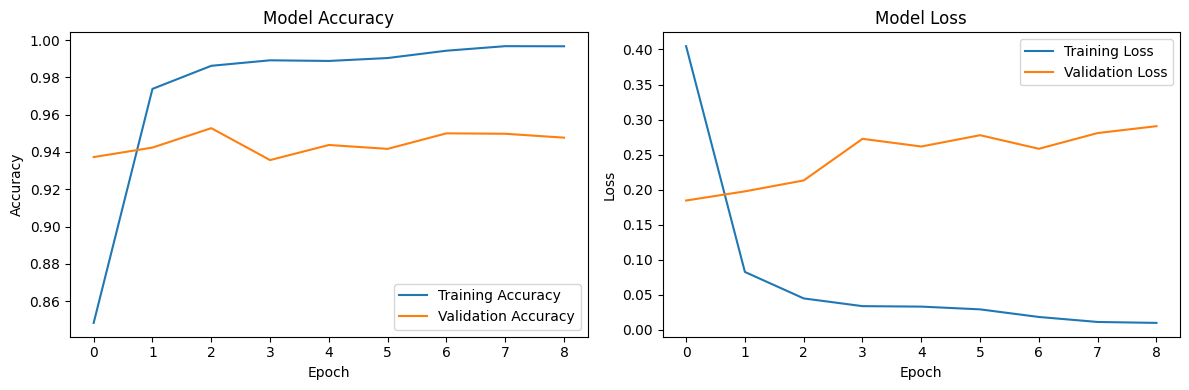

675/675 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step
169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step

Hybrid training data shape: (21600, 7819)
Hybrid testing data shape: (5400, 7819)

TRAINING SET PERFORMANCE
Training Accuracy: 0.9996
Training Precision: 0.9996
Training Recall: 0.9996
Training F1-score: 0.9996


In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Bidirectional, LSTM, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import Model
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Encode labels for neural network
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Convert to categorical for multi-class classification
num_classes = len(np.unique(y_train_encoded))
y_train_categorical = to_categorical(y_train_encoded, num_classes=num_classes)
y_test_categorical = to_categorical(y_test_encoded, num_classes=num_classes)

# Reshape data for LSTM (samples, timesteps, features)
X_train_reshaped = X_train_scaled.reshape(X_train_scaled.shape[0], 1, X_train_scaled.shape[1])
X_test_reshaped = X_test_scaled.reshape(X_test_scaled.shape[0], 1, X_test_scaled.shape[1])

print(f"\nReshaped training data: {X_train_reshaped.shape}")
print(f"Reshaped testing data: {X_test_reshaped.shape}")

# Build Bi-LSTM model for feature extraction
def build_bilstm_feature_extractor(input_shape):
    input_layer = Input(shape=input_shape)
    x = Bidirectional(LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.2))(input_layer)
    x = Bidirectional(LSTM(64, return_sequences=False, dropout=0.2, recurrent_dropout=0.2))(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    x = Dense(32, activation='relu')(x)
    x = Dropout(0.2)(x)
    output = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=input_layer, outputs=output)
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # Feature extractor from last hidden layer
    feature_extractor = Model(inputs=input_layer, outputs=model.layers[-3].output)  # Before last Dropout and Dense

    return model, feature_extractor

# Initialize Bi-LSTM model
bilstm_model, bilstm_extractor = build_bilstm_feature_extractor((X_train_reshaped.shape[1], X_train_reshaped.shape[2]))

bilstm_model.summary()

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6, verbose=1)

# Train Bi-LSTM
history = bilstm_model.fit(
    X_train_reshaped, y_train_categorical,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

# Extract features from Bi-LSTM
X_train_bilstm_features = bilstm_extractor.predict(X_train_reshaped)
X_test_bilstm_features = bilstm_extractor.predict(X_test_reshaped)

# Concatenate Bi-LSTM features with scaled numerical features
X_train_hybrid = np.hstack([X_train_bilstm_features, X_train_scaled])
X_test_hybrid = np.hstack([X_test_bilstm_features, X_test_scaled])

print(f"\nHybrid training data shape: {X_train_hybrid.shape}")
print(f"Hybrid testing data shape: {X_test_hybrid.shape}")

# Train XGBoost on hybrid features
xgb_model = XGBClassifier(
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    eval_metric='mlogloss',
    tree_method='hist'  # Faster on CPU
)

xgb_model.fit(X_train_hybrid, y_train_encoded)

# Predict on the training set
y_train_pred = xgb_model.predict(X_train_hybrid)

# Calculate metrics on the training set
accuracy_train = accuracy_score(y_train_encoded, y_train_pred)
precision_train = precision_score(y_train_encoded, y_train_pred, average='weighted')
recall_train = recall_score(y_train_encoded, y_train_pred, average='weighted')
f1_train = f1_score(y_train_encoded, y_train_pred, average='weighted')

print("\n" + "="*50)
print("TRAINING SET PERFORMANCE")
print("="*50)
print(f"Training Accuracy: {accuracy_train:.4f}")
print(f"Training Precision: {precision_train:.4f}")
print(f"Training Recall: {recall_train:.4f}")
print(f"Training F1-score: {f1_train:.4f}")



Model Testing

In [ ]:
# Predict on the test set
y_test_pred = xgb_model.predict(X_test_hybrid)

# Calculate metrics on the test set
accuracy_test = accuracy_score(y_test_encoded, y_test_pred)
precision_test = precision_score(y_test_encoded, y_test_pred, average='weighted')
recall_test = recall_score(y_test_encoded, y_test_pred, average='weighted')
f1_test = f1_score(y_test_encoded, y_test_pred, average='weighted')

print(f"Test Accuracy: {accuracy_test:.4f}")
print(f"Test Precision: {precision_test:.4f}")
print(f"Test Recall: {recall_test:.4f}")
print(f"Test F1-score: {f1_test:.4f}")

# Calculate AUC score
if num_classes == 2:
    auc_score = roc_auc_score(y_test_encoded, xgb_model.predict_proba(X_test_hybrid)[:, 1])
else:
    auc_score = roc_auc_score(y_test_encoded, xgb_model.predict_proba(X_test_hybrid), multi_class='ovr', average='weighted')

print(f"Test AUC Score: {auc_score:.4f}")

store_metrics('Hybrid BiLSTM-XGBoost', accuracy_test, precision_test, recall_test, f1_test, auc_score)


Test Accuracy: 0.9550
Test Precision: 0.9549
Test Recall: 0.9550
Test F1-score: 0.9549
Test AUC Score: 0.9919
✓ Metrics stored for Hybrid BiLSTM-XGBoost


Error Analysis, Confusion Matrix, Classification Report, Feature Importance


ERROR ANALYSIS


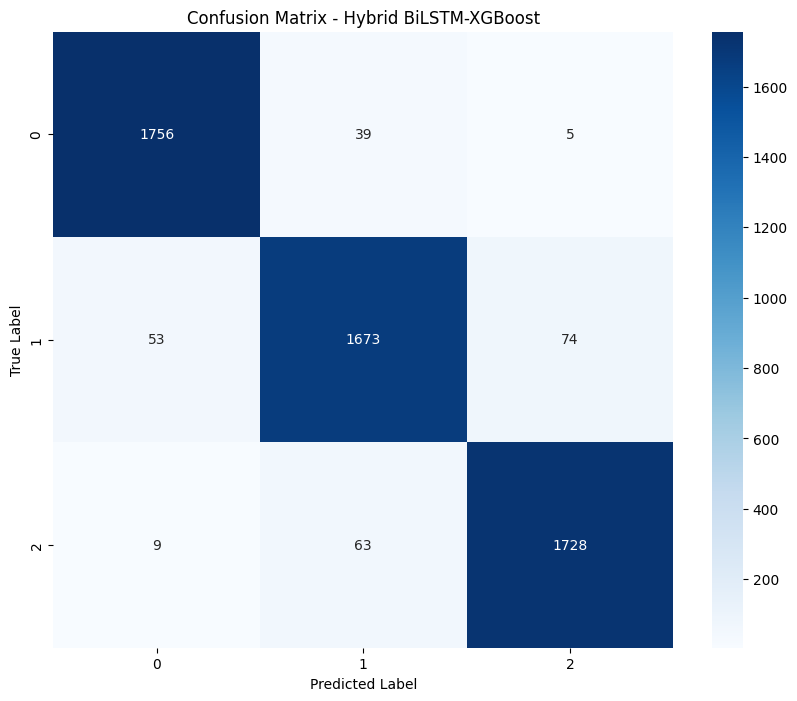


DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.97      0.98      0.97      1800
           1       0.94      0.93      0.94      1800
           2       0.96      0.96      0.96      1800

    accuracy                           0.95      5400
   macro avg       0.95      0.95      0.95      5400
weighted avg       0.95      0.95      0.95      5400


ERROR ANALYSIS DATAFRAME (First 10 errors)
Total misclassified instances: 243/5400 (4.50%)

First 10 misclassified examples:
     True_Label  Predicted_Label  Correct  True_Class_Probability  \
1             1                2    False                0.058368   
13            1                0    False                0.212088   
60            1                2    False                0.128504   
67            1                2    False                0.017824   
74            0                2    False                0.000286   
89            2                1    False      

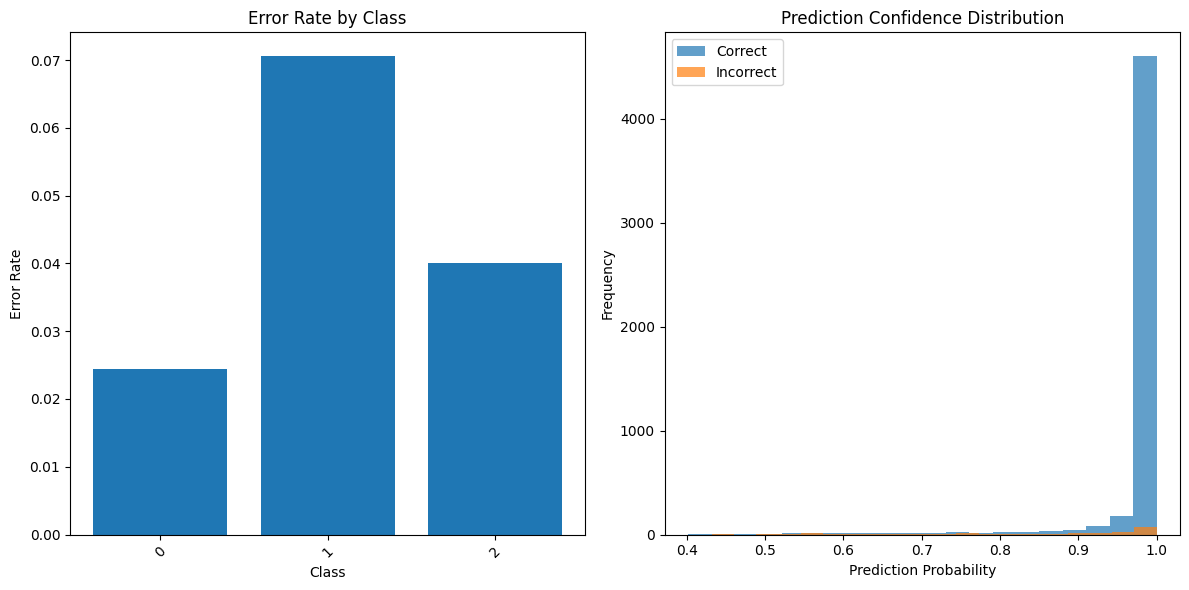


FEATURE IMPORTANCE ANALYSIS (XGBoost)
Average feature importance by feature group:
BERT: 0.0003
Numerical: 0.0003
TF-IDF: 0.0001
N-grams: 0.0000


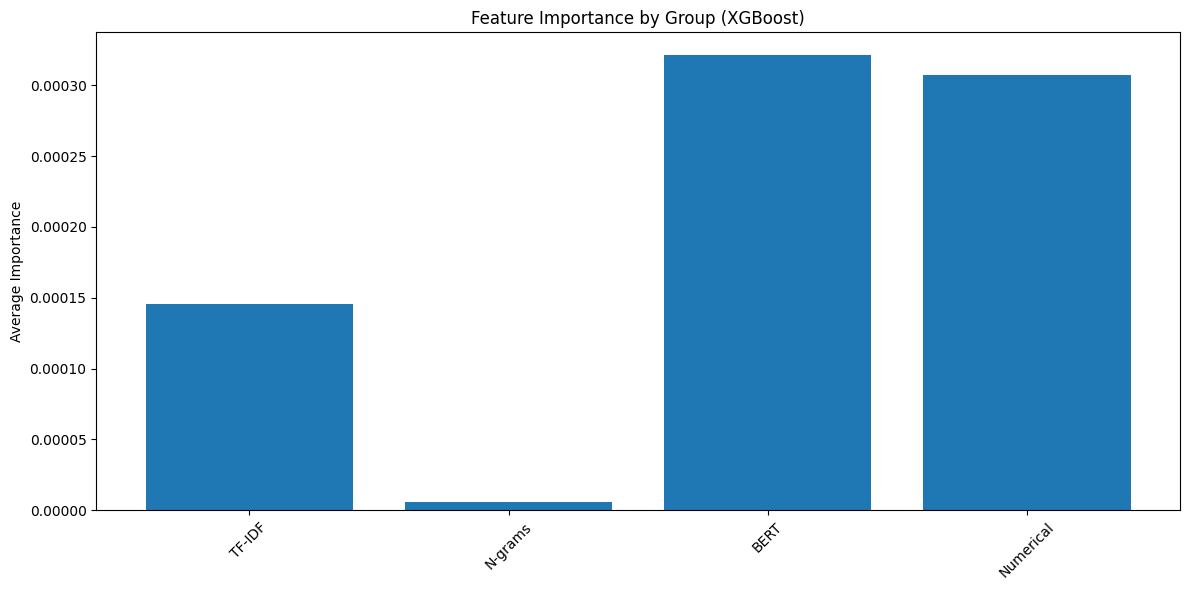

In [ ]:
# ERROR ANALYSIS (same as your Bi-LSTM and RF pipelines)
print("\n" + "="*50)
print("ERROR ANALYSIS")
print("="*50)

# Confusion Matrix
cm = confusion_matrix(y_test_encoded, y_test_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - Hybrid BiLSTM-XGBoost')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Classification Report
print("\nDETAILED CLASSIFICATION REPORT")
print(classification_report(y_test_encoded, y_test_pred, target_names=[str(cls) for cls in label_encoder.classes_]))

# Error Analysis DataFrame
error_analysis = pd.DataFrame({
    'True_Label': y_test_encoded,
    'Predicted_Label': y_test_pred,
    'Correct': y_test_encoded == y_test_pred
})

# Add probabilities for the true and predicted classes
y_test_proba = xgb_model.predict_proba(X_test_hybrid)
error_analysis['True_Class_Probability'] = [y_test_proba[i, true_label] for i, true_label in enumerate(y_test_encoded)]
error_analysis['Predicted_Class_Probability'] = [y_test_proba[i, pred_label] for i, pred_label in enumerate(y_test_pred)]

print("\nERROR ANALYSIS DATAFRAME (First 10 errors)")
misclassified = error_analysis[~error_analysis['Correct']]
print(f"Total misclassified instances: {len(misclassified)}/{len(y_test)} ({len(misclassified)/len(y_test)*100:.2f}%)")
print("\nFirst 10 misclassified examples:")
print(misclassified.head(10))

# Most common error patterns
print("\nMOST COMMON ERROR PATTERNS")
error_patterns = misclassified.groupby(['True_Label', 'Predicted_Label']).size().reset_index(name='Count')
error_patterns = error_patterns.sort_values('Count', ascending=False)
print(error_patterns.head(10))

# Class-wise performance analysis
print("\nCLASS-WISE PERFORMANCE ANALYSIS")
class_performance = pd.DataFrame({
    'Class': label_encoder.classes_,
    'Total_Instances': [np.sum(y_test_encoded == cls) for cls in range(num_classes)],
    'Correct_Predictions': [np.sum((y_test_encoded == cls) & (y_test_pred == cls)) for cls in range(num_classes)],
    'Error_Rate': [np.sum((y_test_encoded == cls) & (y_test_pred != cls)) / np.sum(y_test_encoded == cls)
                   if np.sum(y_test_encoded == cls) > 0 else 0 for cls in range(num_classes)]
})

class_performance['Accuracy'] = class_performance['Correct_Predictions'] / class_performance['Total_Instances']
print(class_performance)

# Probability distribution analysis for errors
print("\nPROBABILITY ANALYSIS FOR ERRORS")
print("Probability statistics for correct predictions:")
print(error_analysis[error_analysis['Correct']]['Predicted_Class_Probability'].describe())

print("\nProbability statistics for incorrect predictions:")
print(error_analysis[~error_analysis['Correct']]['Predicted_Class_Probability'].describe())

# Visualize error patterns
plt.figure(figsize=(12, 6))

# Subplot 1: Error rate by class
plt.subplot(1, 2, 1)
plt.bar(range(len(class_performance)), class_performance['Error_Rate'])
plt.xticks(range(len(class_performance)), class_performance['Class'], rotation=45)
plt.title('Error Rate by Class')
plt.xlabel('Class')
plt.ylabel('Error Rate')

# Subplot 2: Confidence in predictions
plt.subplot(1, 2, 2)
plt.hist(error_analysis[error_analysis['Correct']]['Predicted_Class_Probability'],
         alpha=0.7, label='Correct', bins=20)
plt.hist(error_analysis[~error_analysis['Correct']]['Predicted_Class_Probability'],
         alpha=0.7, label='Incorrect', bins=20)
plt.title('Prediction Confidence Distribution')
plt.xlabel('Prediction Probability')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.show()

# FEATURE IMPORTANCE ANALYSIS (Specific to XGBoost)
print("\n" + "="*50)
print("FEATURE IMPORTANCE ANALYSIS (XGBoost)")
print("="*50)

# Get feature importances from the trained model
feature_importances = xgb_model.feature_importances_

# Get average feature importance for each feature group
feature_importance_by_group = {}
for group_name, indices in feature_groups.items():
    if len(indices) > 0:
        group_importance = np.mean(feature_importances[indices])
        feature_importance_by_group[group_name] = group_importance

print("Average feature importance by feature group:")
for group, importance in sorted(feature_importance_by_group.items(), key=lambda x: x[1], reverse=True):
    print(f"{group}: {importance:.4f}")

# Plot feature importances
plt.figure(figsize=(12, 6))
plt.bar(range(len(feature_importance_by_group)), list(feature_importance_by_group.values()))
plt.xticks(range(len(feature_importance_by_group)), list(feature_importance_by_group.keys()), rotation=45)
plt.title('Feature Importance by Group (XGBoost)')
plt.ylabel('Average Importance')
plt.tight_layout()
plt.show()

# Hybrid Model - Bi-LSTM + Random Forest Classifier

Model Training


Reshaped training data: (21600, 1, 7787)
Reshaped testing data: (5400, 1, 7787)


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 1, 7787)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 1, 256)         │     8,105,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,280,771 (31.59 MB)

 Trainable params: 8,280,771 (31.59 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
540/540 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.7356 - loss: 0.6369 - val_accuracy: 0.9394 - val_loss: 0.1830 - learning_rate: 0.0010
Epoch 2/50
540/540 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.9672 - loss: 0.1011 - val_accuracy: 0.9502 - val_loss: 0.2020 - learning_rate: 0.0010
Epoch 3/50
540/540 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.9862 - loss: 0.0464 - val_accuracy: 0.9472 - val_loss: 0.2081 - learning_rate: 0.0010
Epoch 4/50
540/540 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.9885 - loss: 0.0376 - val_accuracy: 0.9421 - val_loss: 0.2539 - learning_rate: 0.0010
Epoch 5/50
540/540 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.9899 - loss: 0.0308 - val_accuracy: 0.9414 - val_loss: 0.2416 - learning_rate: 0.0010
Epoch 6/50
539/540 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9920 - loss: 0.0248
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
540/540 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.9920 - loss: 0

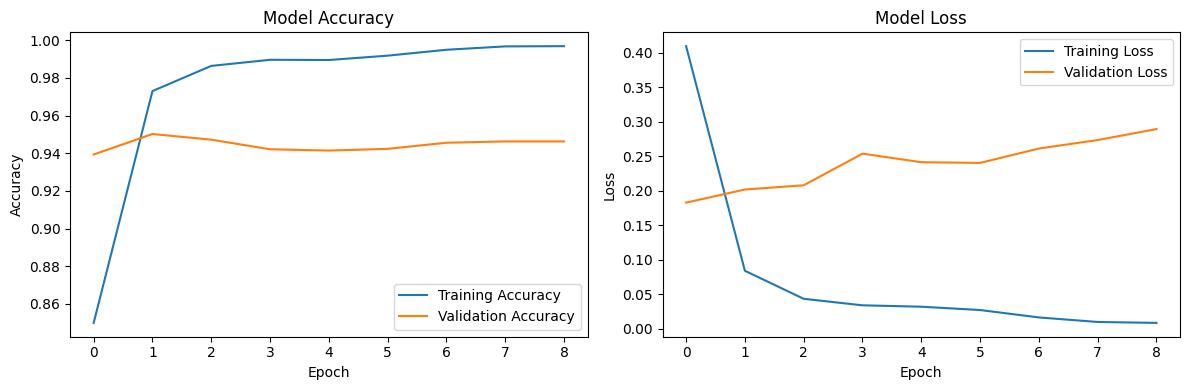

675/675 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step
169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step

Hybrid training data shape: (21600, 7819)
Hybrid testing data shape: (5400, 7819)

TRAINING SET PERFORMANCE
Training Accuracy: 0.9999
Training Precision: 0.9999
Training Recall: 0.9999
Training F1-score: 0.9999


In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Bidirectional, LSTM, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import Model
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Encode labels for neural network
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Convert to categorical for multi-class classification
num_classes = len(np.unique(y_train_encoded))
y_train_categorical = to_categorical(y_train_encoded, num_classes=num_classes)
y_test_categorical = to_categorical(y_test_encoded, num_classes=num_classes)

# Reshape data for LSTM (samples, timesteps, features)
X_train_reshaped = X_train_scaled.reshape(X_train_scaled.shape[0], 1, X_train_scaled.shape[1])
X_test_reshaped = X_test_scaled.reshape(X_test_scaled.shape[0], 1, X_test_scaled.shape[1])

print(f"\nReshaped training data: {X_train_reshaped.shape}")
print(f"Reshaped testing data: {X_test_reshaped.shape}")

# Build Bi-LSTM model for feature extraction
def build_bilstm_feature_extractor(input_shape):
    input_layer = Input(shape=input_shape)
    x = Bidirectional(LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.2))(input_layer)
    x = Bidirectional(LSTM(64, return_sequences=False, dropout=0.2, recurrent_dropout=0.2))(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    x = Dense(32, activation='relu')(x)
    x = Dropout(0.2)(x)
    output = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=input_layer, outputs=output)
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # Feature extractor from last hidden layer
    feature_extractor = Model(inputs=input_layer, outputs=model.layers[-3].output)  # Before last Dropout and Dense

    return model, feature_extractor

# Initialize Bi-LSTM model
bilstm_model, bilstm_extractor = build_bilstm_feature_extractor((X_train_reshaped.shape[1], X_train_reshaped.shape[2]))

bilstm_model.summary()

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6, verbose=1)

# Train Bi-LSTM
history = bilstm_model.fit(
    X_train_reshaped, y_train_categorical,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

# Extract features from Bi-LSTM
X_train_bilstm_features = bilstm_extractor.predict(X_train_reshaped)
X_test_bilstm_features = bilstm_extractor.predict(X_test_reshaped)

# Concatenate Bi-LSTM features with scaled numerical features
X_train_hybrid = np.hstack([X_train_bilstm_features, X_train_scaled])
X_test_hybrid = np.hstack([X_test_bilstm_features, X_test_scaled])

print(f"\nHybrid training data shape: {X_train_hybrid.shape}")
print(f"Hybrid testing data shape: {X_test_hybrid.shape}")

# Train Random Forest on hybrid features
rf_model = RandomForestClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight='balanced'
)

rf_model.fit(X_train_hybrid, y_train_encoded)

# Predict on the training set
y_train_pred = rf_model.predict(X_train_hybrid)

# Calculate metrics on the training set
accuracy_train = accuracy_score(y_train_encoded, y_train_pred)
precision_train = precision_score(y_train_encoded, y_train_pred, average='weighted')
recall_train = recall_score(y_train_encoded, y_train_pred, average='weighted')
f1_train = f1_score(y_train_encoded, y_train_pred, average='weighted')

print("\n" + "="*50)
print("TRAINING SET PERFORMANCE")
print("="*50)
print(f"Training Accuracy: {accuracy_train:.4f}")
print(f"Training Precision: {precision_train:.4f}")
print(f"Training Recall: {recall_train:.4f}")
print(f"Training F1-score: {f1_train:.4f}")

Model Testing

In [ ]:
# Predict on the test set
y_test_pred = rf_model.predict(X_test_hybrid)

# Calculate metrics on the test set
accuracy_test = accuracy_score(y_test_encoded, y_test_pred)
precision_test = precision_score(y_test_encoded, y_test_pred, average='weighted')
recall_test = recall_score(y_test_encoded, y_test_pred, average='weighted')
f1_test = f1_score(y_test_encoded, y_test_pred, average='weighted')

print(f"Test Accuracy: {accuracy_test:.4f}")
print(f"Test Precision: {precision_test:.4f}")
print(f"Test Recall: {recall_test:.4f}")
print(f"Test F1-score: {f1_test:.4f}")

# Calculate AUC score
if num_classes == 2:
    auc_score = roc_auc_score(y_test_encoded, rf_model.predict_proba(X_test_hybrid)[:, 1])
else:
    auc_score = roc_auc_score(y_test_encoded, rf_model.predict_proba(X_test_hybrid), multi_class='ovr', average='weighted')

print(f"Test AUC Score: {auc_score:.4f}")

store_metrics('Hybrid BiLSTM-RF', accuracy_test, precision_test, recall_test, f1_test, auc_score)


Test Accuracy: 0.9526
Test Precision: 0.9525
Test Recall: 0.9526
Test F1-score: 0.9525
Test AUC Score: 0.9924
✓ Metrics stored for Hybrid BiLSTM-RF


Error Analysis, Confusion Matrix, Classification Report, Feature Importance


ERROR ANALYSIS


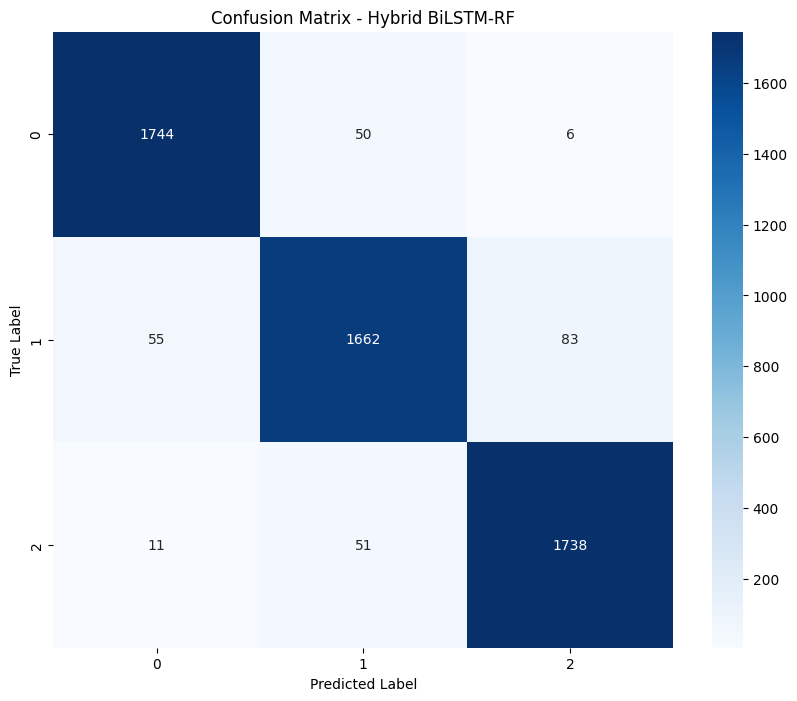


DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.96      0.97      0.97      1800
           1       0.94      0.92      0.93      1800
           2       0.95      0.97      0.96      1800

    accuracy                           0.95      5400
   macro avg       0.95      0.95      0.95      5400
weighted avg       0.95      0.95      0.95      5400


ERROR ANALYSIS DATAFRAME (First 10 errors)
Total misclassified instances: 256/5400 (4.74%)

First 10 misclassified examples:
     True_Label  Predicted_Label  Correct  True_Class_Probability  \
1             1                2    False                    0.46   
67            1                2    False                    0.20   
74            0                2    False                    0.01   
89            2                1    False                    0.10   
105           0                1    False                    0.00   
130           1                0    False      

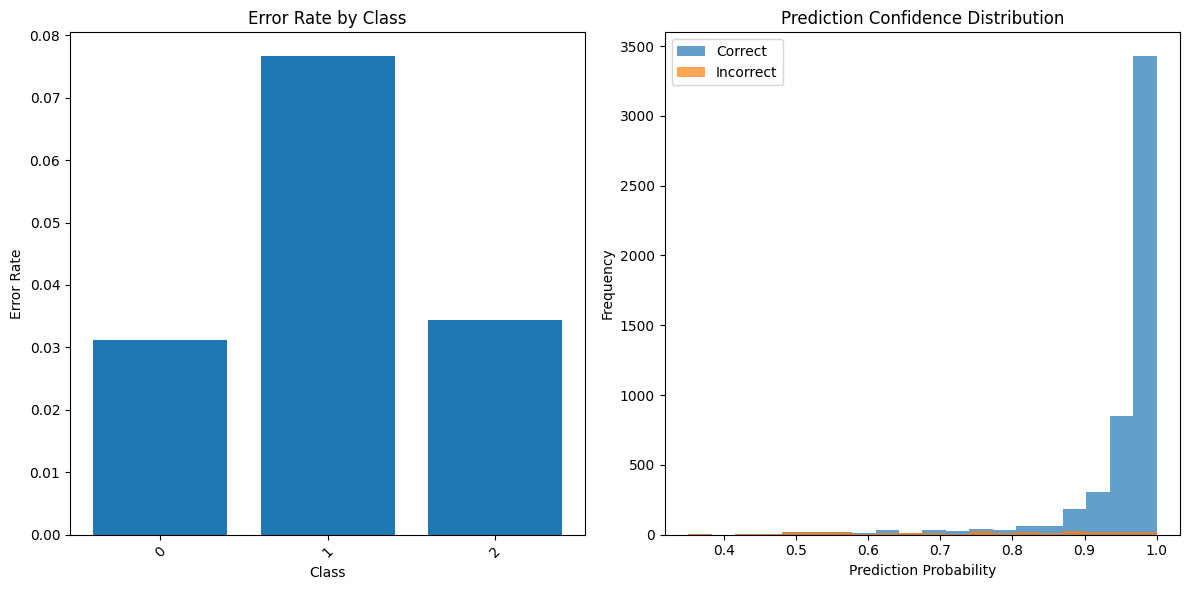


FEATURE IMPORTANCE ANALYSIS (Random Forest)
Average feature importance by feature group:
Numerical: 0.0003
BERT: 0.0002
TF-IDF: 0.0002
N-grams: 0.0000


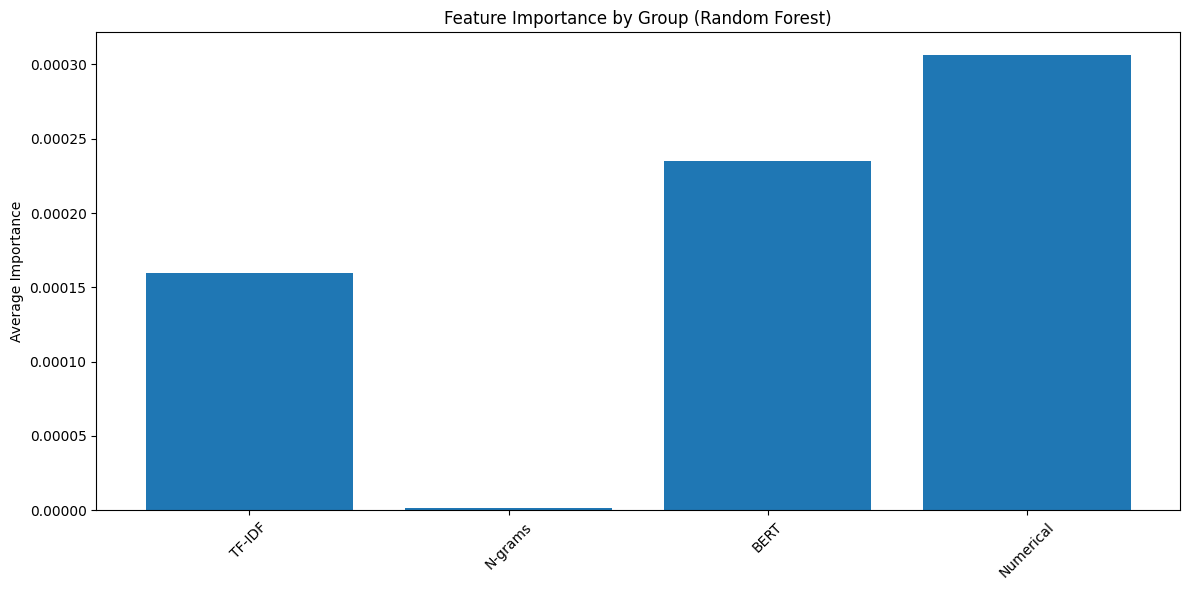

In [ ]:
# ERROR ANALYSIS (same as your Bi-LSTM and RF pipelines)
print("\n" + "="*50)
print("ERROR ANALYSIS")
print("="*50)

# Confusion Matrix
cm = confusion_matrix(y_test_encoded, y_test_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - Hybrid BiLSTM-RF')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Classification Report
print("\nDETAILED CLASSIFICATION REPORT")
print(classification_report(y_test_encoded, y_test_pred, target_names=[str(cls) for cls in label_encoder.classes_]))

# Error Analysis DataFrame
error_analysis = pd.DataFrame({
    'True_Label': y_test_encoded,
    'Predicted_Label': y_test_pred,
    'Correct': y_test_encoded == y_test_pred
})

# Add probabilities for the true and predicted classes
y_test_proba = rf_model.predict_proba(X_test_hybrid)
error_analysis['True_Class_Probability'] = [y_test_proba[i, true_label] for i, true_label in enumerate(y_test_encoded)]
error_analysis['Predicted_Class_Probability'] = [y_test_proba[i, pred_label] for i, pred_label in enumerate(y_test_pred)]

print("\nERROR ANALYSIS DATAFRAME (First 10 errors)")
misclassified = error_analysis[~error_analysis['Correct']]
print(f"Total misclassified instances: {len(misclassified)}/{len(y_test)} ({len(misclassified)/len(y_test)*100:.2f}%)")
print("\nFirst 10 misclassified examples:")
print(misclassified.head(10))

# Most common error patterns
print("\nMOST COMMON ERROR PATTERNS")
error_patterns = misclassified.groupby(['True_Label', 'Predicted_Label']).size().reset_index(name='Count')
error_patterns = error_patterns.sort_values('Count', ascending=False)
print(error_patterns.head(10))

# Class-wise performance analysis
print("\nCLASS-WISE PERFORMANCE ANALYSIS")
class_performance = pd.DataFrame({
    'Class': label_encoder.classes_,
    'Total_Instances': [np.sum(y_test_encoded == cls) for cls in range(num_classes)],
    'Correct_Predictions': [np.sum((y_test_encoded == cls) & (y_test_pred == cls)) for cls in range(num_classes)],
    'Error_Rate': [np.sum((y_test_encoded == cls) & (y_test_pred != cls)) / np.sum(y_test_encoded == cls)
                   if np.sum(y_test_encoded == cls) > 0 else 0 for cls in range(num_classes)]
})

class_performance['Accuracy'] = class_performance['Correct_Predictions'] / class_performance['Total_Instances']
print(class_performance)

# Probability distribution analysis for errors
print("\nPROBABILITY ANALYSIS FOR ERRORS")
print("Probability statistics for correct predictions:")
print(error_analysis[error_analysis['Correct']]['Predicted_Class_Probability'].describe())

print("\nProbability statistics for incorrect predictions:")
print(error_analysis[~error_analysis['Correct']]['Predicted_Class_Probability'].describe())

# Visualize error patterns
plt.figure(figsize=(12, 6))

# Subplot 1: Error rate by class
plt.subplot(1, 2, 1)
plt.bar(range(len(class_performance)), class_performance['Error_Rate'])
plt.xticks(range(len(class_performance)), class_performance['Class'], rotation=45)
plt.title('Error Rate by Class')
plt.xlabel('Class')
plt.ylabel('Error Rate')

# Subplot 2: Confidence in predictions
plt.subplot(1, 2, 2)
plt.hist(error_analysis[error_analysis['Correct']]['Predicted_Class_Probability'],
         alpha=0.7, label='Correct', bins=20)
plt.hist(error_analysis[~error_analysis['Correct']]['Predicted_Class_Probability'],
         alpha=0.7, label='Incorrect', bins=20)
plt.title('Prediction Confidence Distribution')
plt.xlabel('Prediction Probability')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.show()

# FEATURE IMPORTANCE ANALYSIS (Specific to Random Forest)
print("\n" + "="*50)
print("FEATURE IMPORTANCE ANALYSIS (Random Forest)")
print("="*50)

# Get feature importances from the trained model
feature_importances = rf_model.feature_importances_

# Get average feature importance for each feature group
feature_importance_by_group = {}
for group_name, indices in feature_groups.items():
    if len(indices) > 0:
        group_importance = np.mean(feature_importances[indices])
        feature_importance_by_group[group_name] = group_importance

print("Average feature importance by feature group:")
for group, importance in sorted(feature_importance_by_group.items(), key=lambda x: x[1], reverse=True):
    print(f"{group}: {importance:.4f}")

# Plot feature importances
plt.figure(figsize=(12, 6))
plt.bar(range(len(feature_importance_by_group)), list(feature_importance_by_group.values()))
plt.xticks(range(len(feature_importance_by_group)), list(feature_importance_by_group.keys()), rotation=45)
plt.title('Feature Importance by Group (Random Forest)')
plt.ylabel('Average Importance')
plt.tight_layout()
plt.show()

# Comparison Between Models

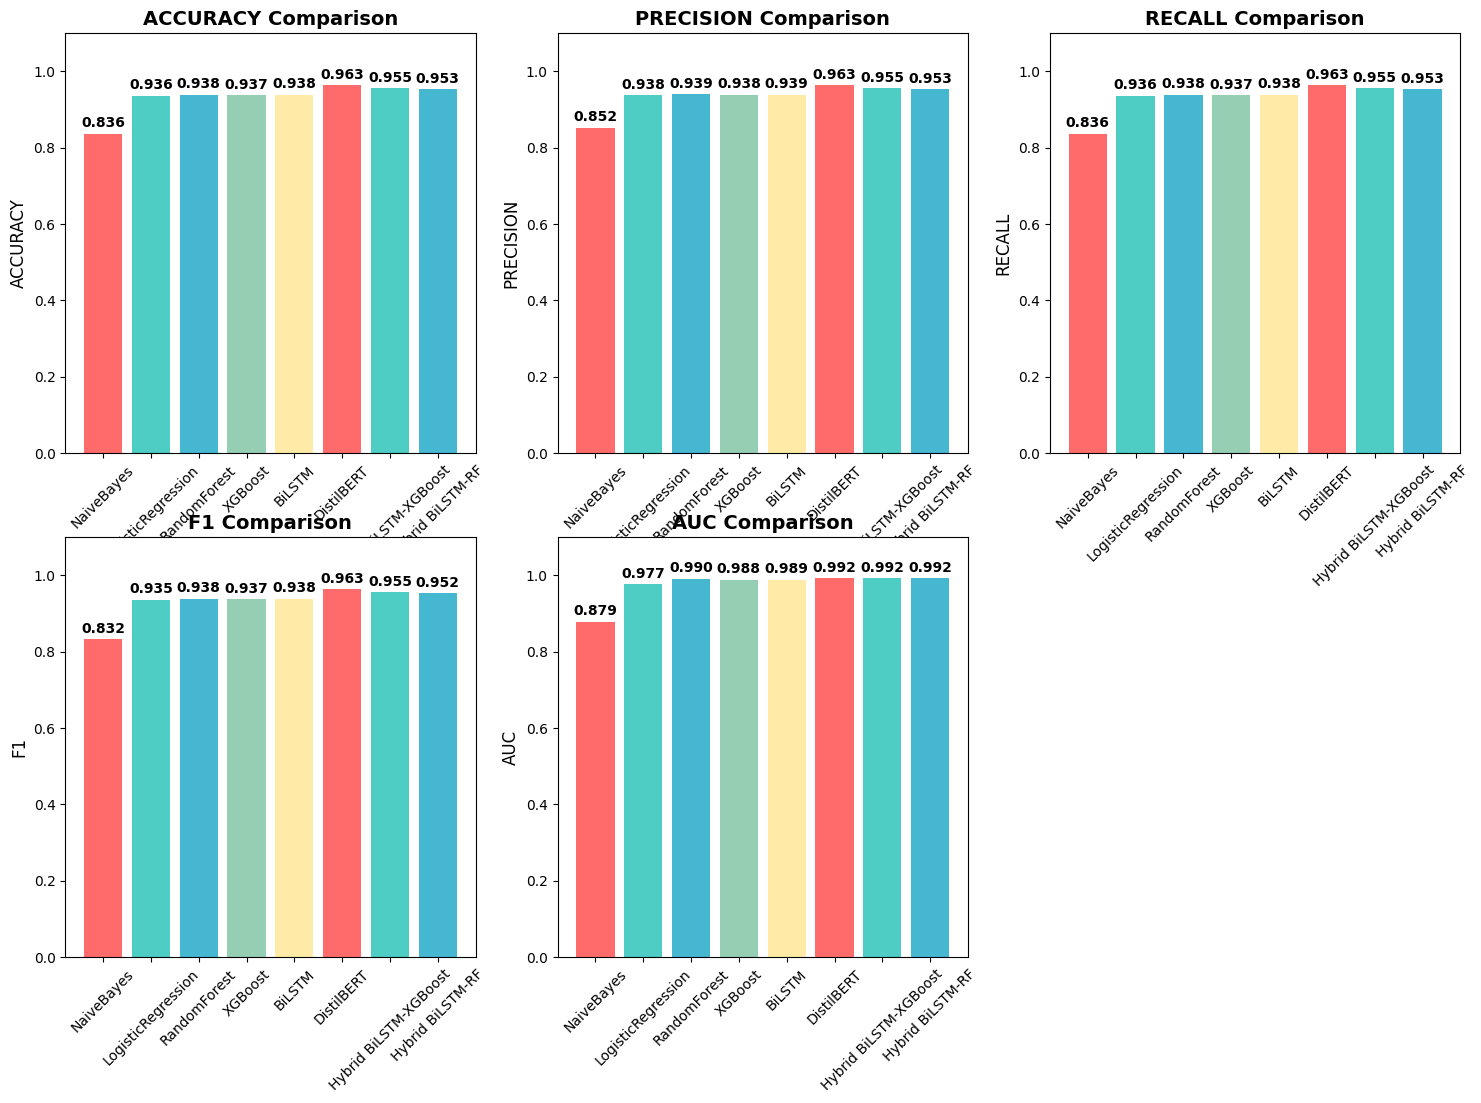

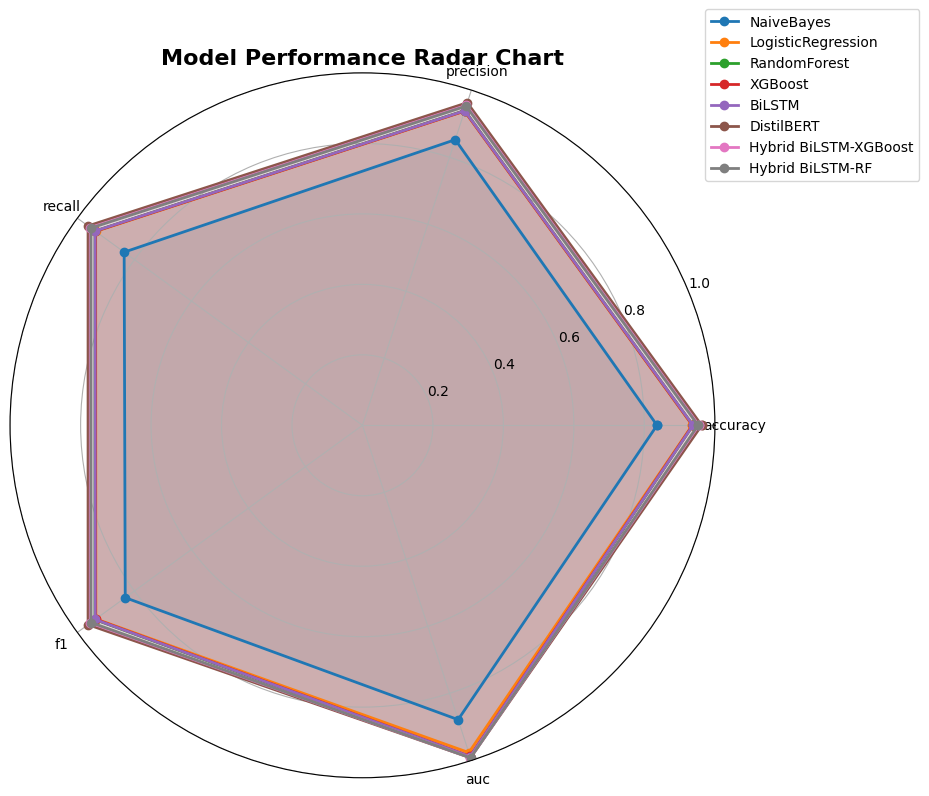


MODEL PERFORMANCE SUMMARY
                Model Accuracy Precision Recall F1-Score    AUC
           NaiveBayes   0.8361    0.8524 0.8361   0.8323 0.8786
   LogisticRegression   0.9361    0.9376 0.9361   0.9353 0.9769
         RandomForest   0.9381    0.9394 0.9381   0.9384 0.9904
              XGBoost   0.9370    0.9379 0.9370   0.9366 0.9878
               BiLSTM   0.9381    0.9388 0.9381   0.9377 0.9888
           DistilBERT   0.9628    0.9628 0.9628   0.9627 0.9924
Hybrid BiLSTM-XGBoost   0.9550    0.9549 0.9550   0.9549 0.9919
     Hybrid BiLSTM-RF   0.9526    0.9525 0.9526   0.9525 0.9924

BEST MODELS BY METRIC
ACCURACY    : DistilBERT (0.9628)
PRECISION   : DistilBERT (0.9628)
RECALL      : DistilBERT (0.9628)
F1          : DistilBERT (0.9627)
AUC         : Hybrid BiLSTM-RF (0.9924)


In [ ]:
def plot_model_comparison(metrics_dict):
    models = list(metrics_dict.keys())
    metrics = ['accuracy', 'precision', 'recall', 'f1', 'auc']

    # Create subplots
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()

    # Plot each metric
    for i, metric in enumerate(metrics):
        values = [metrics_dict[model][metric] for model in models]

        bars = axes[i].bar(models, values, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7'])
        axes[i].set_title(f'{metric.upper()} Comparison', fontsize=14, fontweight='bold')
        axes[i].set_ylabel(metric.upper(), fontsize=12)
        axes[i].tick_params(axis='x', rotation=45)

        # Add value labels on bars
        for bar, value in zip(bars, values):
            height = bar.get_height()
            axes[i].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                        f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

        axes[i].set_ylim(0, 1.1)

    # Radar chart for overall comparison
    axes[5].axis('off')  # Hide the last subplot for radar

    # Create radar chart in a separate figure
    plt.figure(figsize=(10, 8))
    angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
    angles += angles[:1]  # Complete the circle

    for model in models:
        values = [metrics_dict[model][metric] for metric in metrics]
        values += values[:1]  # Complete the circle
        plt.polar(angles, values, 'o-', linewidth=2, label=model)
        plt.fill(angles, values, alpha=0.1)

    plt.thetagrids(np.degrees(angles[:-1]), metrics)
    plt.title('Model Performance Radar Chart', fontsize=16, fontweight='bold')
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()
    plt.show()

    # Create summary table
    summary_data = []
    for model in models:
        summary_data.append([
            model,
            f"{metrics_dict[model]['accuracy']:.4f}",
            f"{metrics_dict[model]['precision']:.4f}",
            f"{metrics_dict[model]['recall']:.4f}",
            f"{metrics_dict[model]['f1']:.4f}",
            f"{metrics_dict[model]['auc']:.4f}"
        ])

    print("\n" + "="*80)
    print("MODEL PERFORMANCE SUMMARY")
    print("="*80)
    summary_df = pd.DataFrame(summary_data,
                             columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC'])
    print(summary_df.to_string(index=False))

    # Print best model for each metric
    print("\n" + "="*80)
    print("BEST MODELS BY METRIC")
    print("="*80)
    for metric in metrics:
        best_model = max(models, key=lambda x: metrics_dict[x][metric])
        best_value = metrics_dict[best_model][metric]
        print(f"{metric.upper():<12}: {best_model} ({best_value:.4f})")

# After training all models, run:
plot_model_comparison(model_metrics)